## Import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
data_exp = pd.read_excel('sheet_full_environment_experiments.xlsx', sheet_name='Sheet1')
data_sumo_rl = pd.read_excel("SUMO-RL-EXP.xlsx")



In [3]:
data_exp.head(-4)

,Area,Reward,Environment Type,Algorithm,Episodes,Max Sumo Steps(s),Traffic Scale,Seed,Runned By,Reward of Last Episode,...,Total Time Of Training (M),Reward on Final Test,Waiting Time (s) on Final Test,Speed (m/s) on Final Test,Depart Delay (s) on Final Test,Time Loss (s) on Final Test,Waiting Car on Final Test,Device,Notes,Study Group
0,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,D3QN,350,3000,Normal (.14),0,NaN,4.500000,...,3.257,-14.110688,1463.89,4.97,28.63,1856.25,26,colab,NaN,NaN
1,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,D3QN,350,3000,Normal (.14),1,NaN,4.500000,...,3.338,-25.021125,928.61,6.93,63.33,1080.99,20,colab,NaN,NaN
2,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,D3QN,350,3000,Normal (.14),2,NaN,4.213000,...,2.507,21.013125,133.25,7.82,15.63,583.49,27,colab,NaN,NaN
3,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,D3QN,350,3000,Normal (.14),3,NaN,11.100000,...,3.189,35.562750,760.69,4.89,16.00,1461.44,1,colab,NaN,NaN
4,Area2 (Mosheer Ismail),Literature,GroupedSumoEnv,D3QN,350,3000,Crowding (.38),0,NaN,5.863000,...,6.742,14.204438,1423.89,5.28,55.73,1582.27,38,colab,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135,Bench(2waySingle),Literature,HighGroupedSumoEnv,dqn,1,3000,Default (0),3,NaN,-923464.312500,...,3.229,0.000000,0.00,0.00,0.00,0.00,0,colab,NaN,NaN
136,Bench(2waySingle),Proposed,GroupedSumoEnv,dqn,1,3000,Default (0),0,NaN,-59090.507812,...,5.435,0.000000,0.00,0.00,0.00,0.00,0,colab,NaN,NaN
137,Bench(2waySingle),Proposed,GroupedSumoEnv,dqn,1,3000,Default (0),1,NaN,-62436.968750,...,5.875,0.000000,0.00,0.00,0.00,0.00,0,colab,NaN,NaN
138,Bench(2waySingle),Proposed,GroupedSumoEnv,dqn,1,3000,Default (0),2,NaN,-63739.707031,...,5.756,0.000000,0.00,0.00,0.00,0.00,0,colab,NaN,NaN


In [4]:
# Run this cell once
data_sumo_rl = data_sumo_rl.drop(['Device', 'Notes', 'Study Group'],axis = 1)
data_exp =  data_exp.drop(['Device', 'Notes', 'Study Group'],axis = 1)

## Helper Functions

In [5]:
def get_grouped_seed(data):
    group_cols = ['Area', 'Reward', 'Algorithm', 'Traffic Scale']

    if 'Environment Type' in data.columns:
        group_cols.append('Environment Type')

    #numeric_cols = data.select_dtypes(include='number').columns

    result = (
        data
        .groupby(group_cols)
        .mean()
        .reset_index()
    )
    return result



In [6]:
#pip install nbformat>=4.2.0
#pip install seaborn

In [7]:
def plot_with_benchmark(
    data_exp, 
    data_bench_groubed, 
    area, 
    column_y, 
    reward='Proposed', 
):

    # Filter benchmark data
    data_bench_groubed = data_bench_groubed[data_bench_groubed['Area'] == area]

    column_x = 'Traffic Scale'

    # Filter experimental data for the selected reward
    data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area] 

    # --- Create FacetGrid ---
    g = sns.FacetGrid(
        data_exp_filtered,
        col="Algorithm",
        row="Environment Type",
       # hue="Reward",
        margin_titles=True,
        height=4,
        aspect=2
    )

    # --- Boxplot per x-axis point ---
    def boxplot_per_x(data, **kwargs):
        ax = plt.gca()
        grouped = data.groupby(column_x)[column_y]

        x_labels = sorted(grouped.groups.keys())
        box_data = [grouped.get_group(x).values for x in x_labels]
        x_positions = range(len(x_labels))

        ax.boxplot(
            box_data,
            positions=x_positions,
            widths=0.25,
            showfliers=False,
            patch_artist=True
        )

        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_labels)
        ax.set_ylabel(column_y)

    g.map_dataframe(boxplot_per_x)

    
    # --- Add benchmark points for the specified reward ---
    for ax, (env, algo) in zip(
        g.axes.flat,
        [(e, a) for e in data_exp_filtered["Environment Type"].unique()
               for a in data_exp_filtered["Algorithm"].unique()]
    ):
        subset_bench = data_bench_groubed[
            (data_bench_groubed['Algorithm'] == algo) &
            (data_bench_groubed['Reward'] == reward)
        ]


        if not subset_bench.empty:
            ax.scatter(
                subset_bench[column_x],
                subset_bench[column_y],
                color='purple',
                marker='$-$',
                s=3500,
                linewidth=1.5,
                label=f"Benchmark {reward}",
                zorder=10
            )

    # --- Formatting ---
    g.add_legend()
    g.figure.suptitle(
        f"Performance Comparison (Using Reward : {reward})\n{column_y} on area {area}",
        fontsize=16,y=1.1
    )
    g.figure.tight_layout(rect=[0, 0, 1, 2.1])
    g.figure.subplots_adjust(top=0.9)
    plt.show()


## Plots 

In [8]:
data_bench_grouped = get_grouped_seed(data_sumo_rl)

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


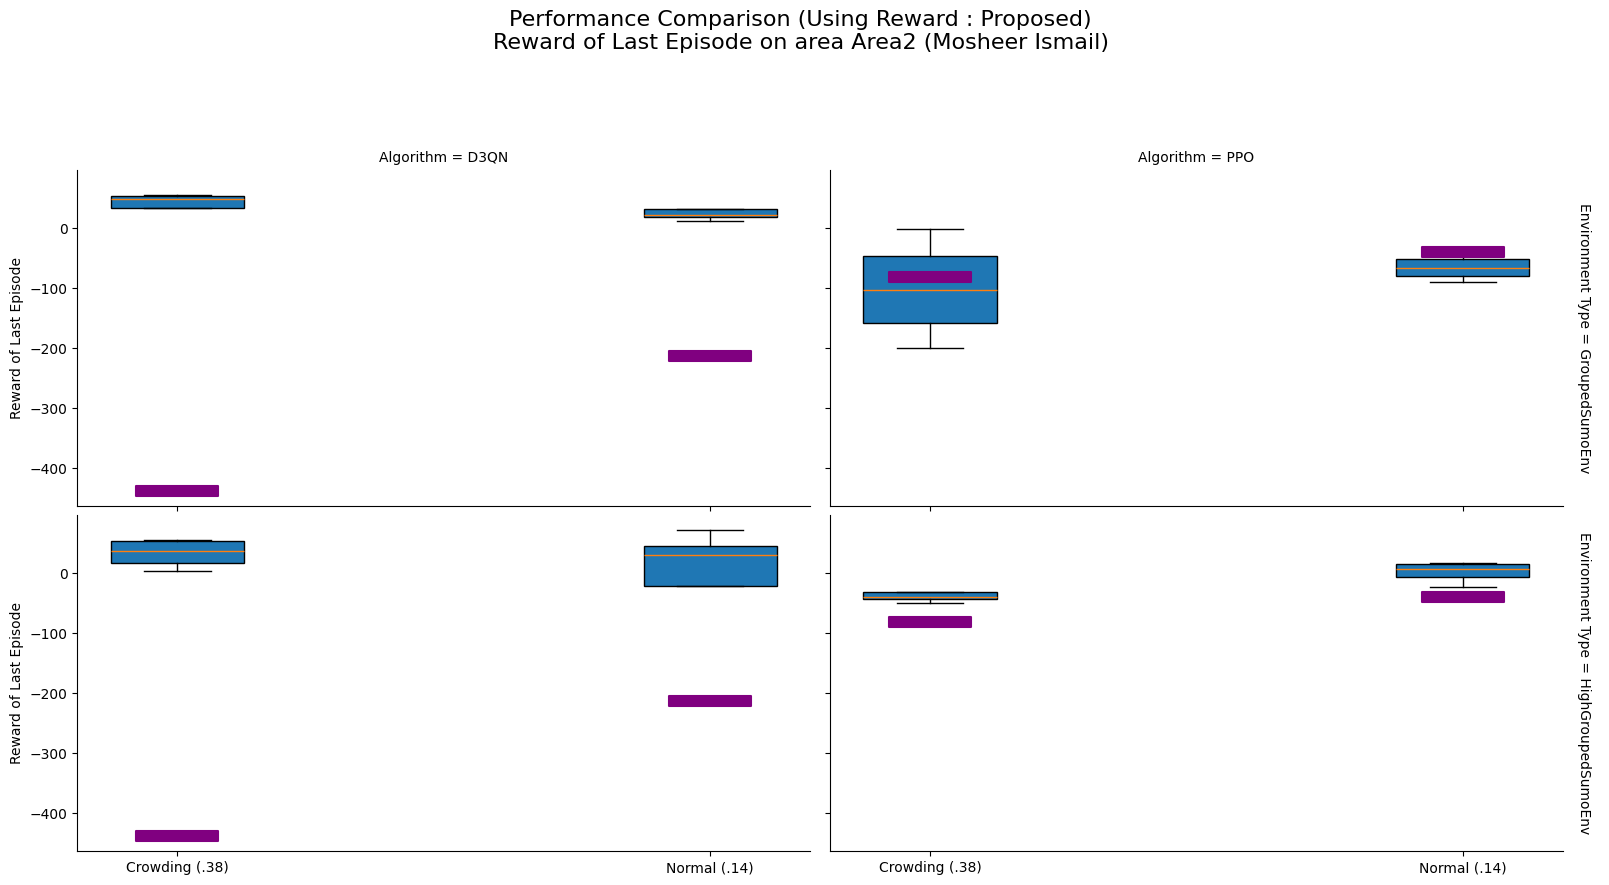

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


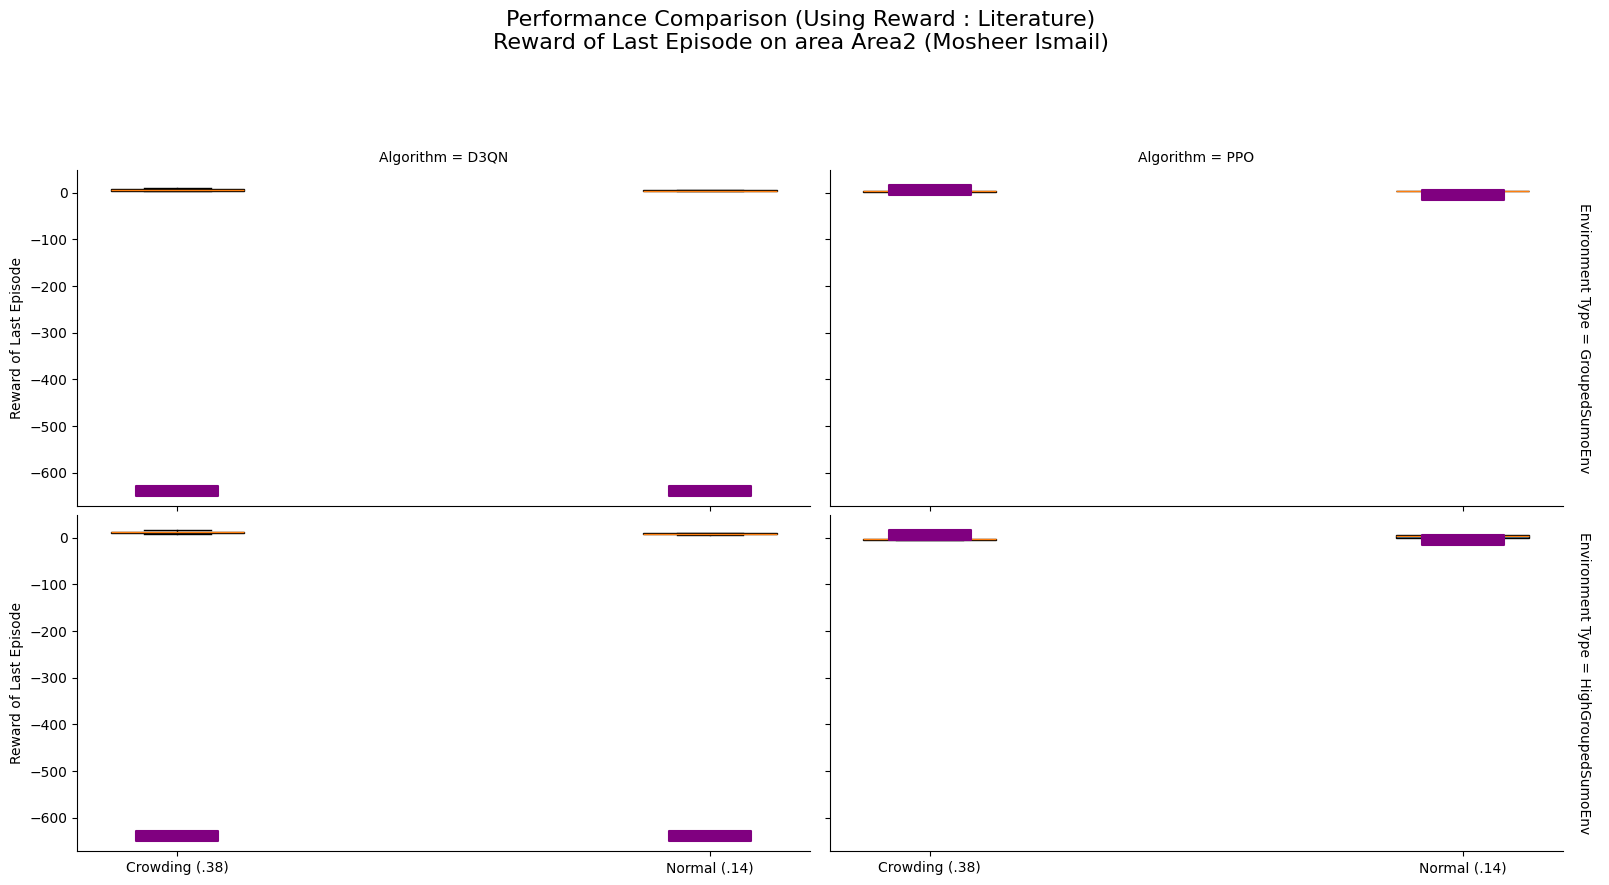

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


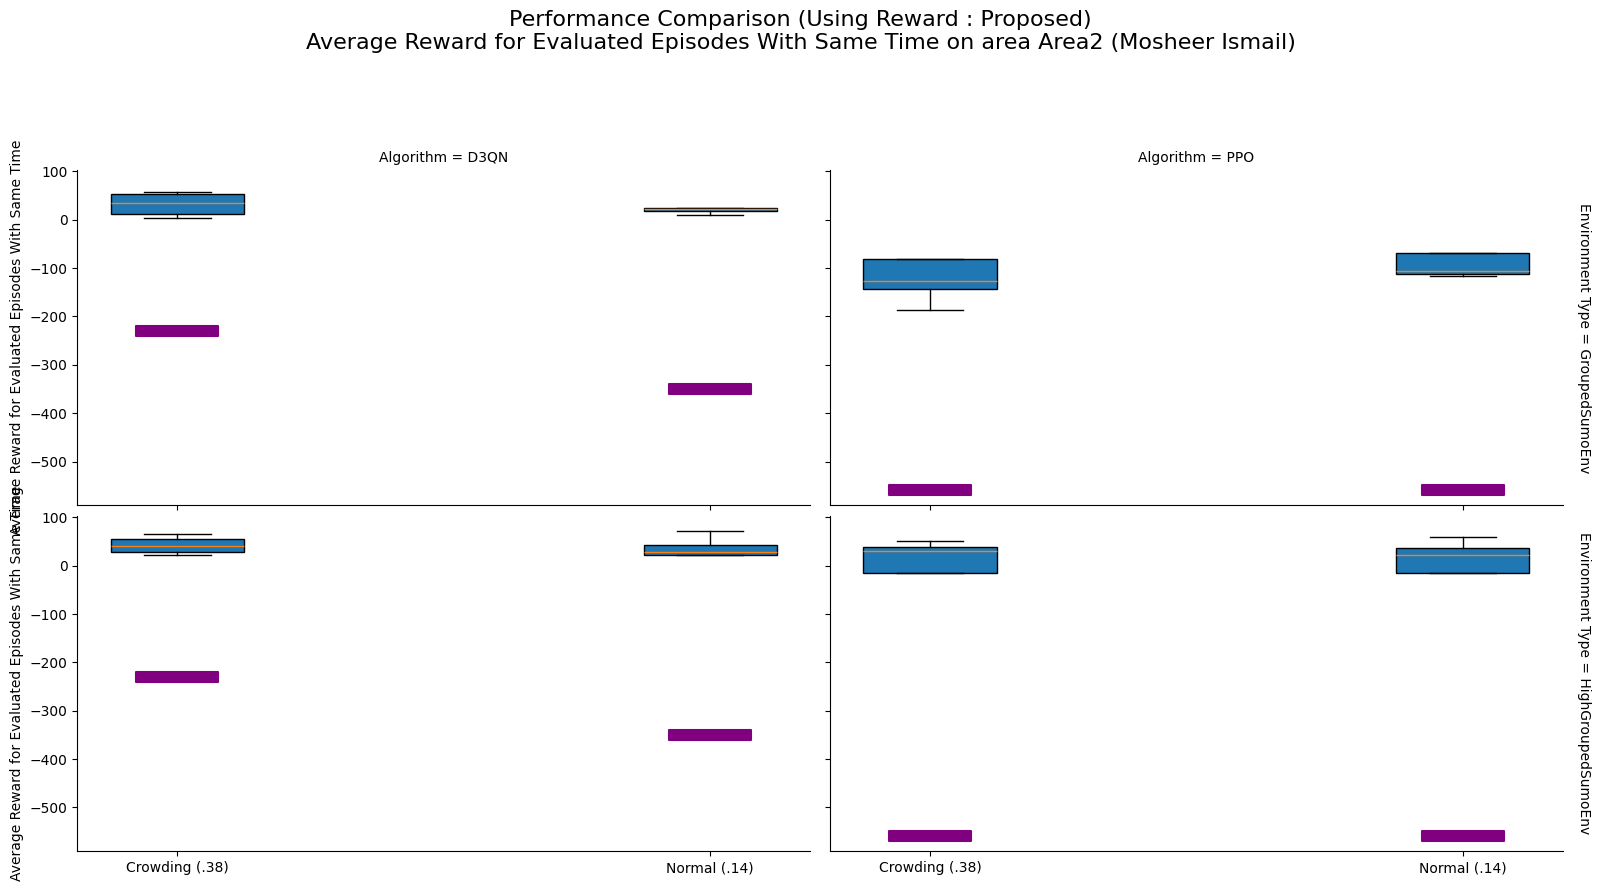

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


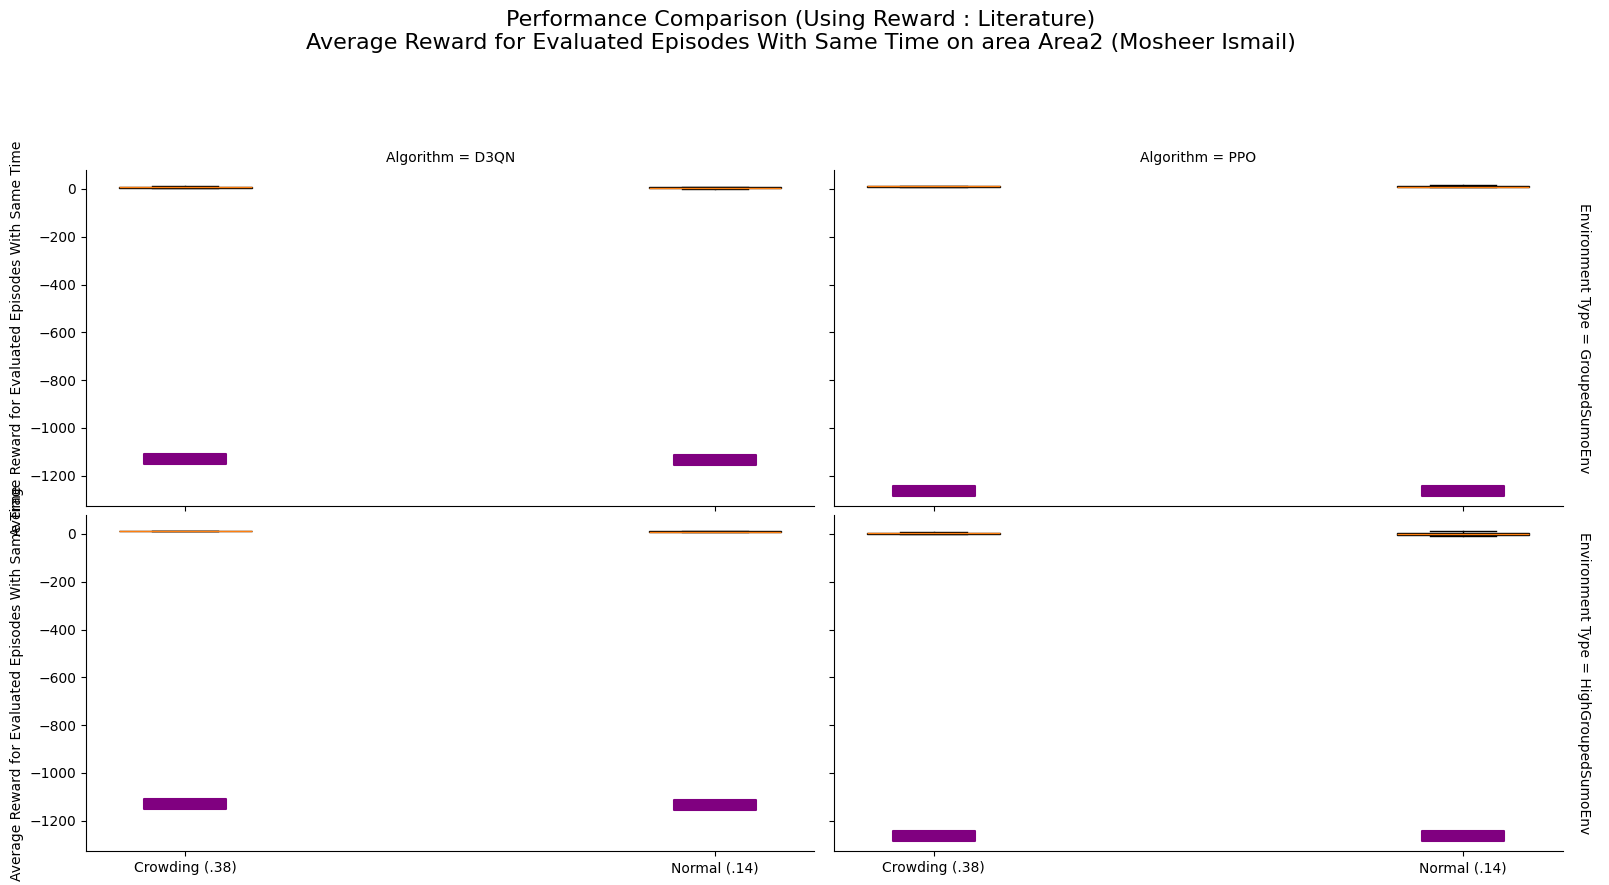

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


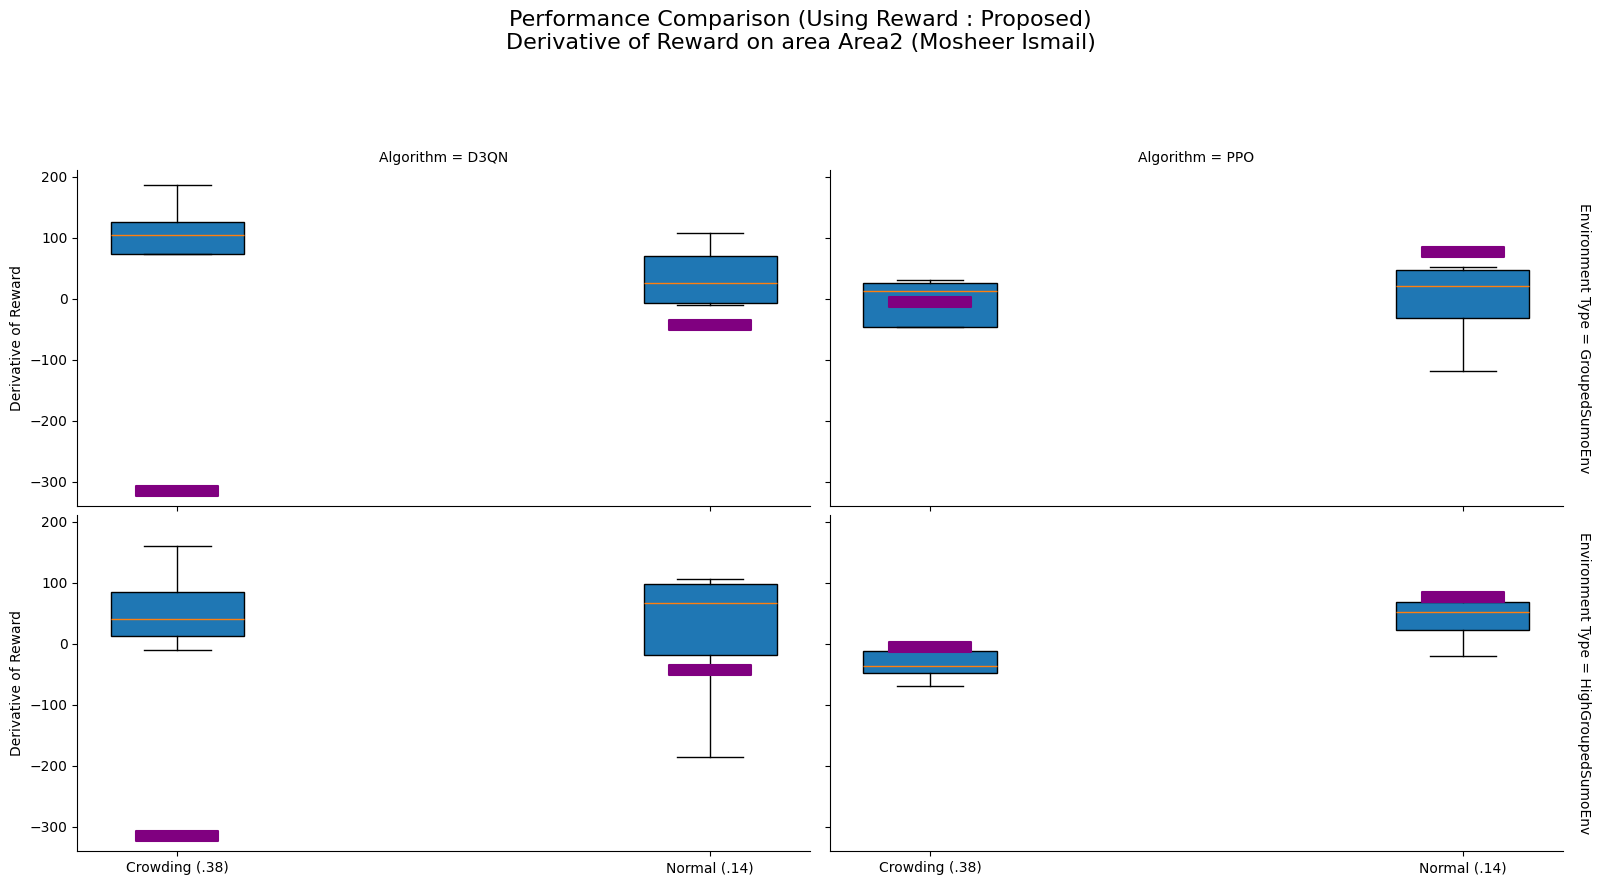

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


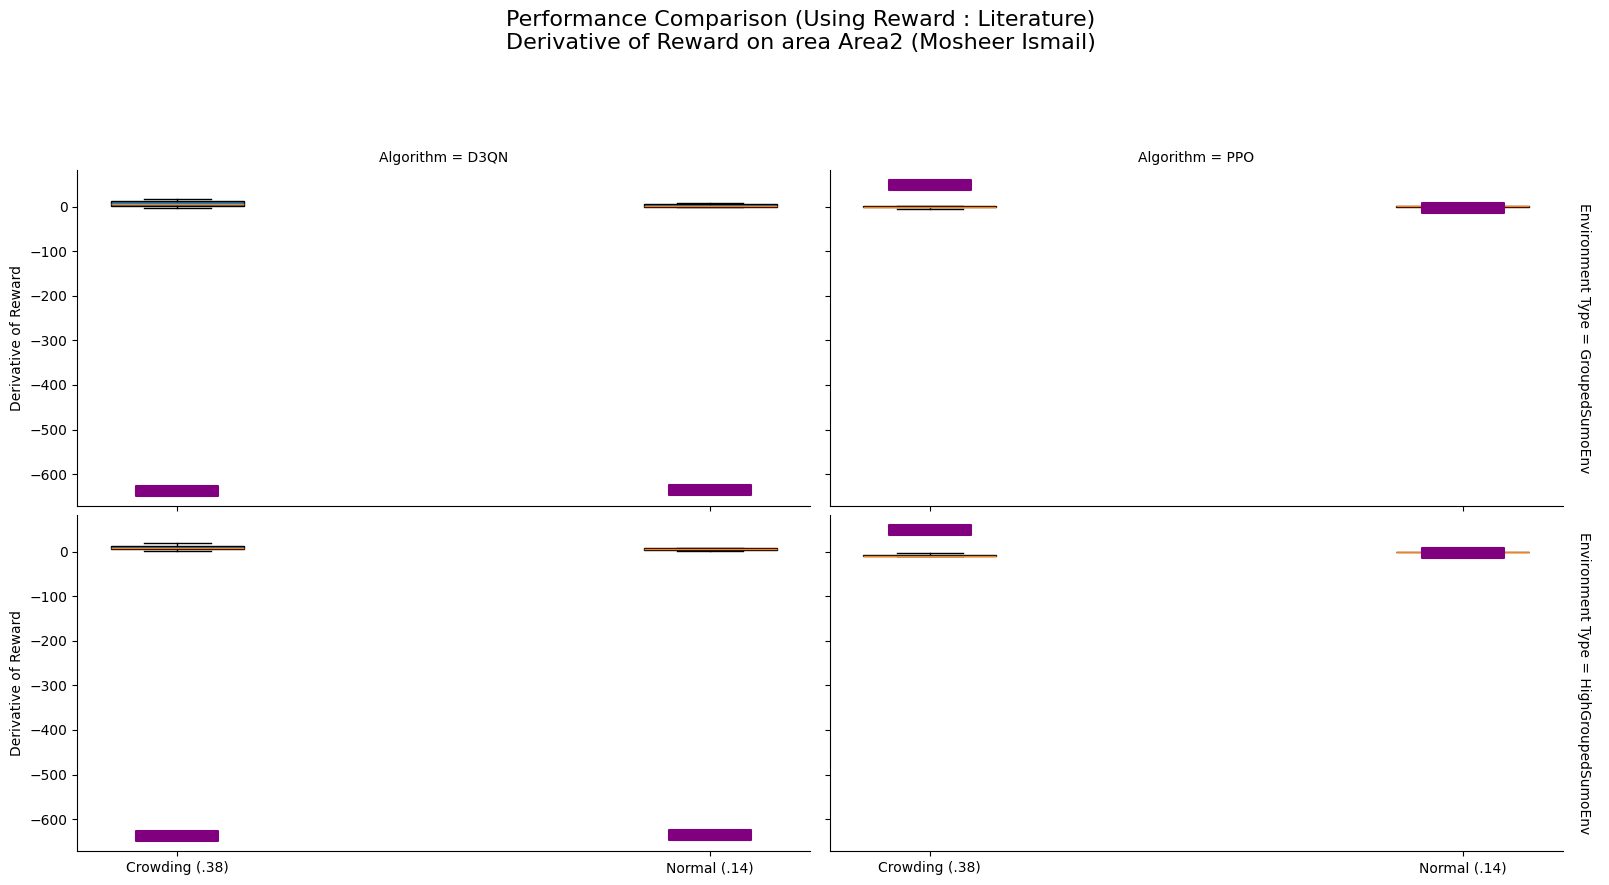

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


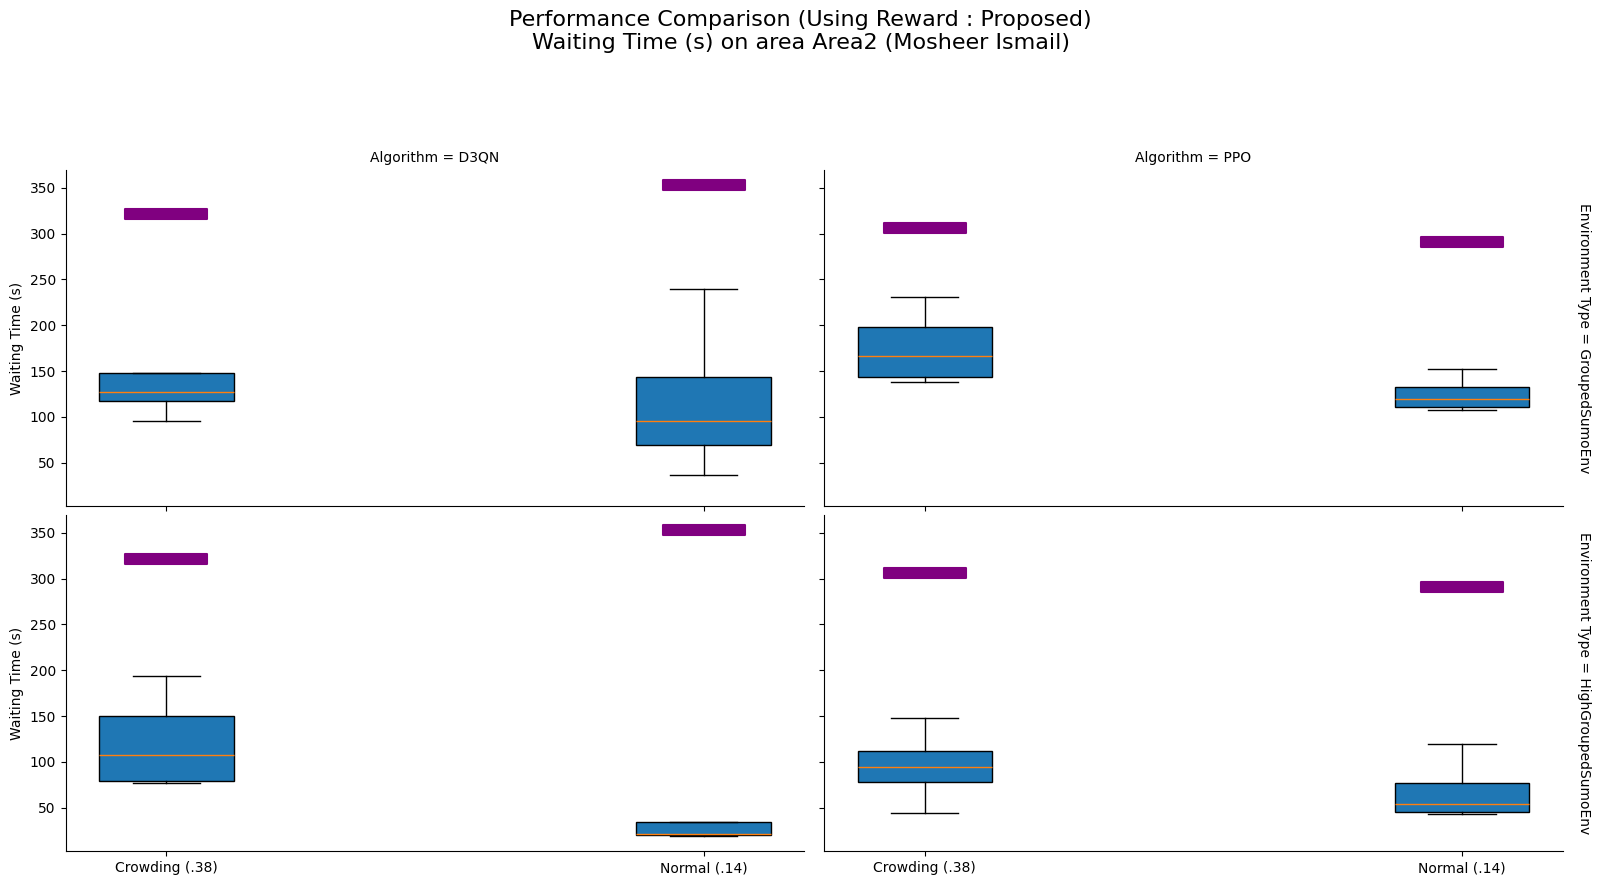

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


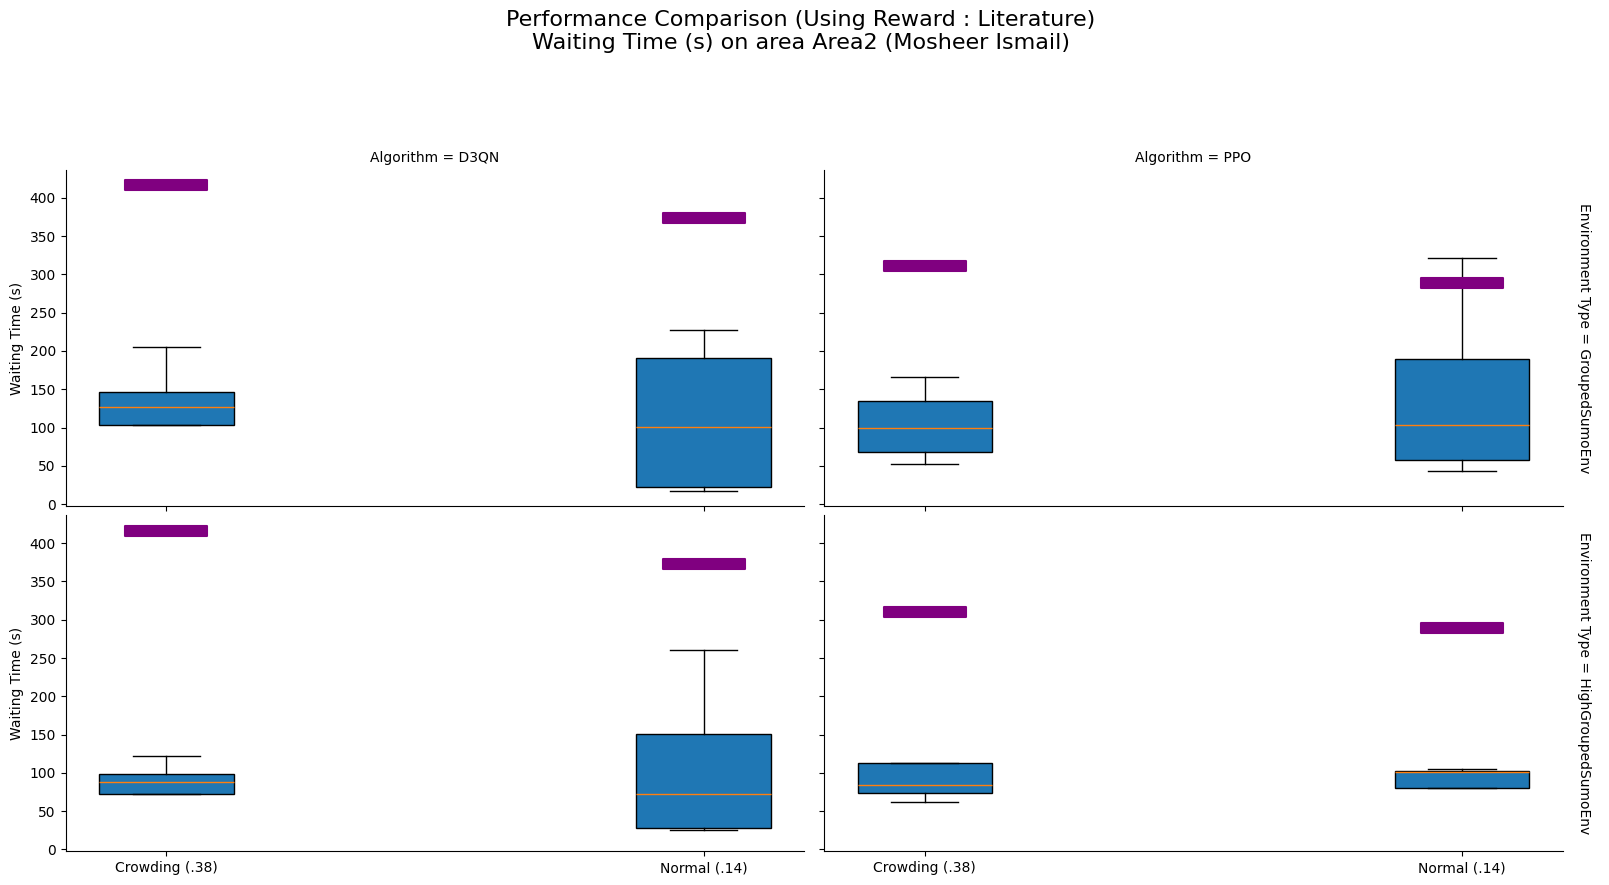

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


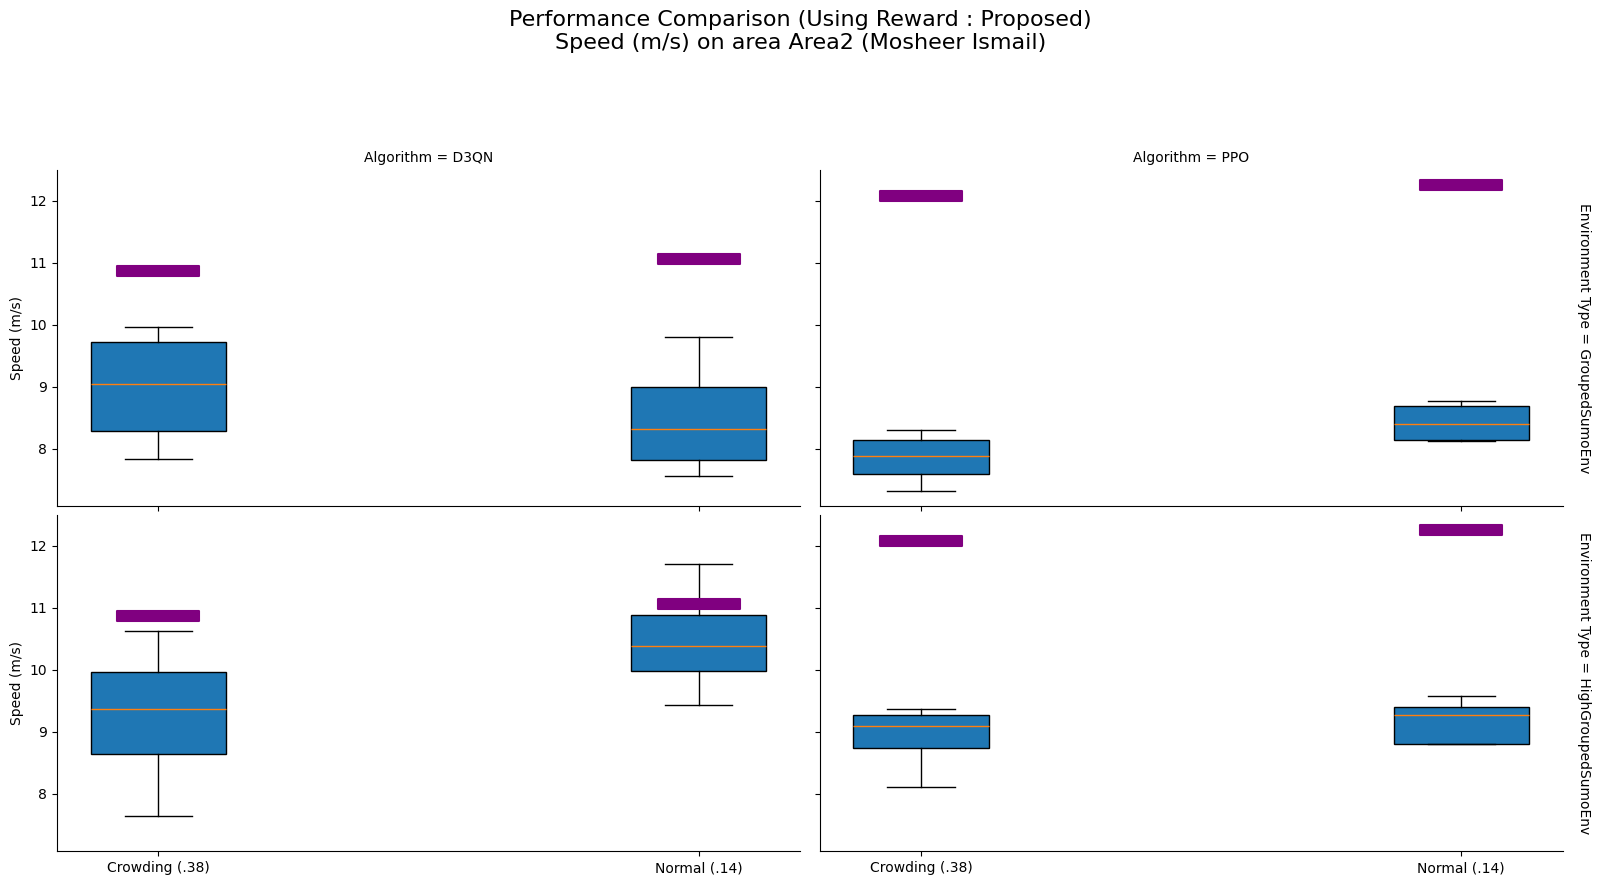

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


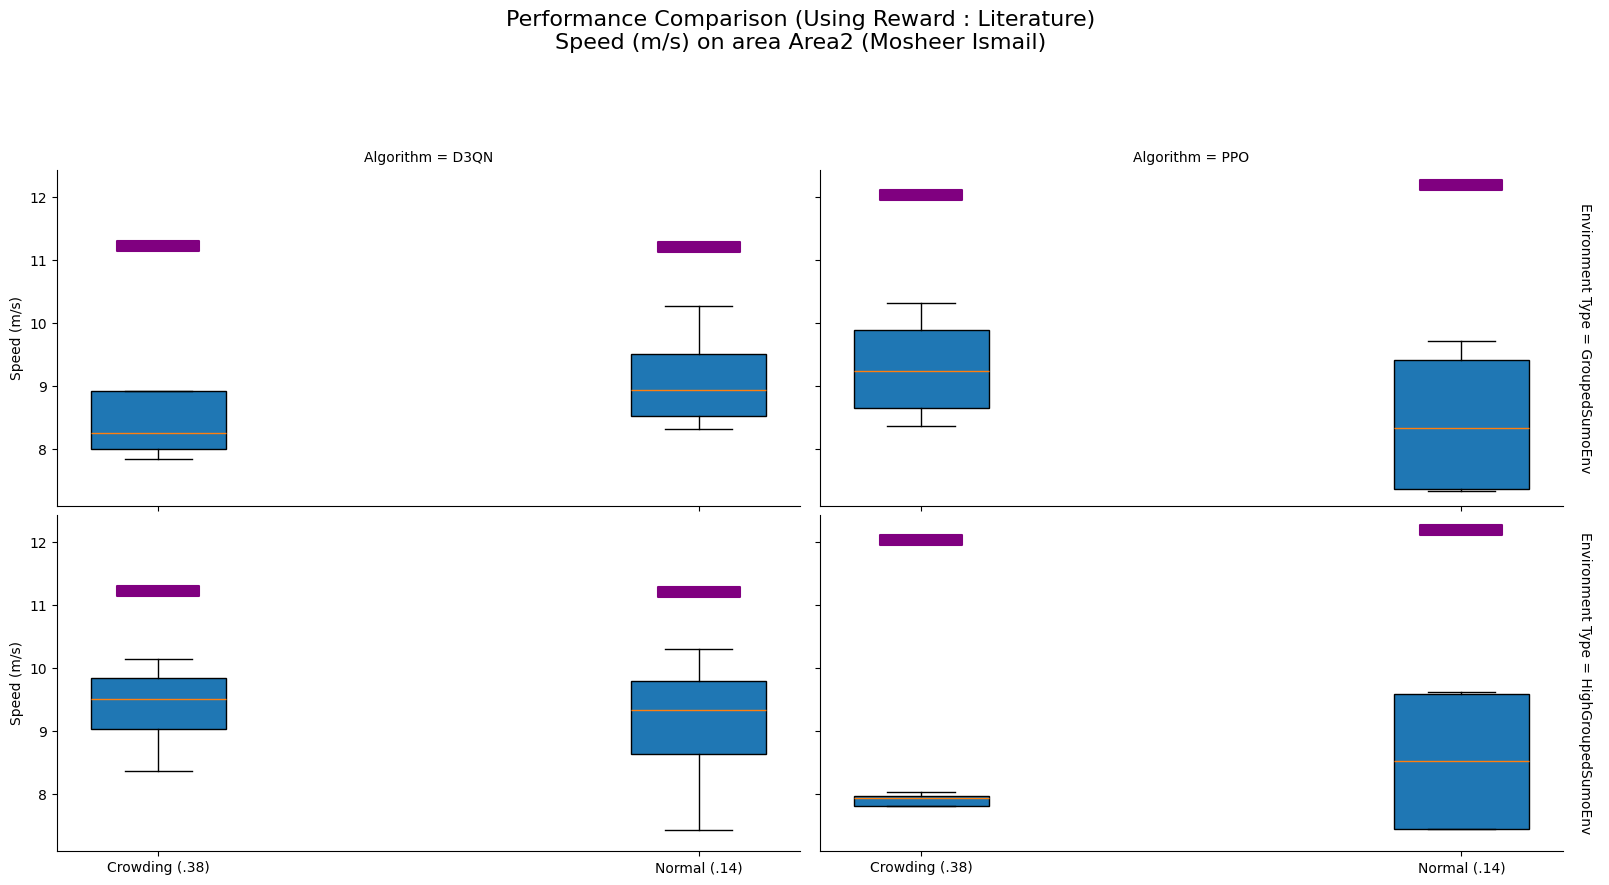

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


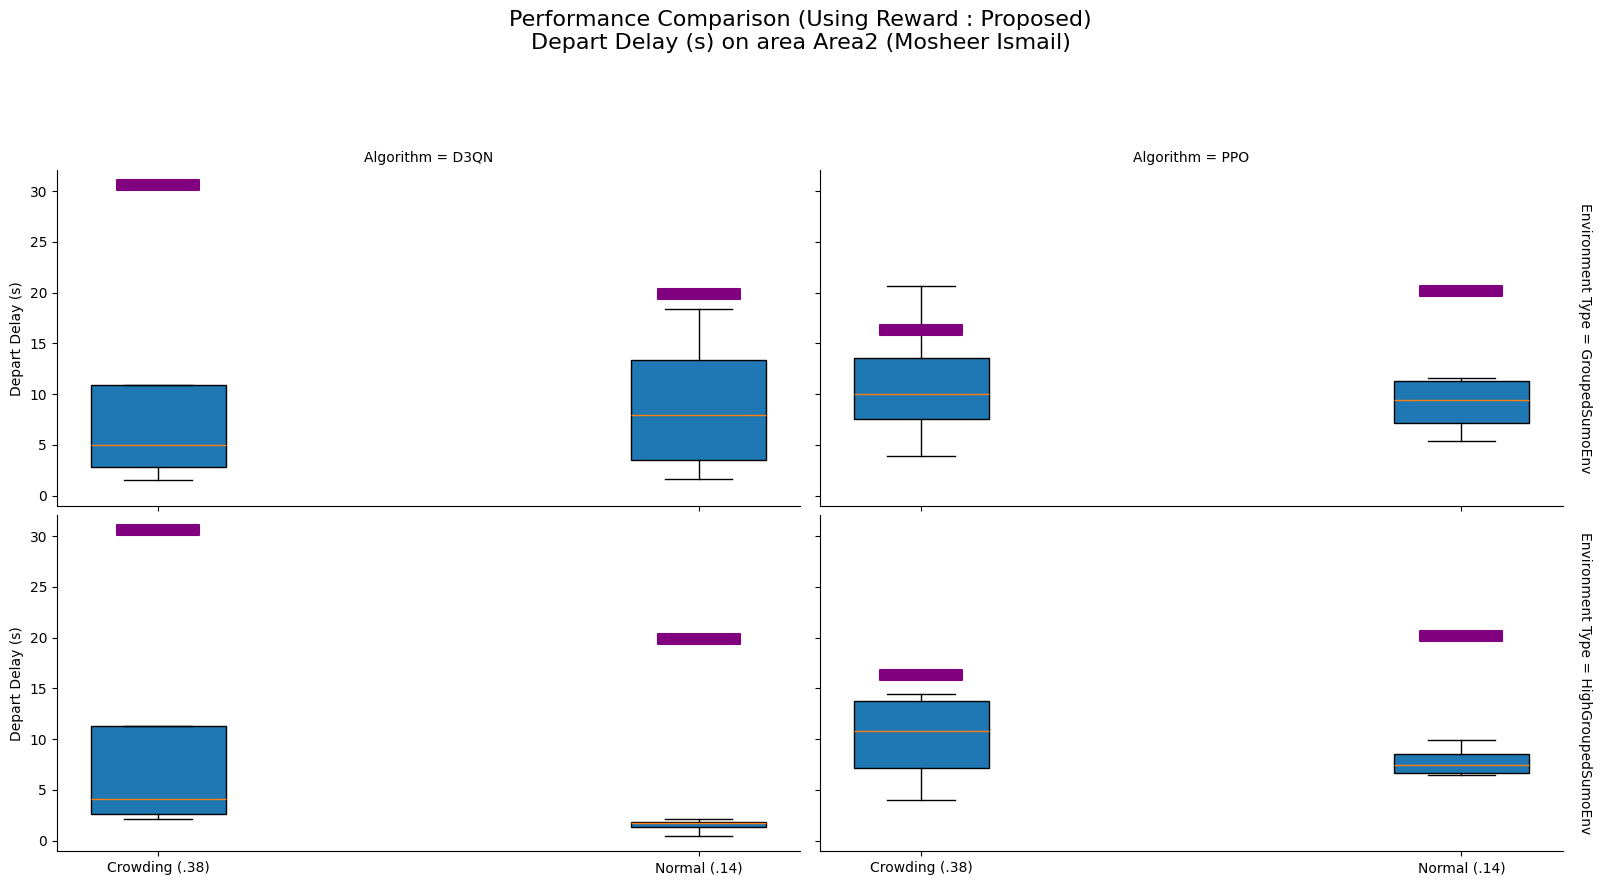

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


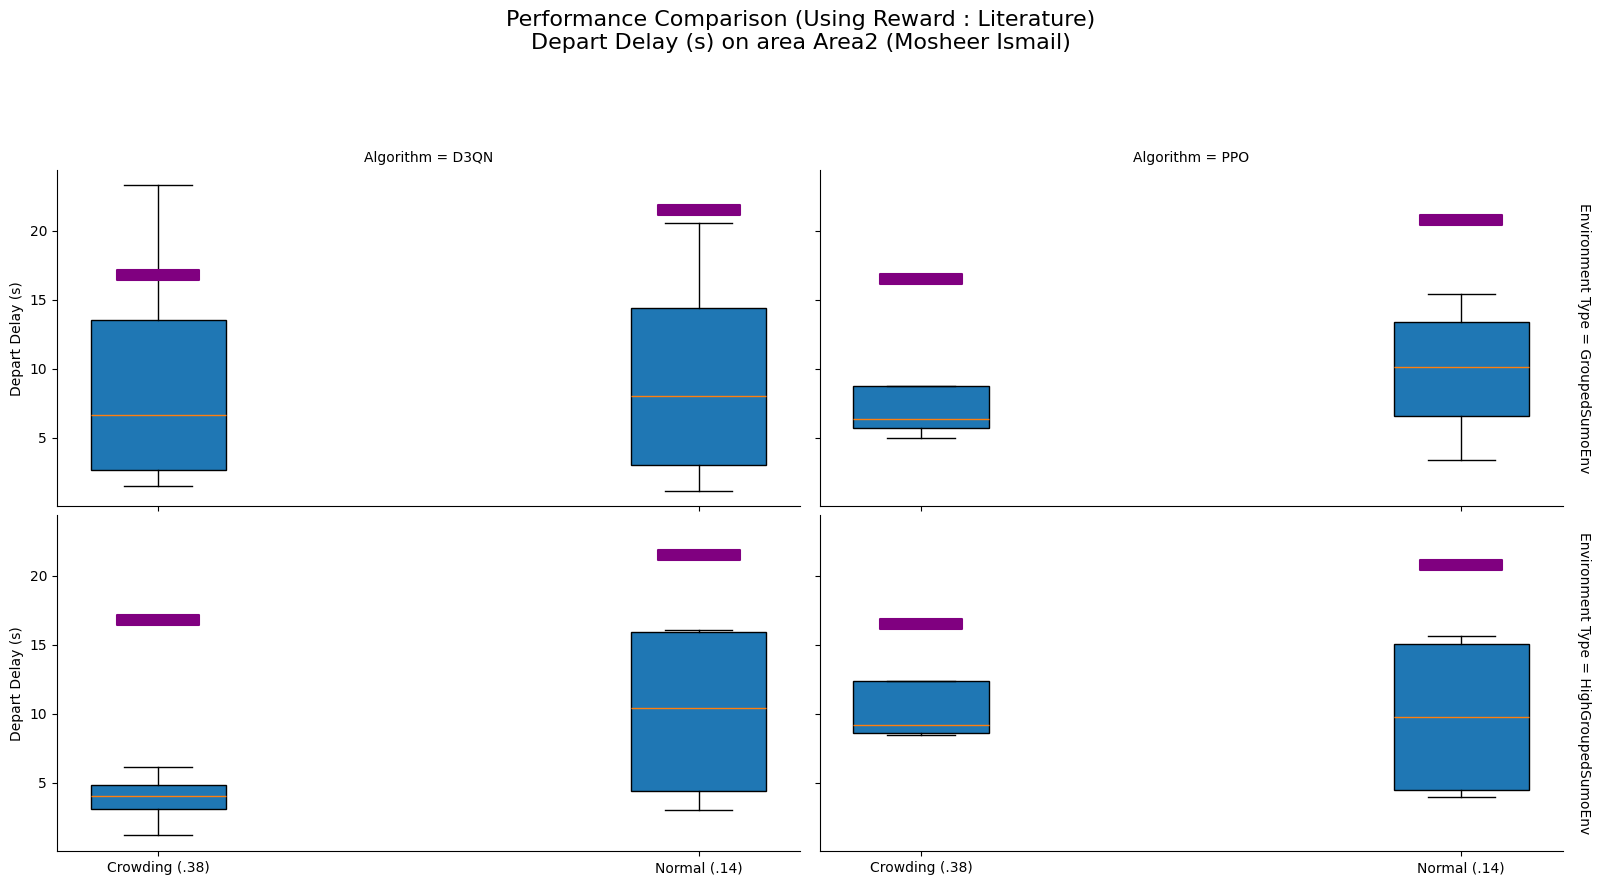

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


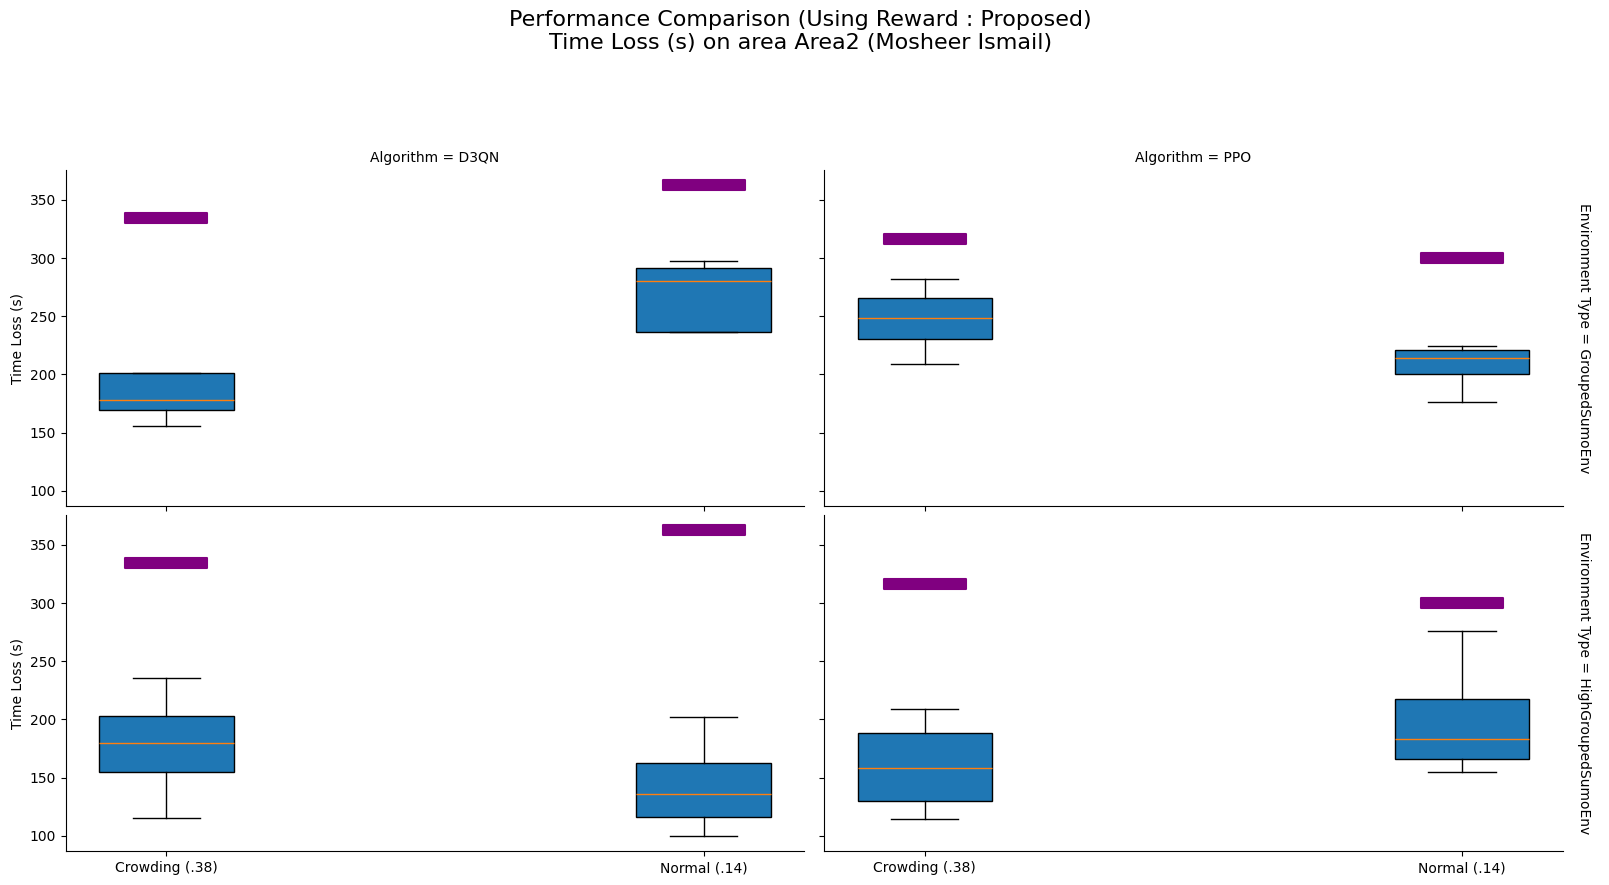

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


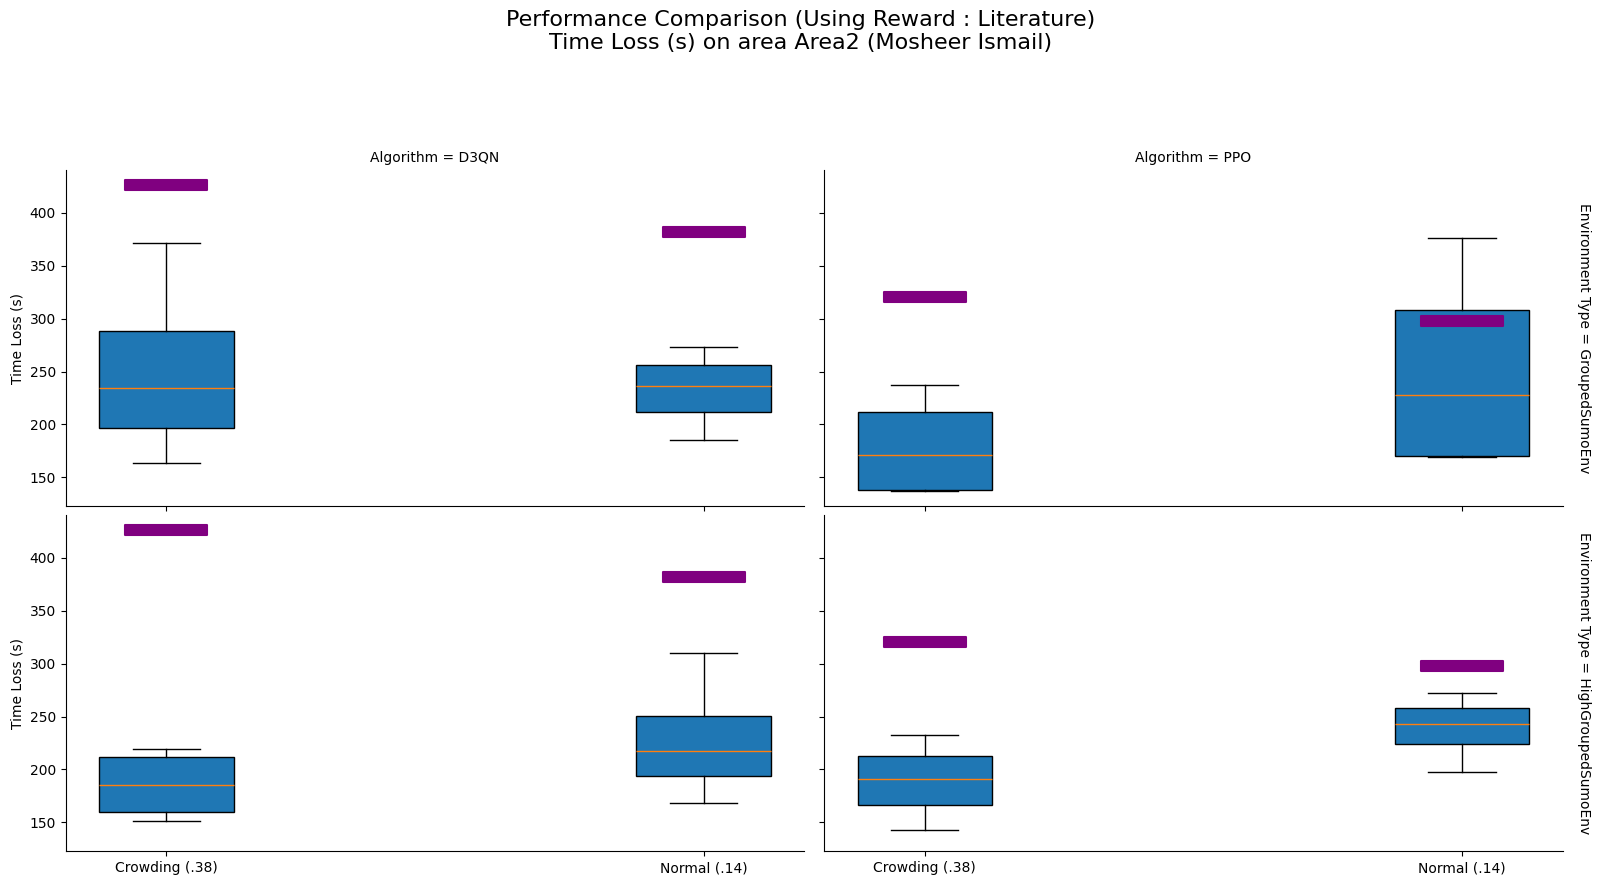

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


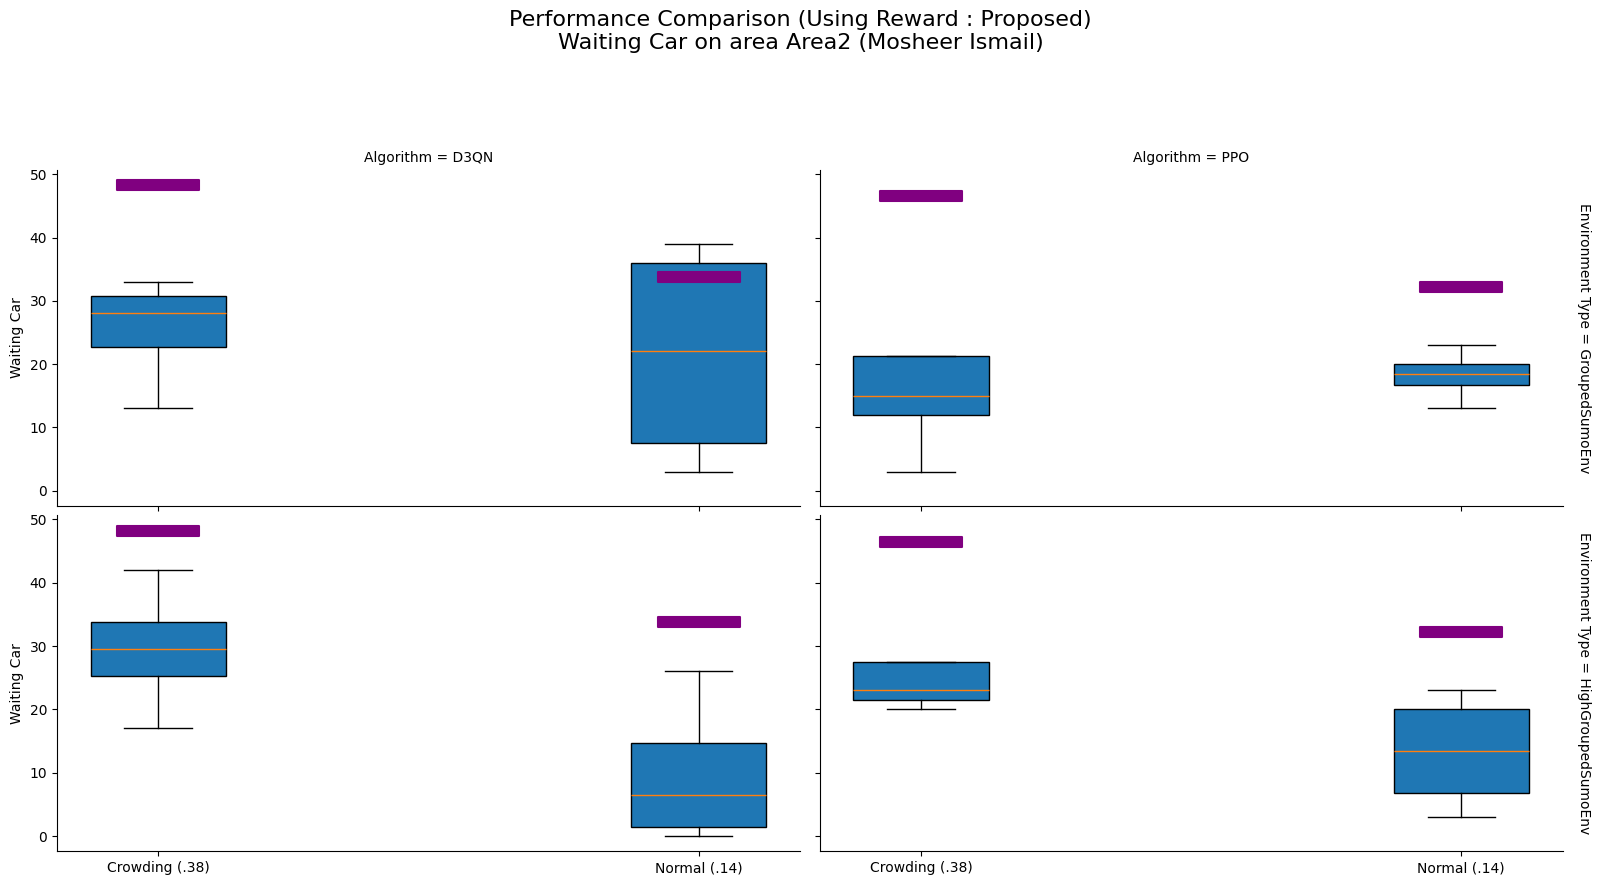

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


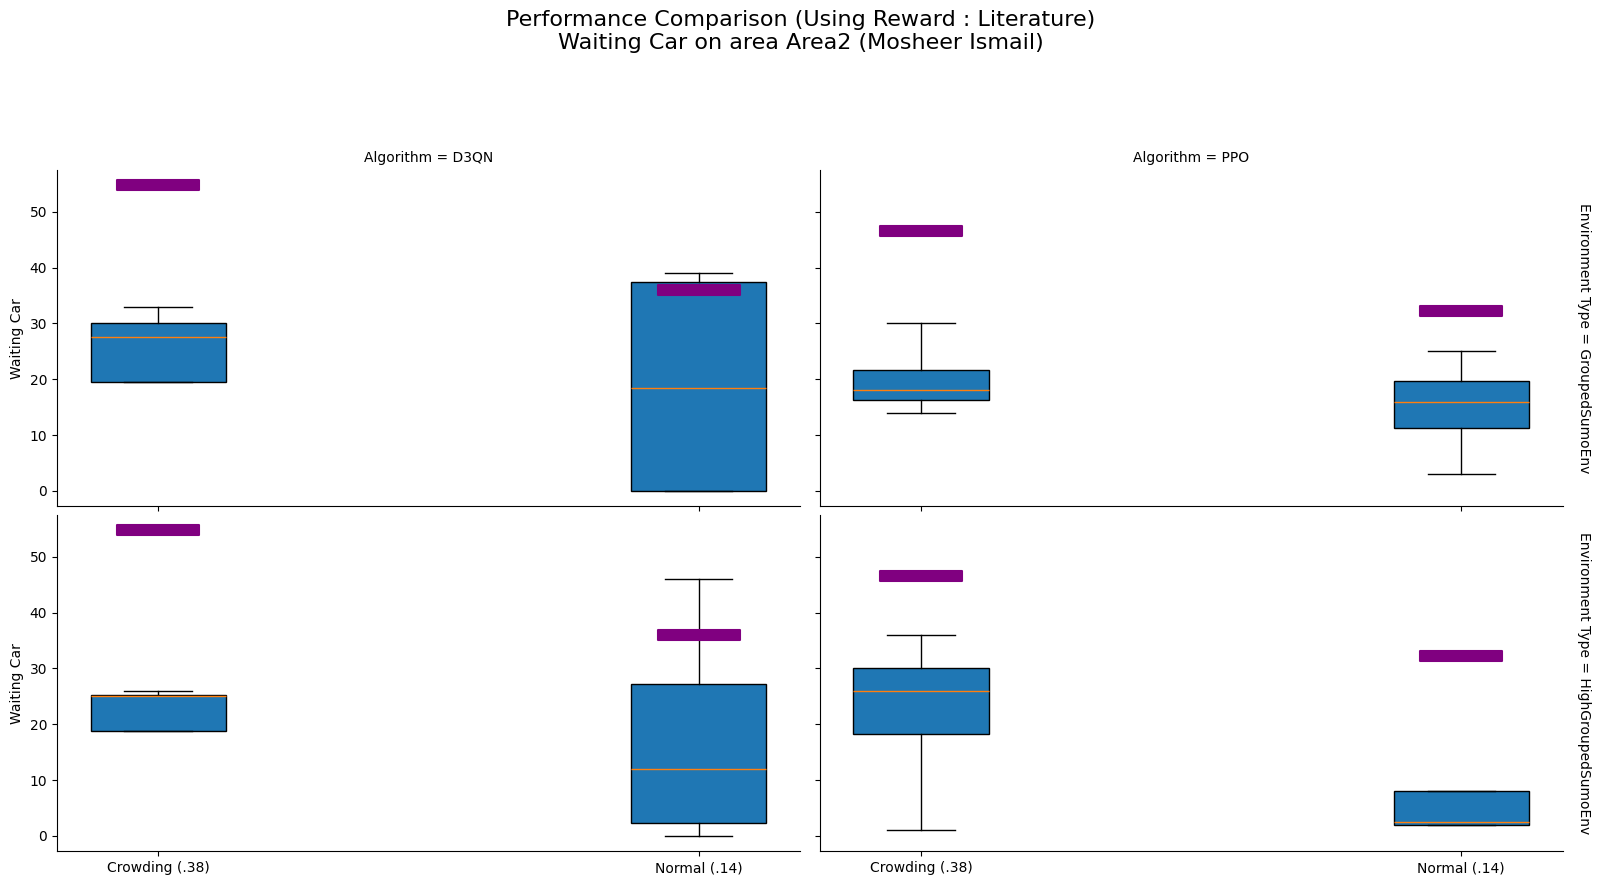

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


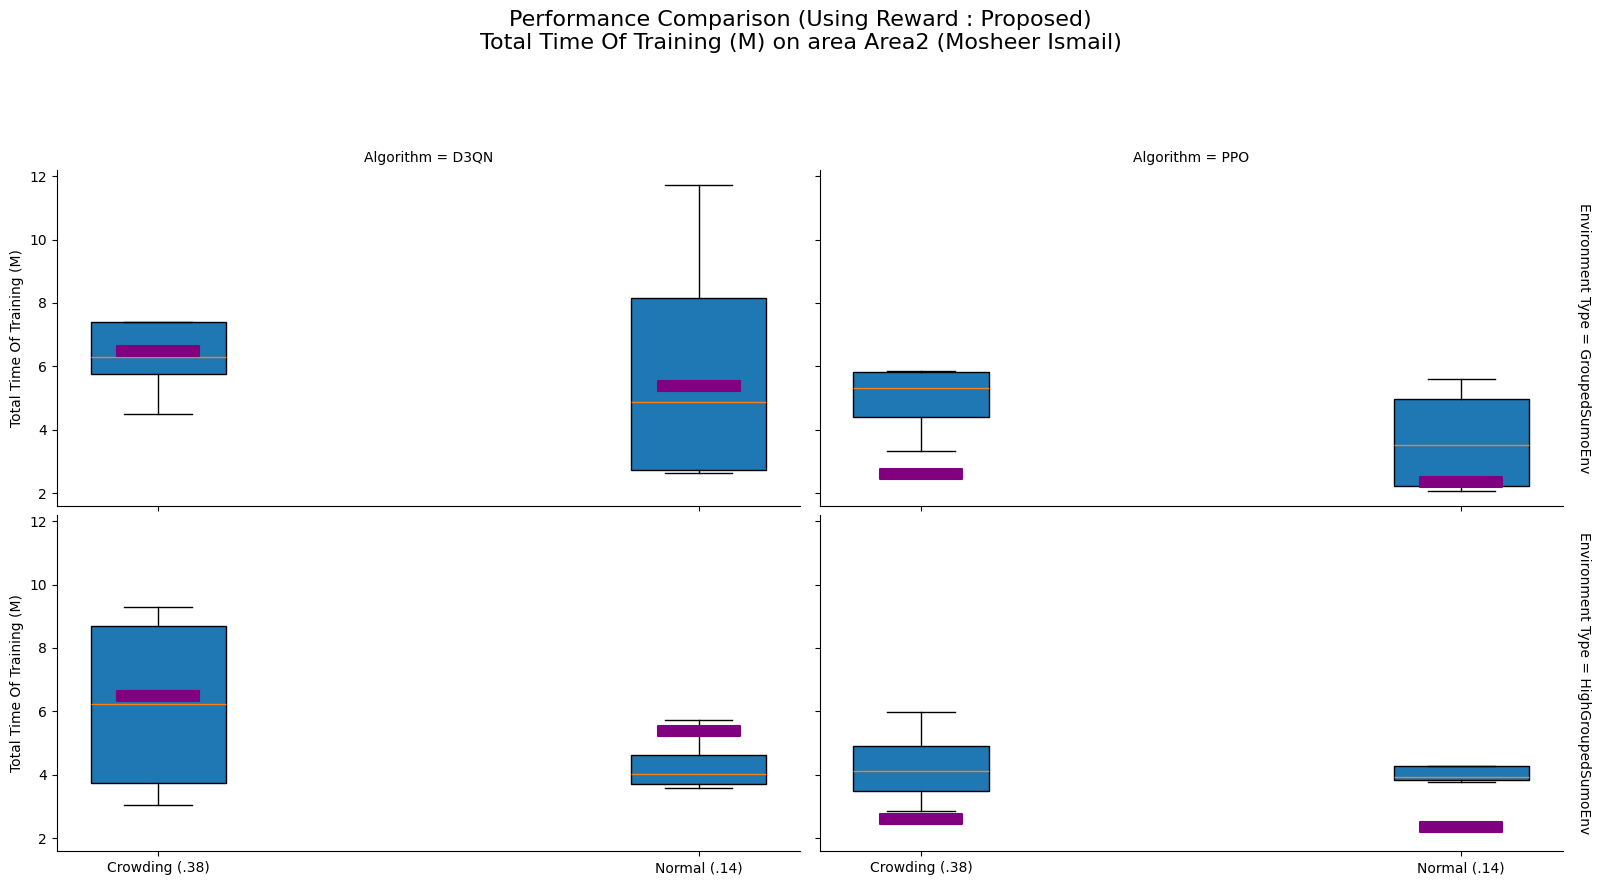

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


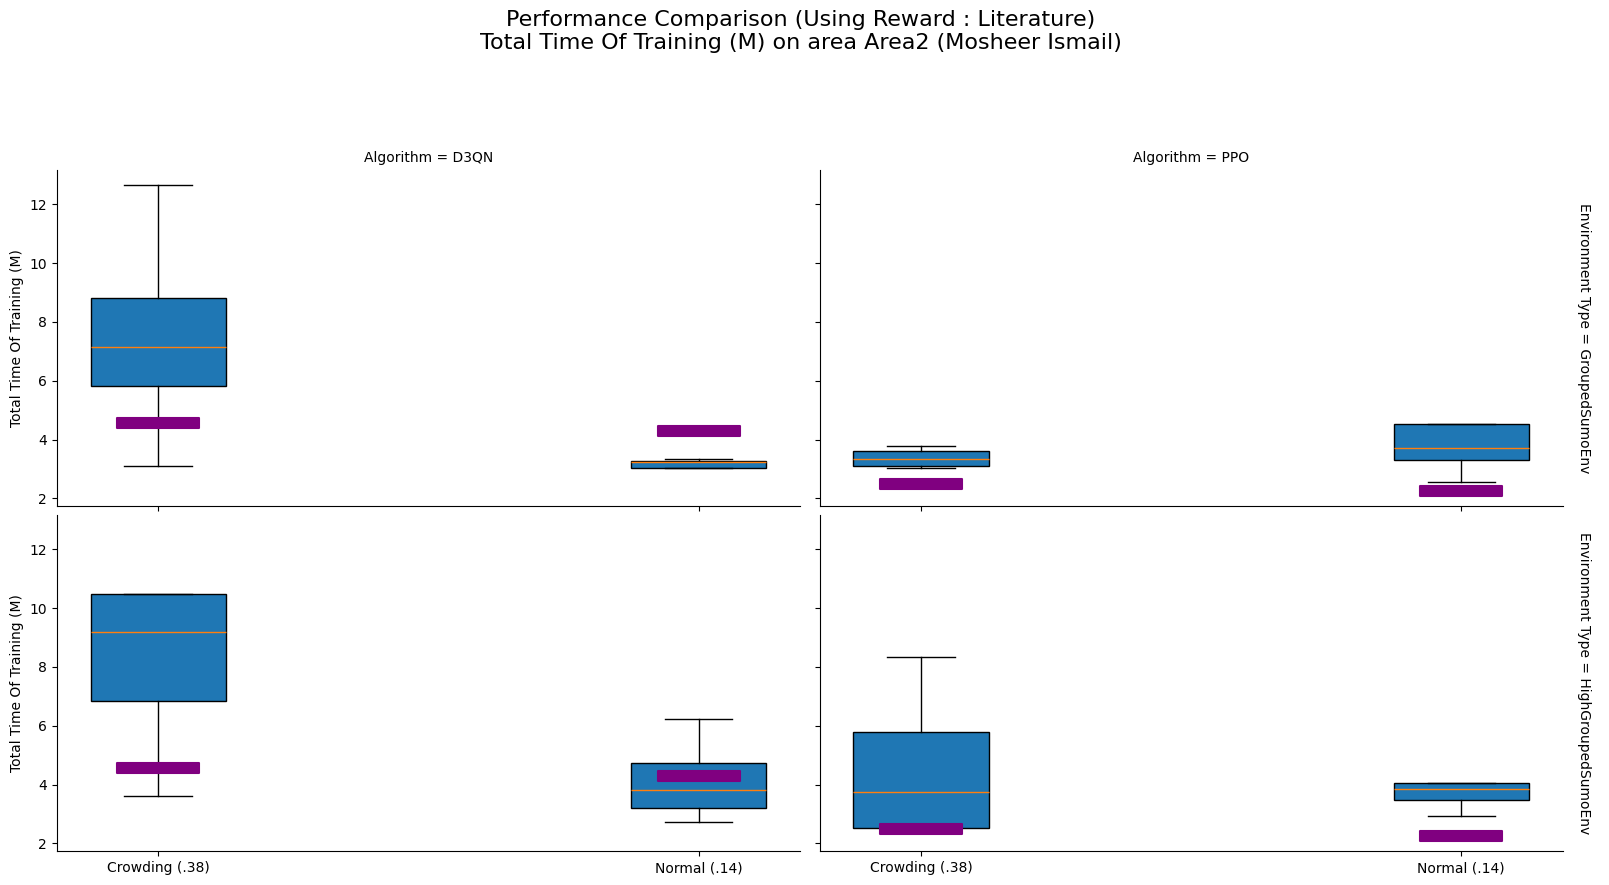

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


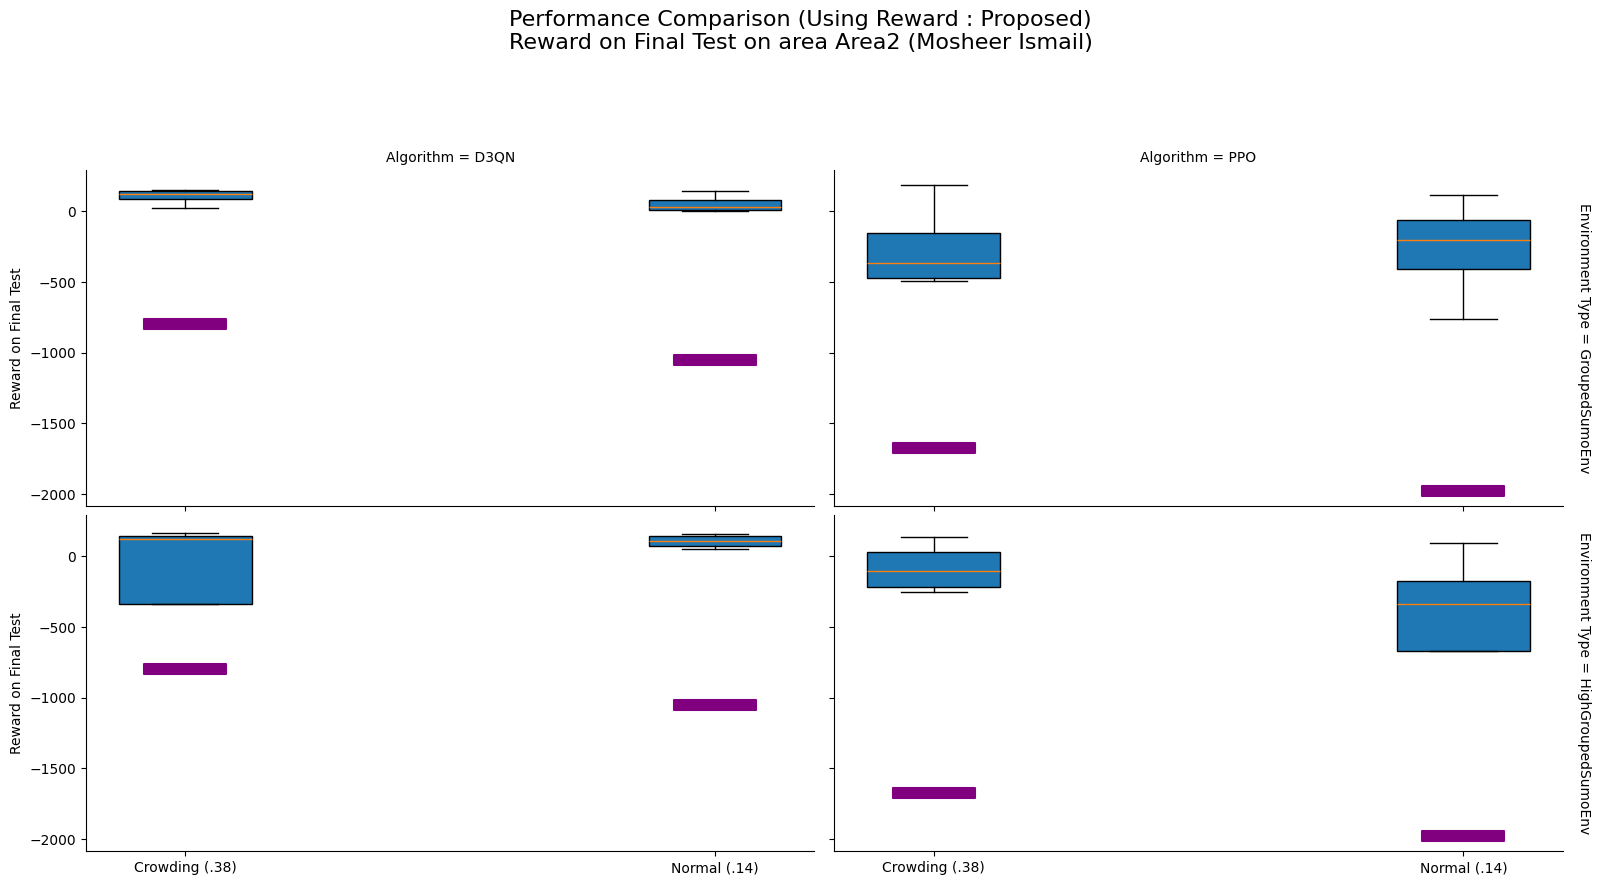

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


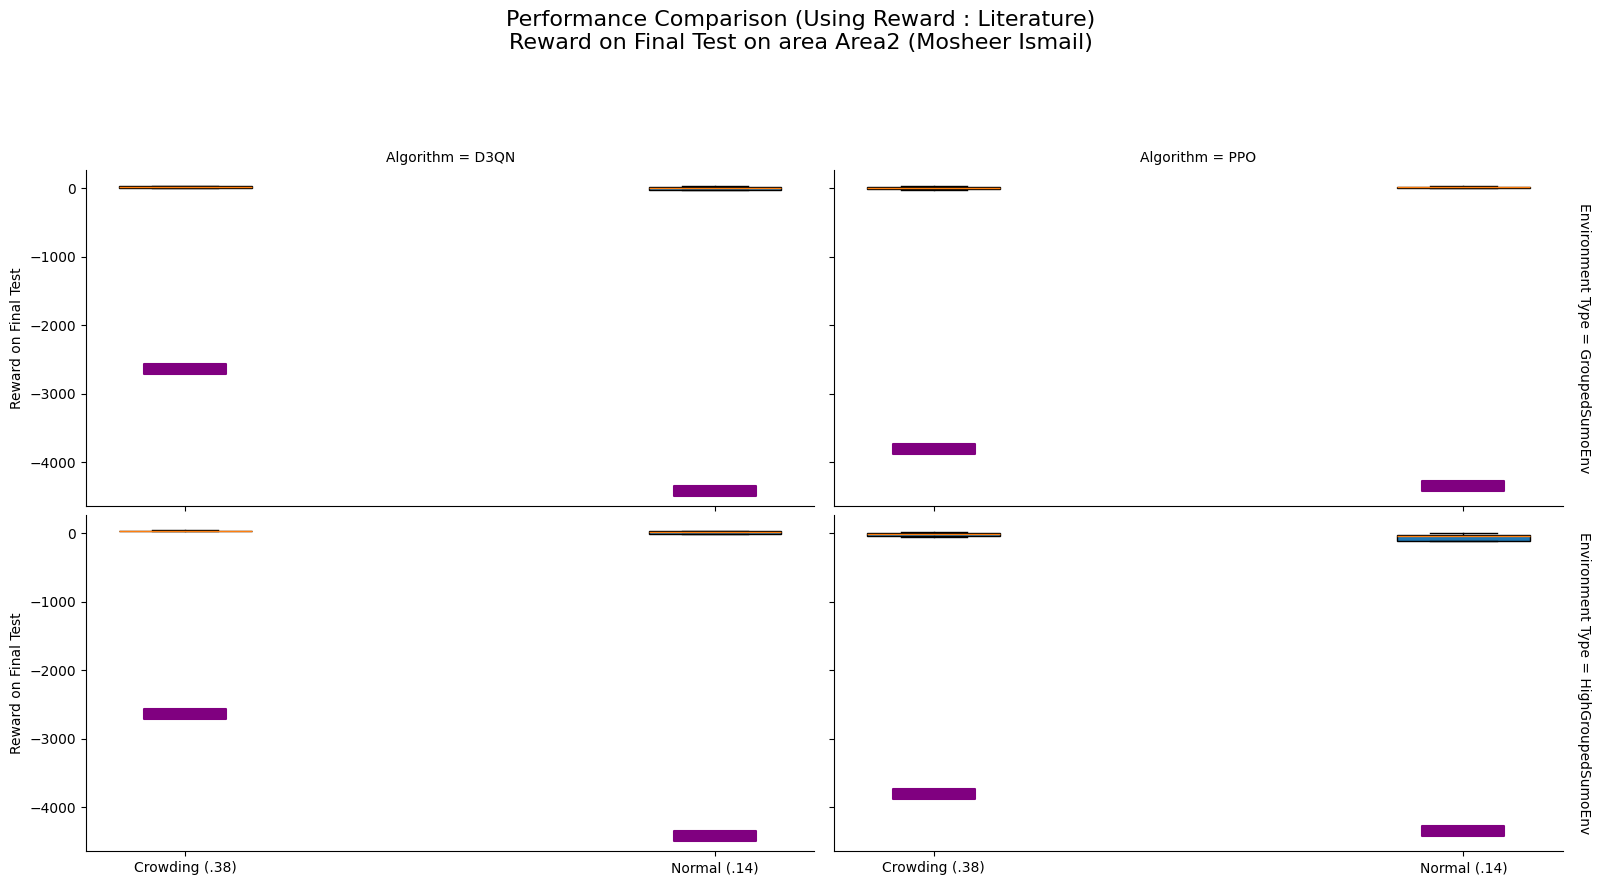

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


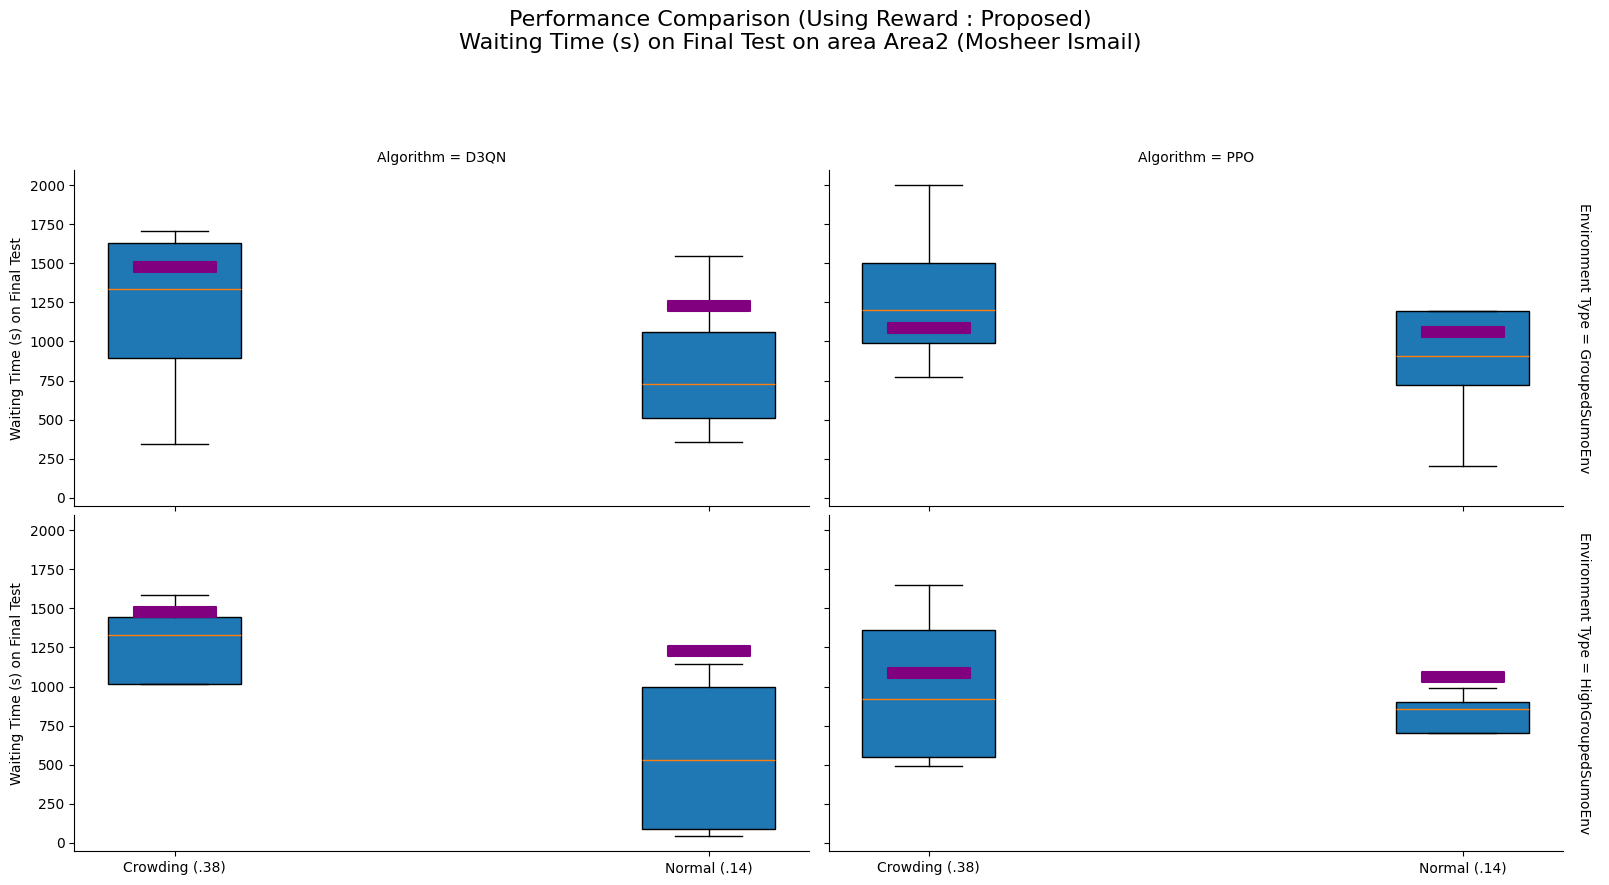

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


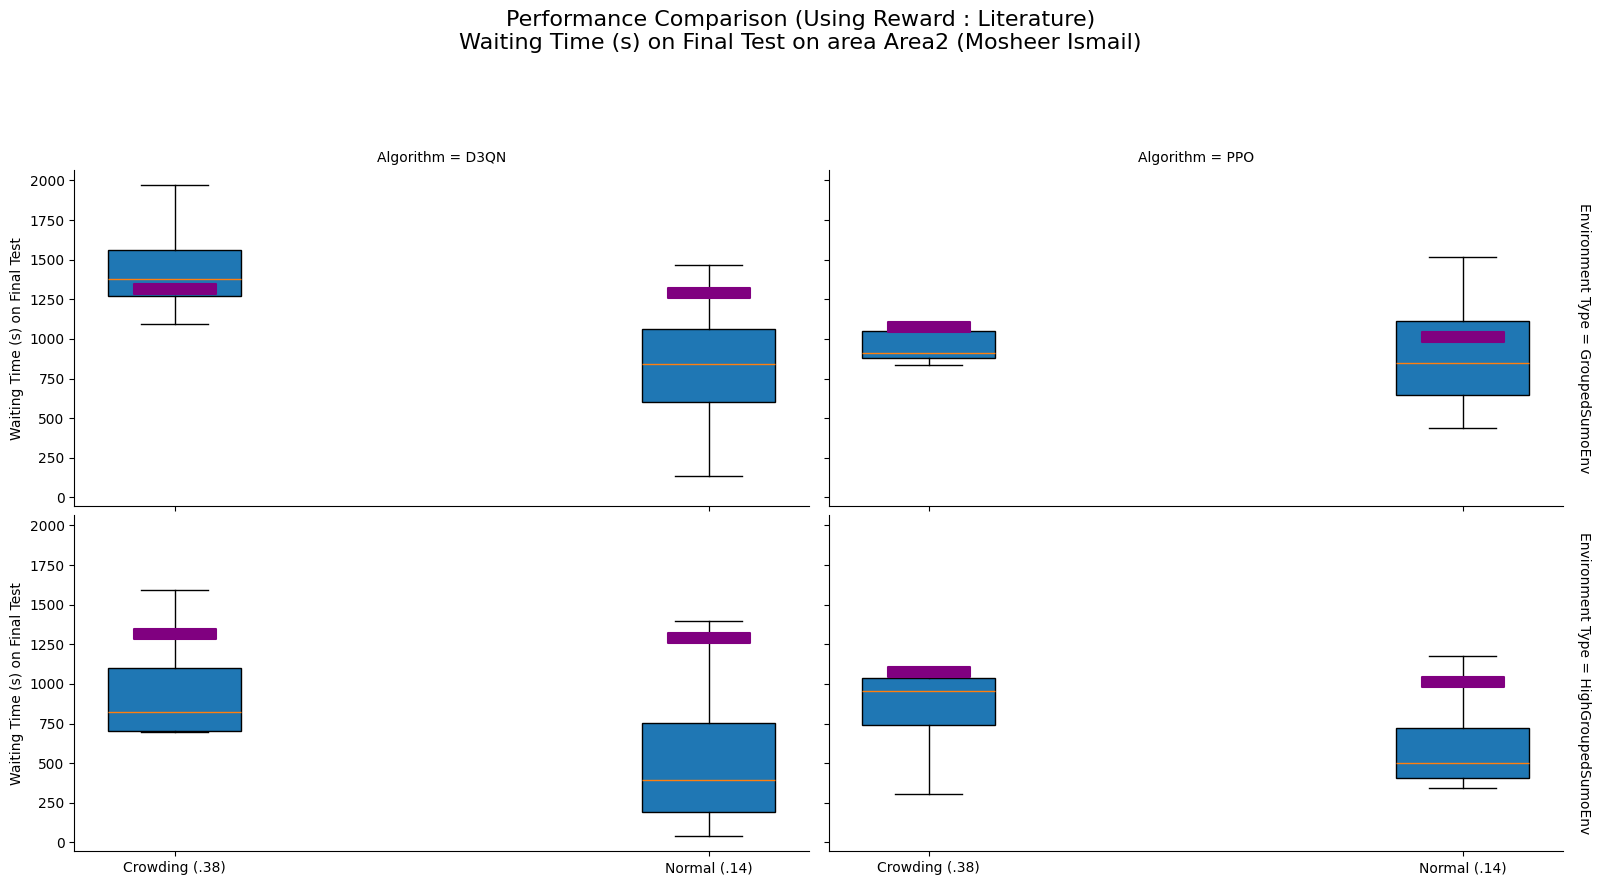

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


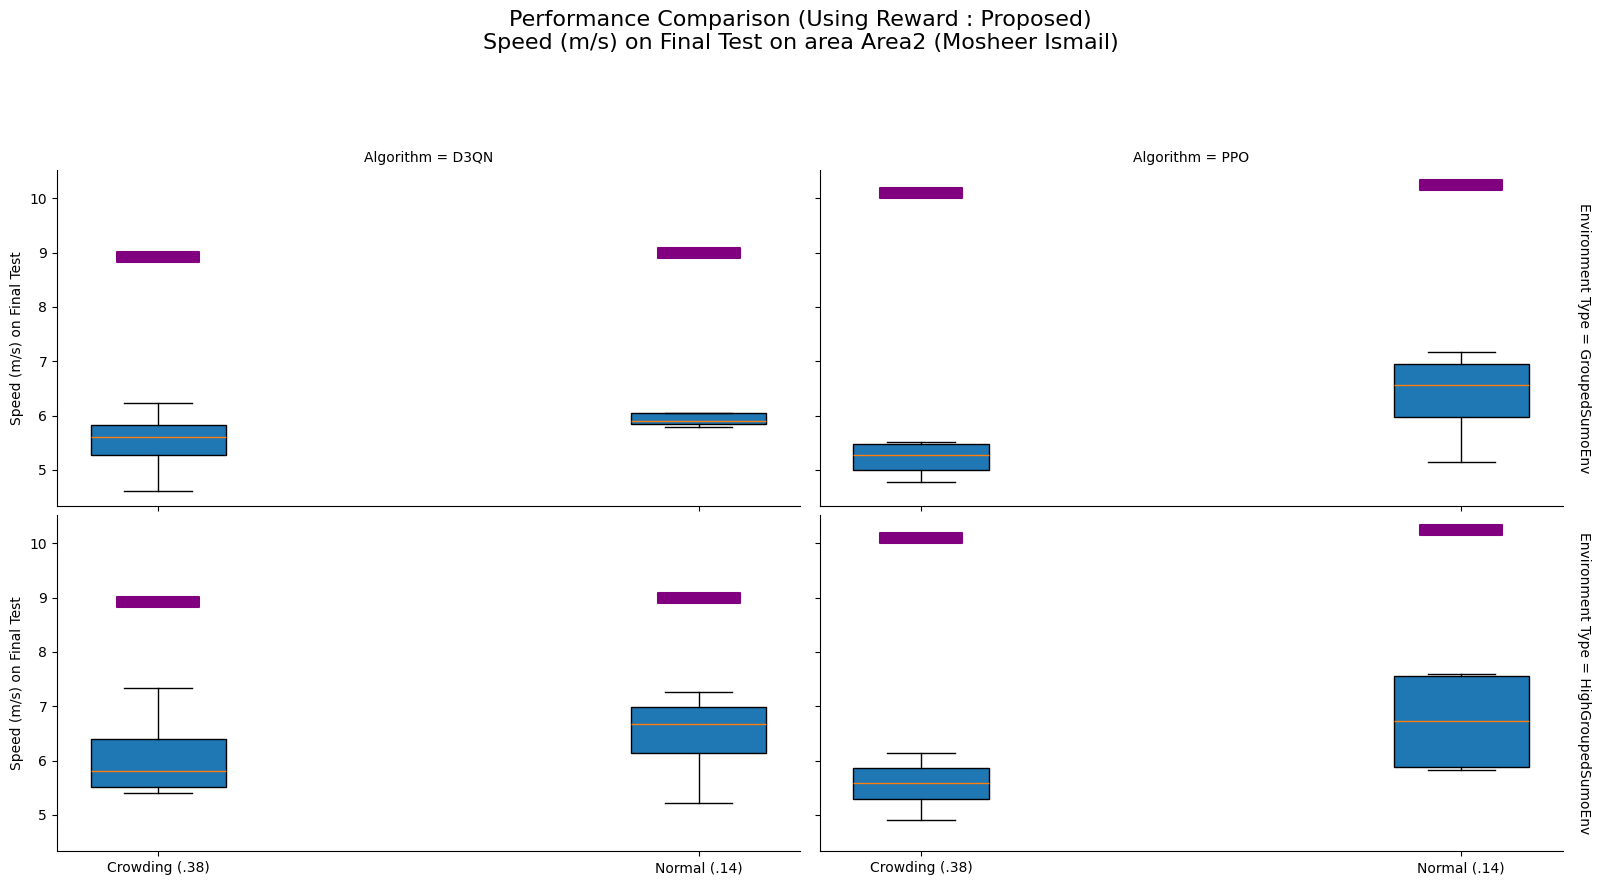

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


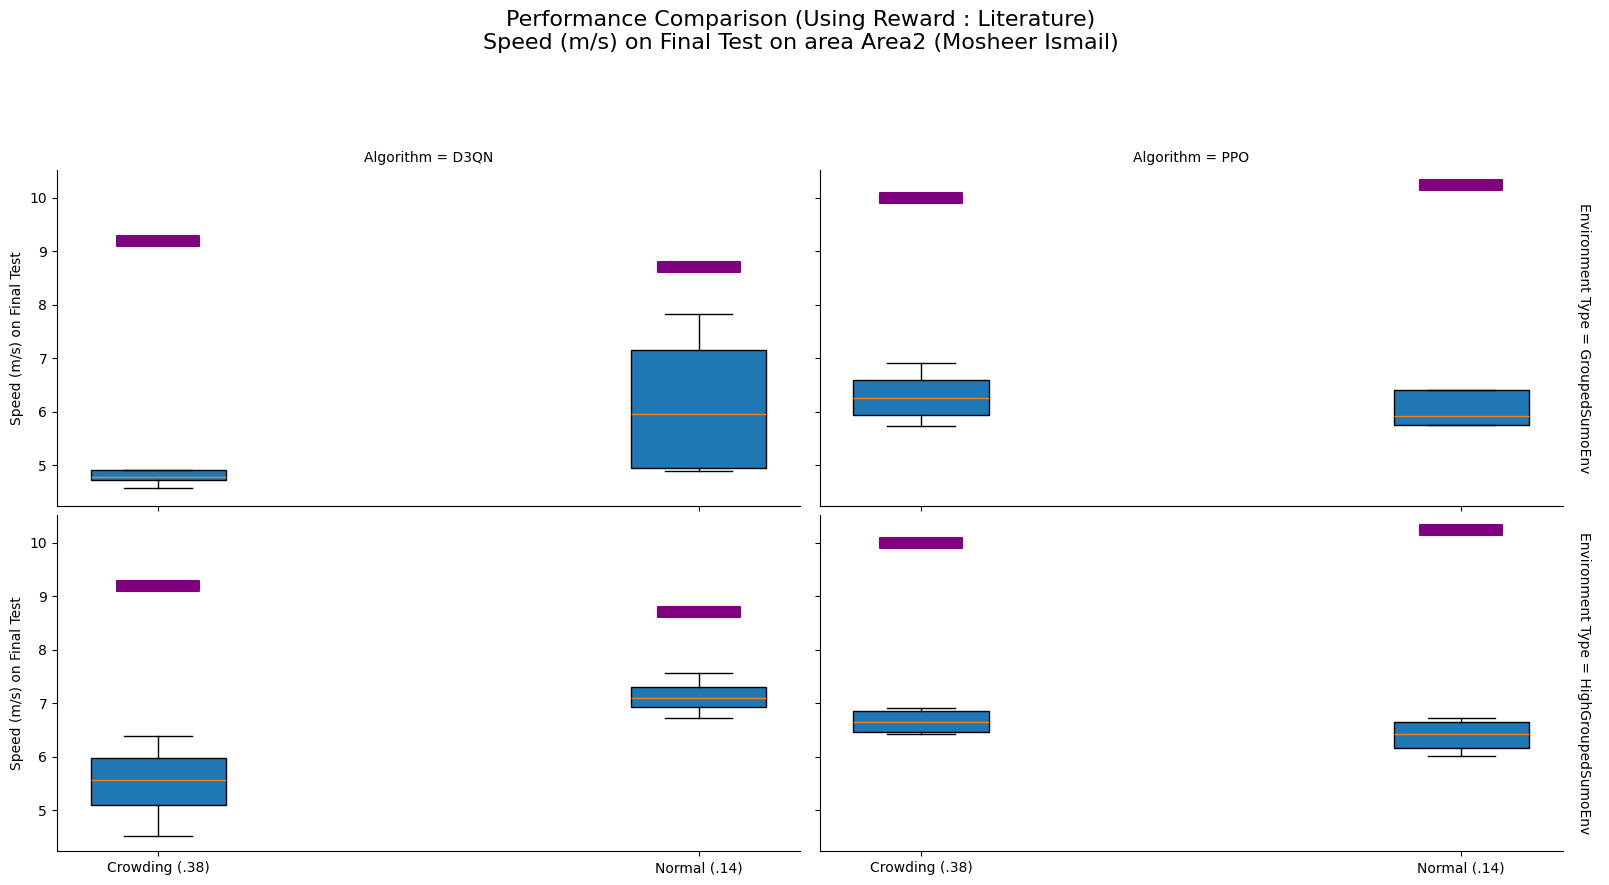

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


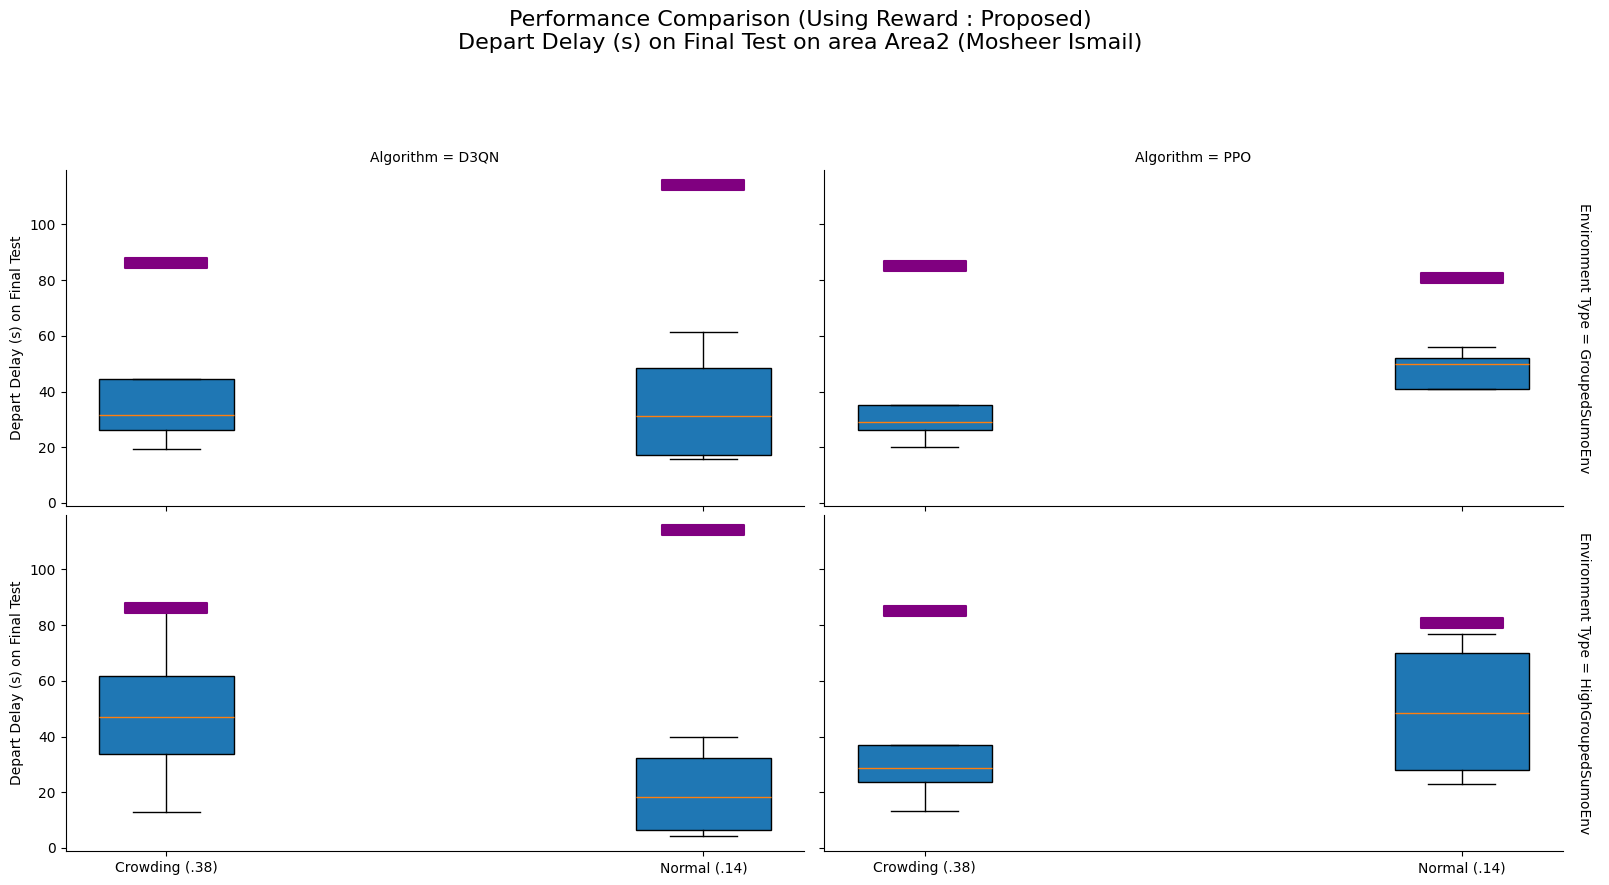

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


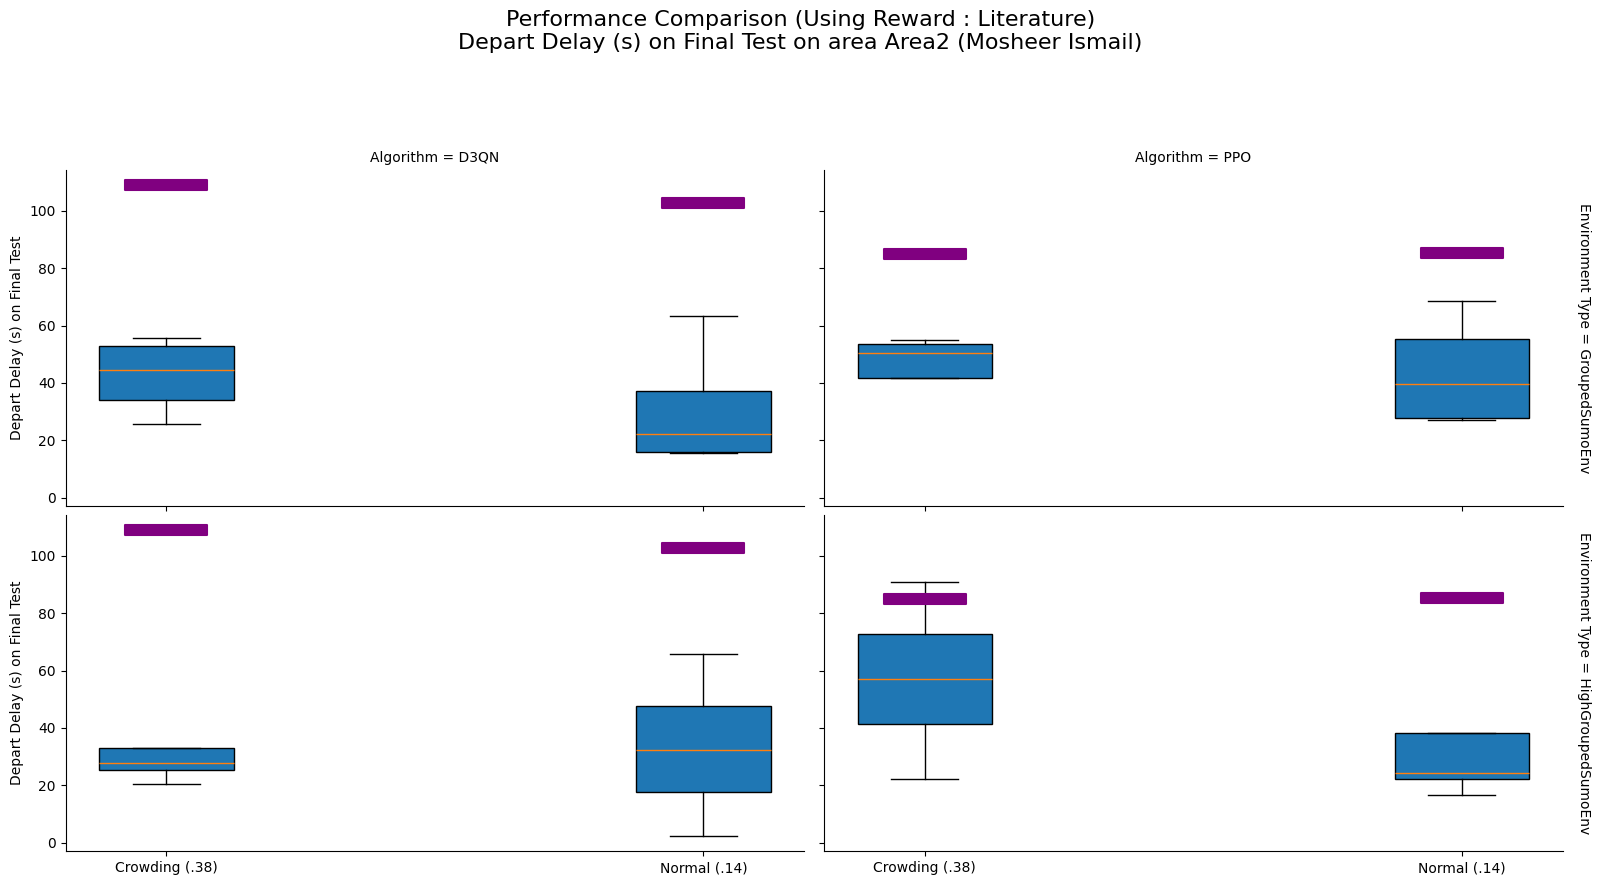

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


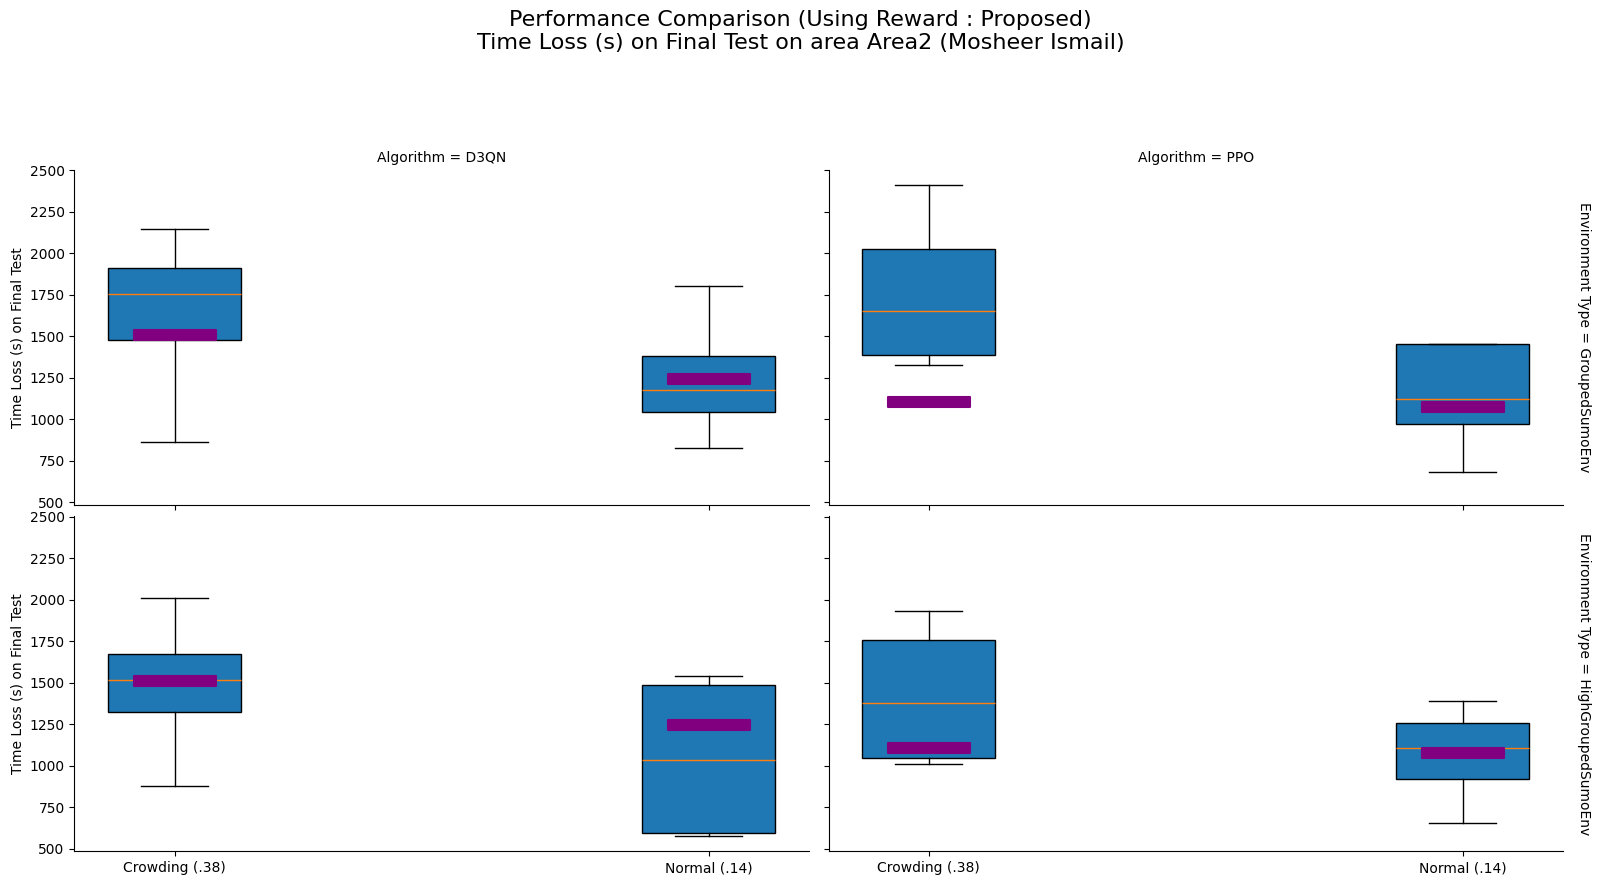

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


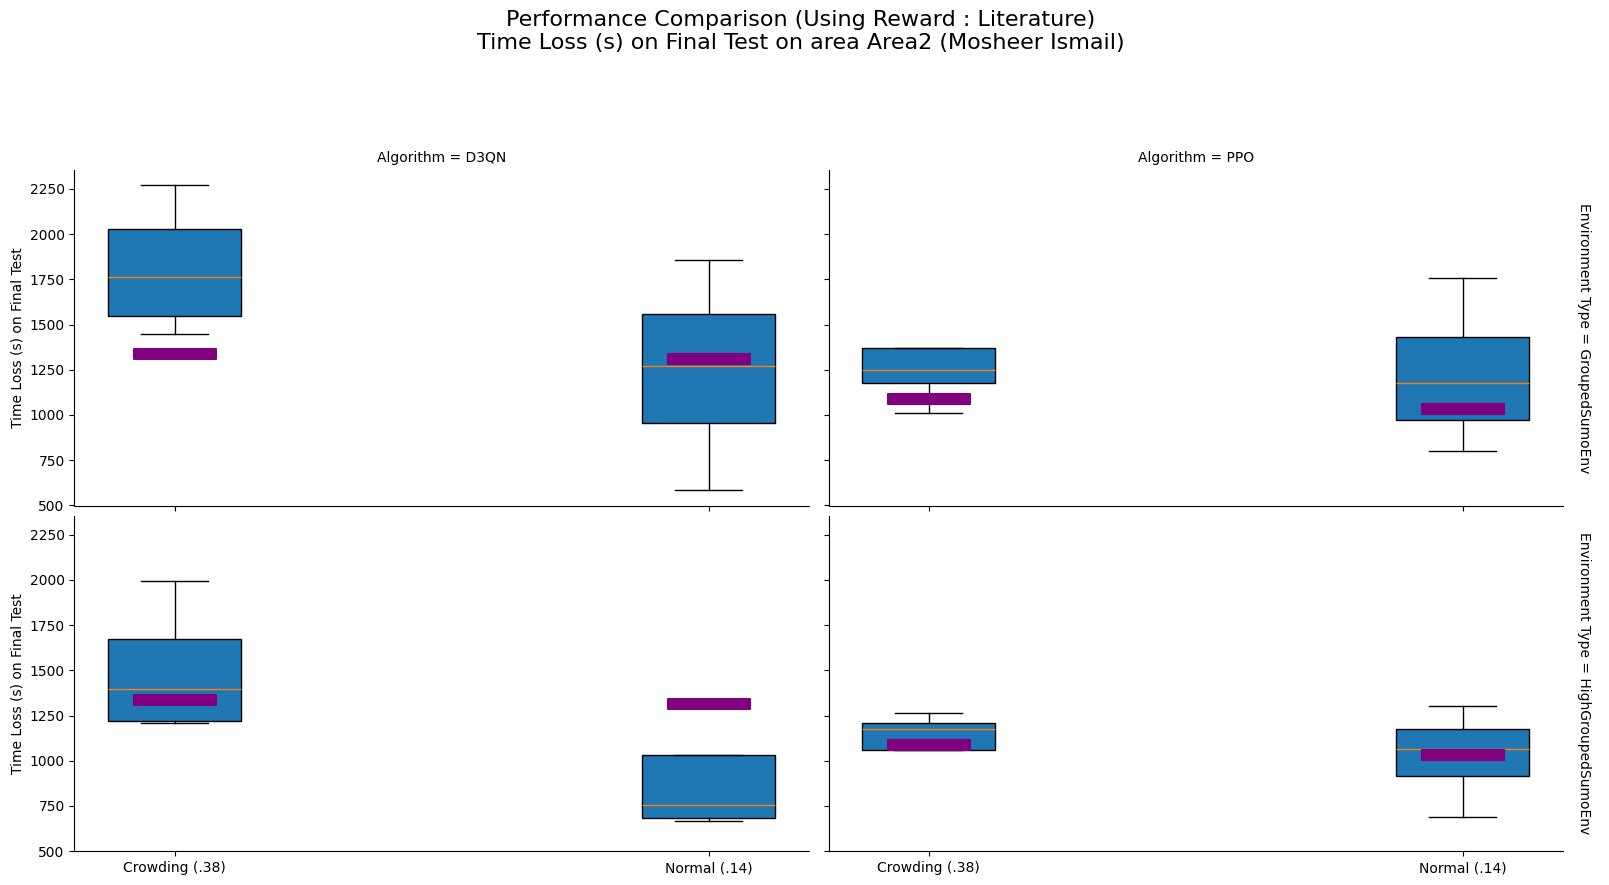

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


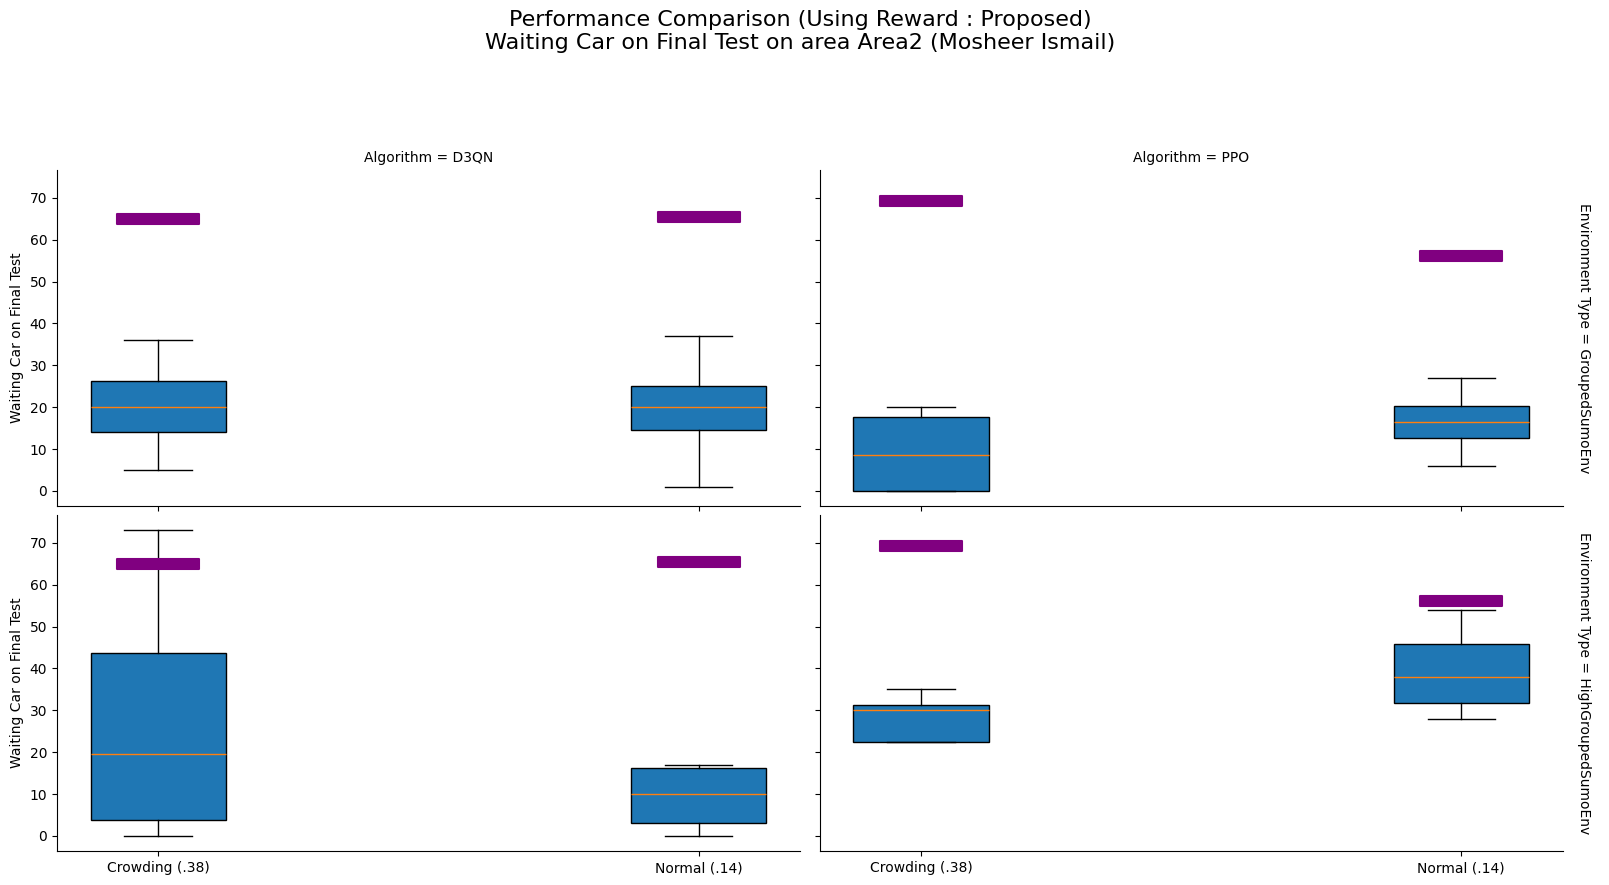

None


C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


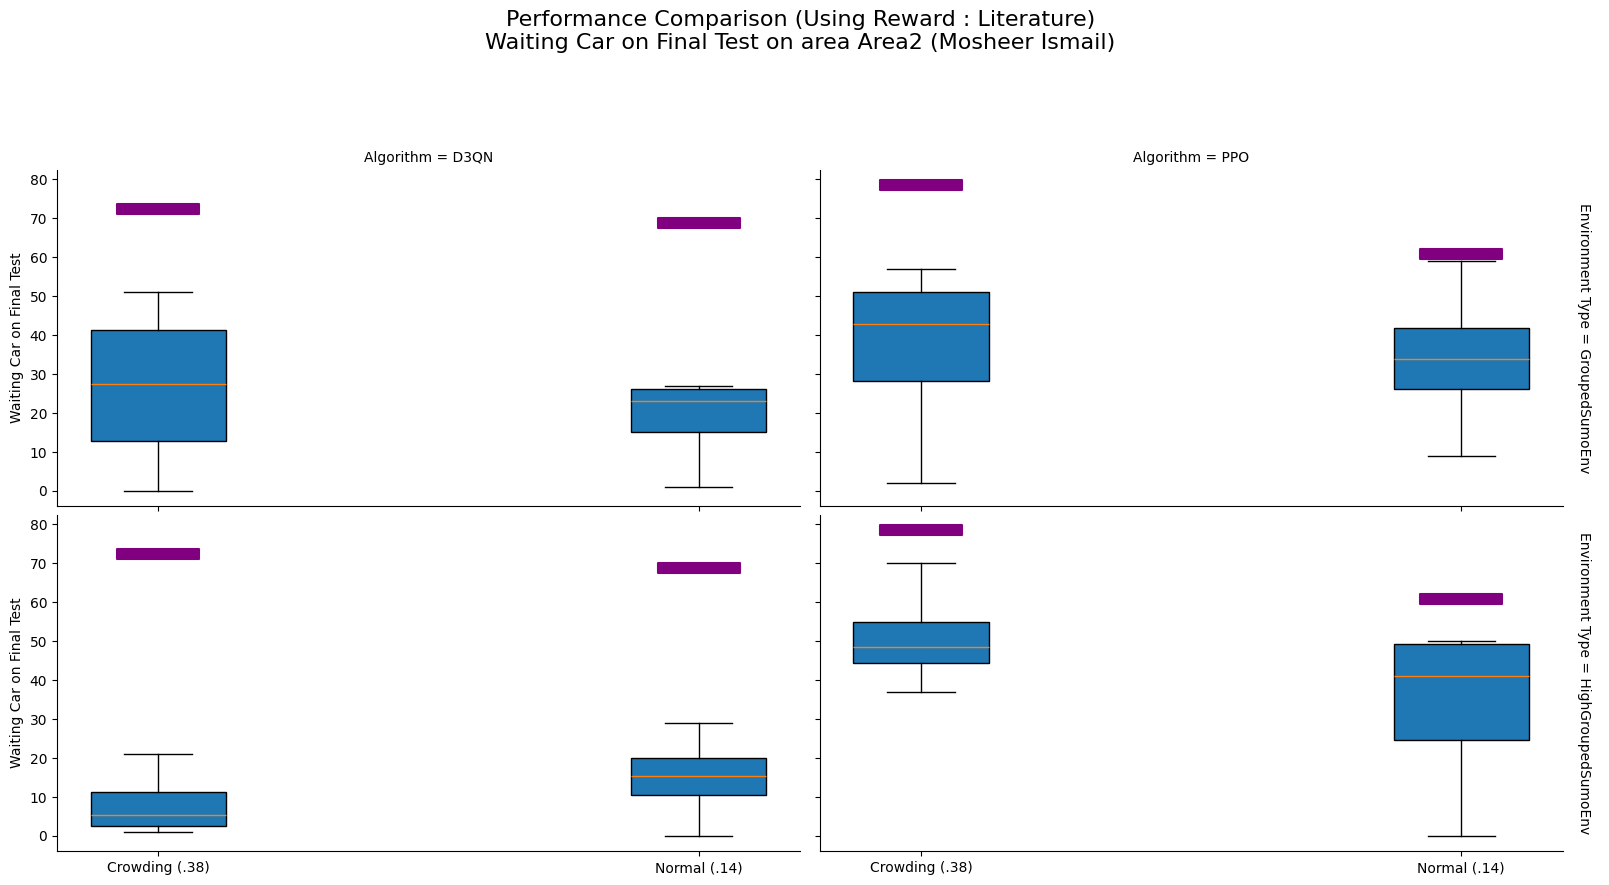

None


In [ ]:
for metric in ['Reward of Last Episode',
       'Average Reward for Evaluated Episodes With Same Time',
       'Derivative of Reward', 'Waiting Time (s)', 'Speed (m/s)',
       'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car',
       'Total Time Of Training (M)', 'Reward on Final Test',
       'Waiting Time (s) on Final Test', 'Speed (m/s) on Final Test',
       'Depart Delay (s) on Final Test', 'Time Loss (s) on Final Test',
       'Waiting Car on Final Test']:
    for reward_ in ['Proposed','Literature']:
         print(plot_with_benchmark(data_exp,data_bench_grouped,"Area2 (Mosheer Ismail)",metric,reward= reward_))

    

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


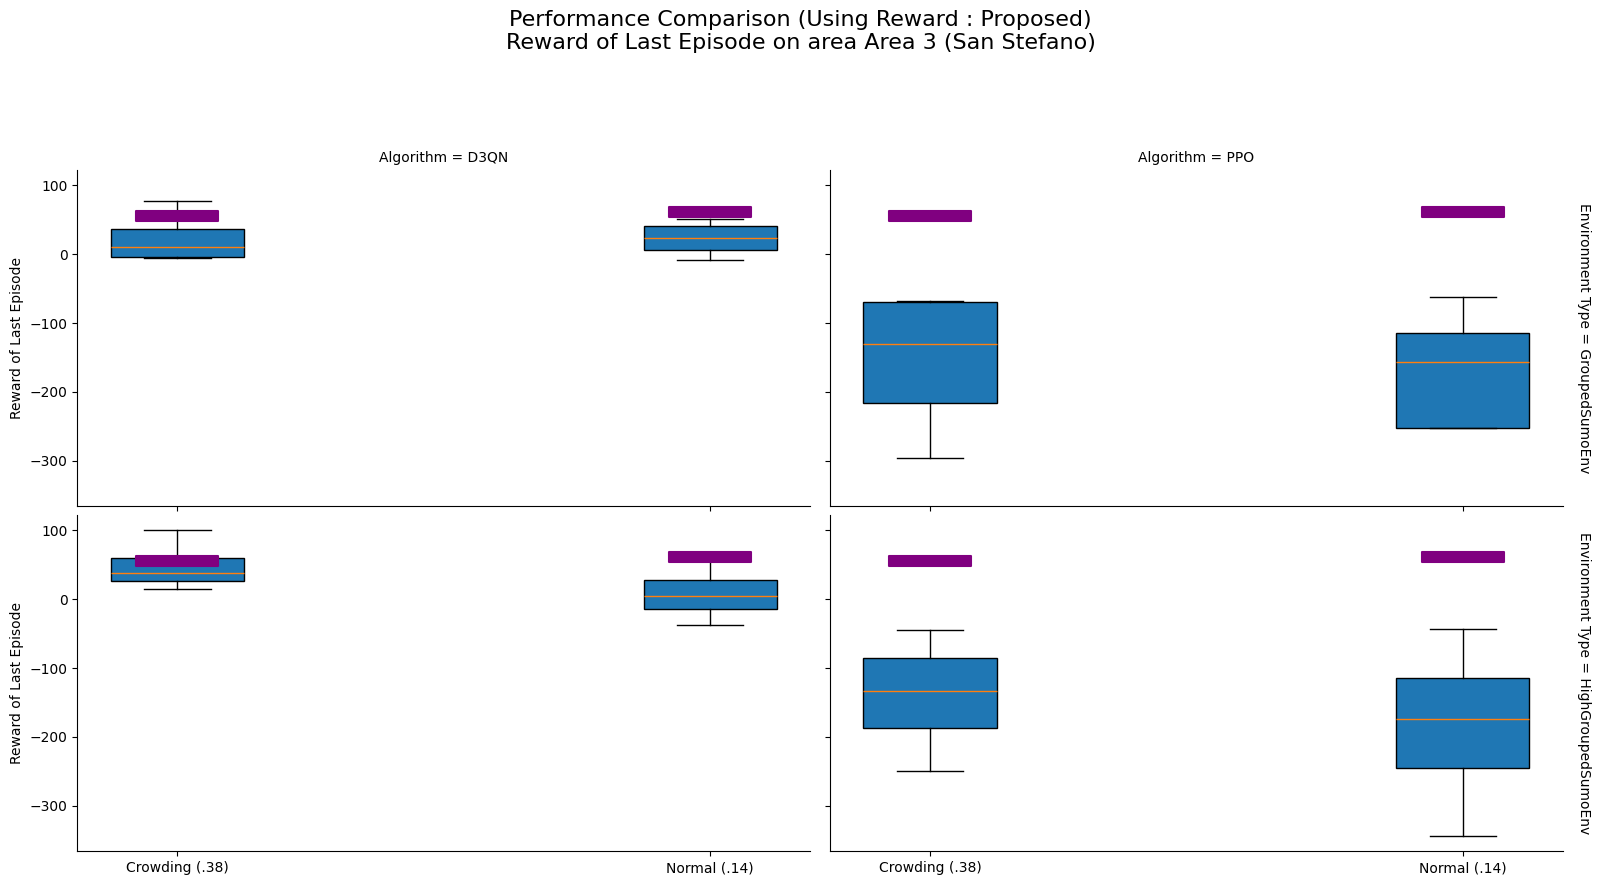

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


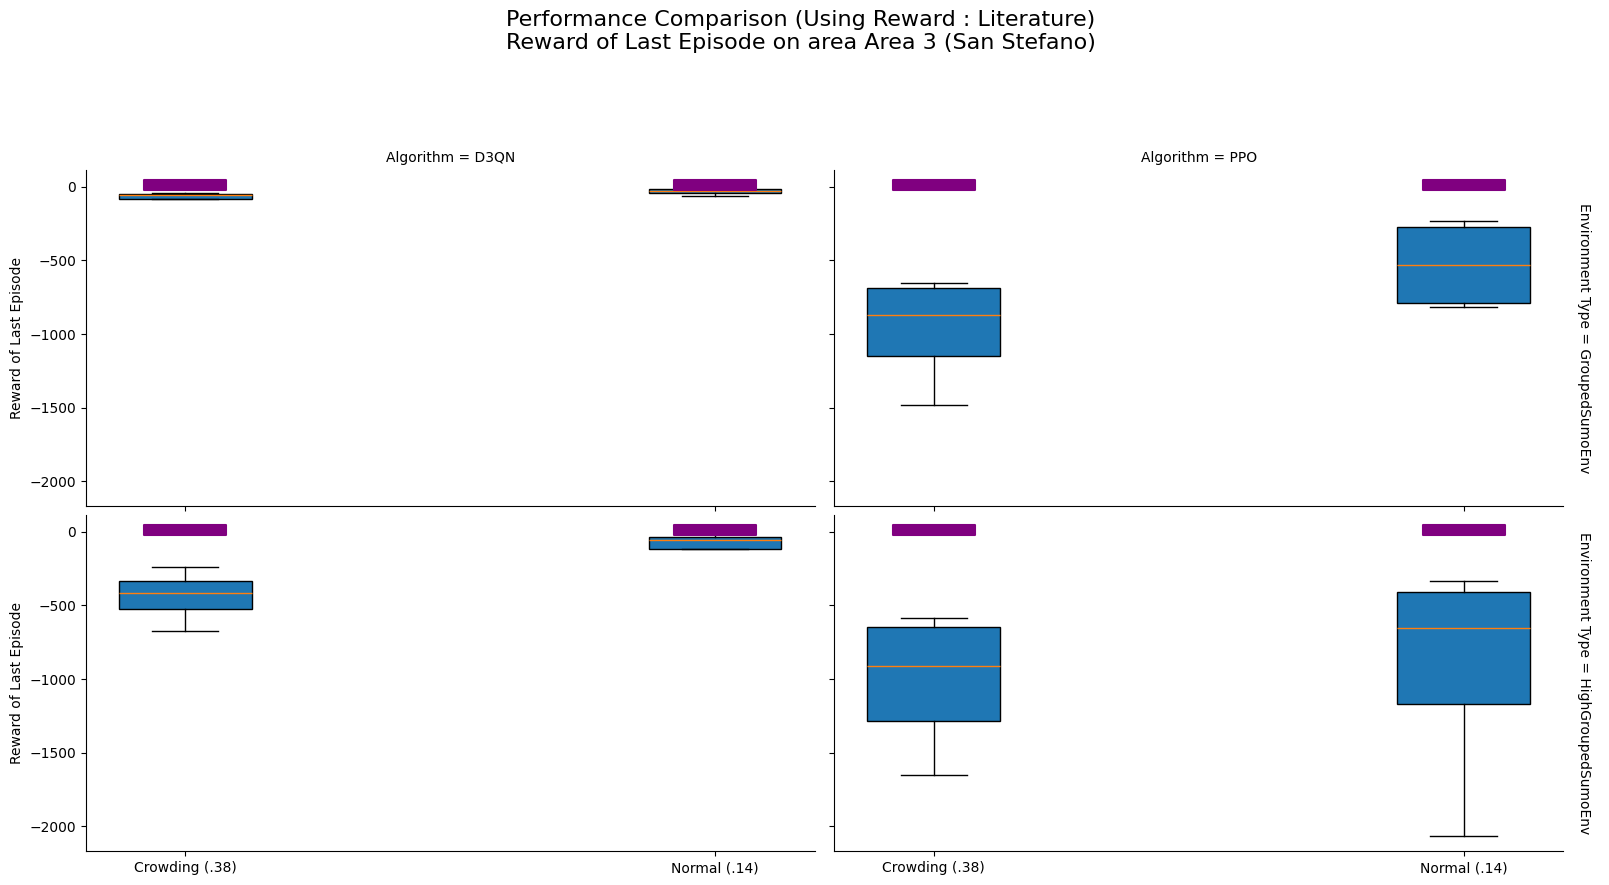

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


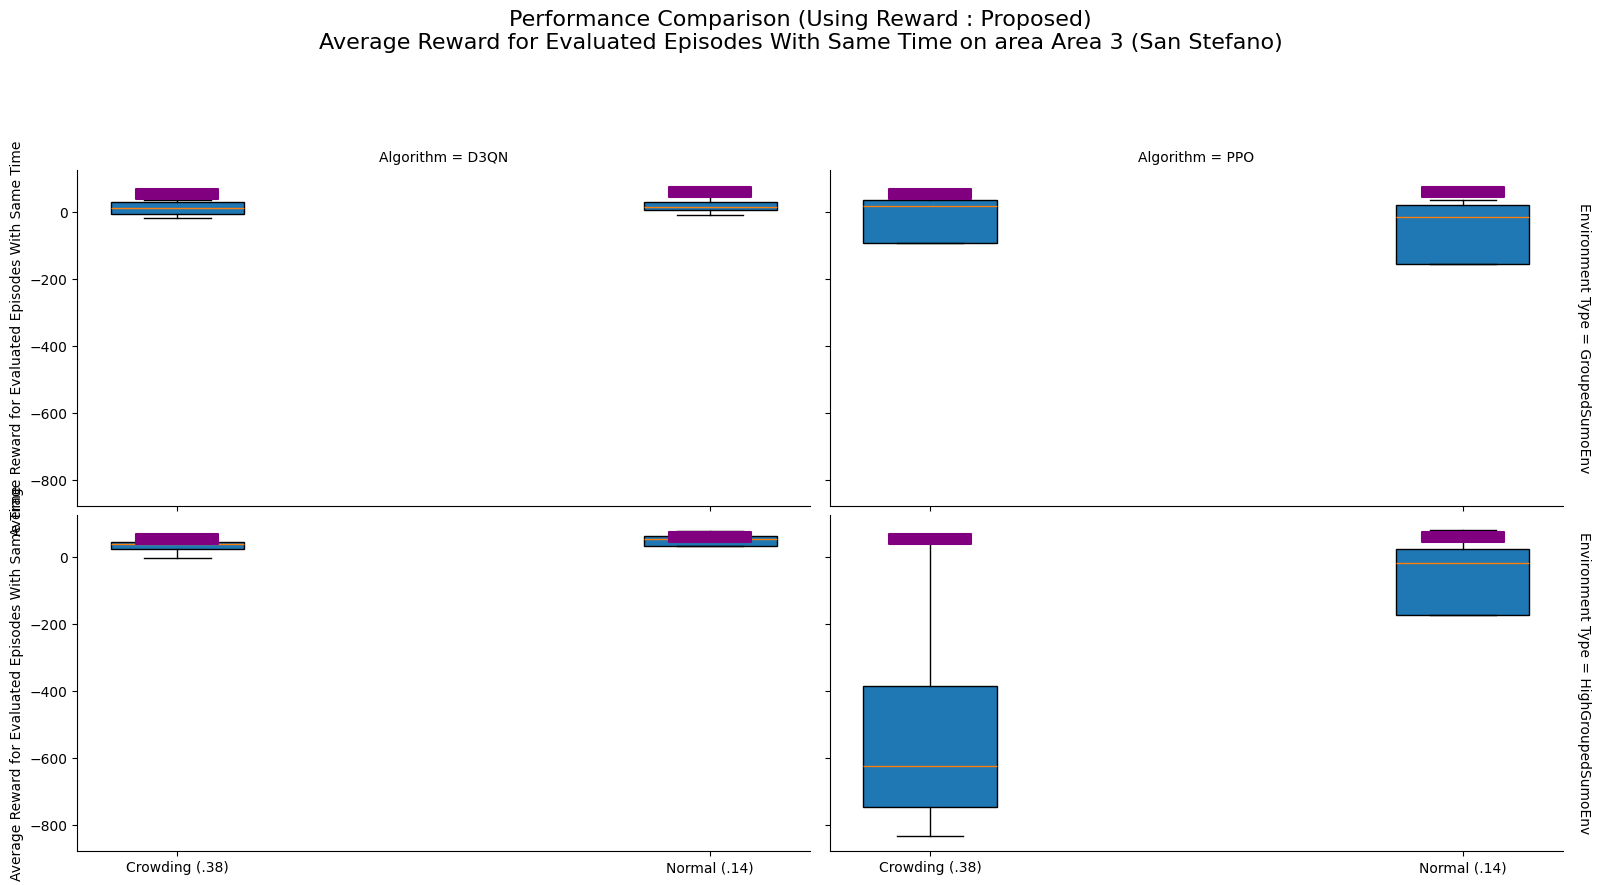

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


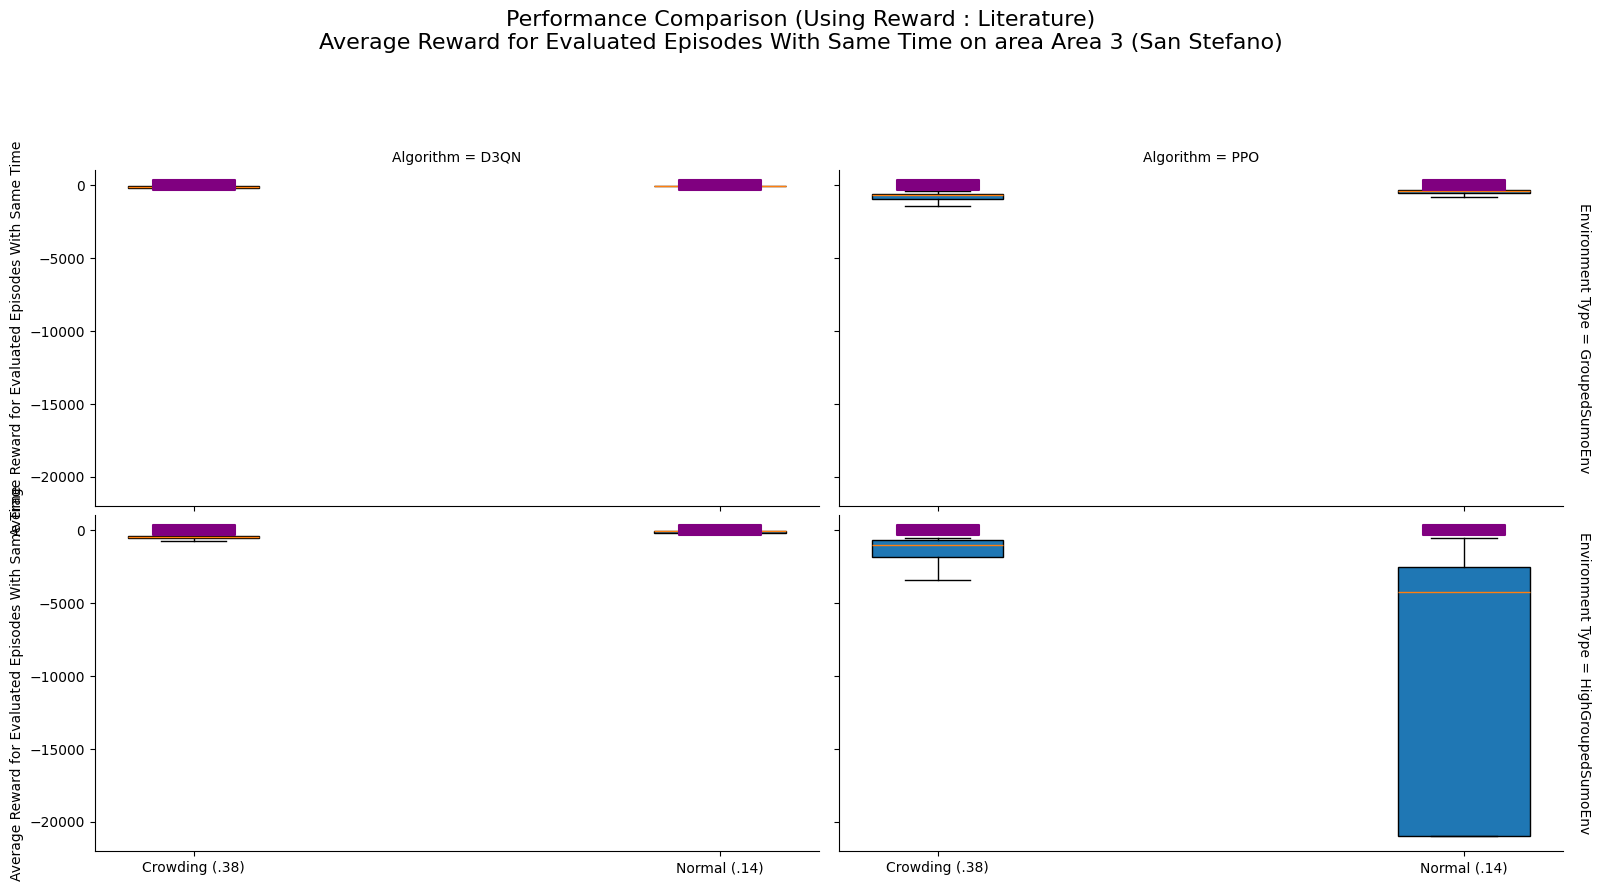

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


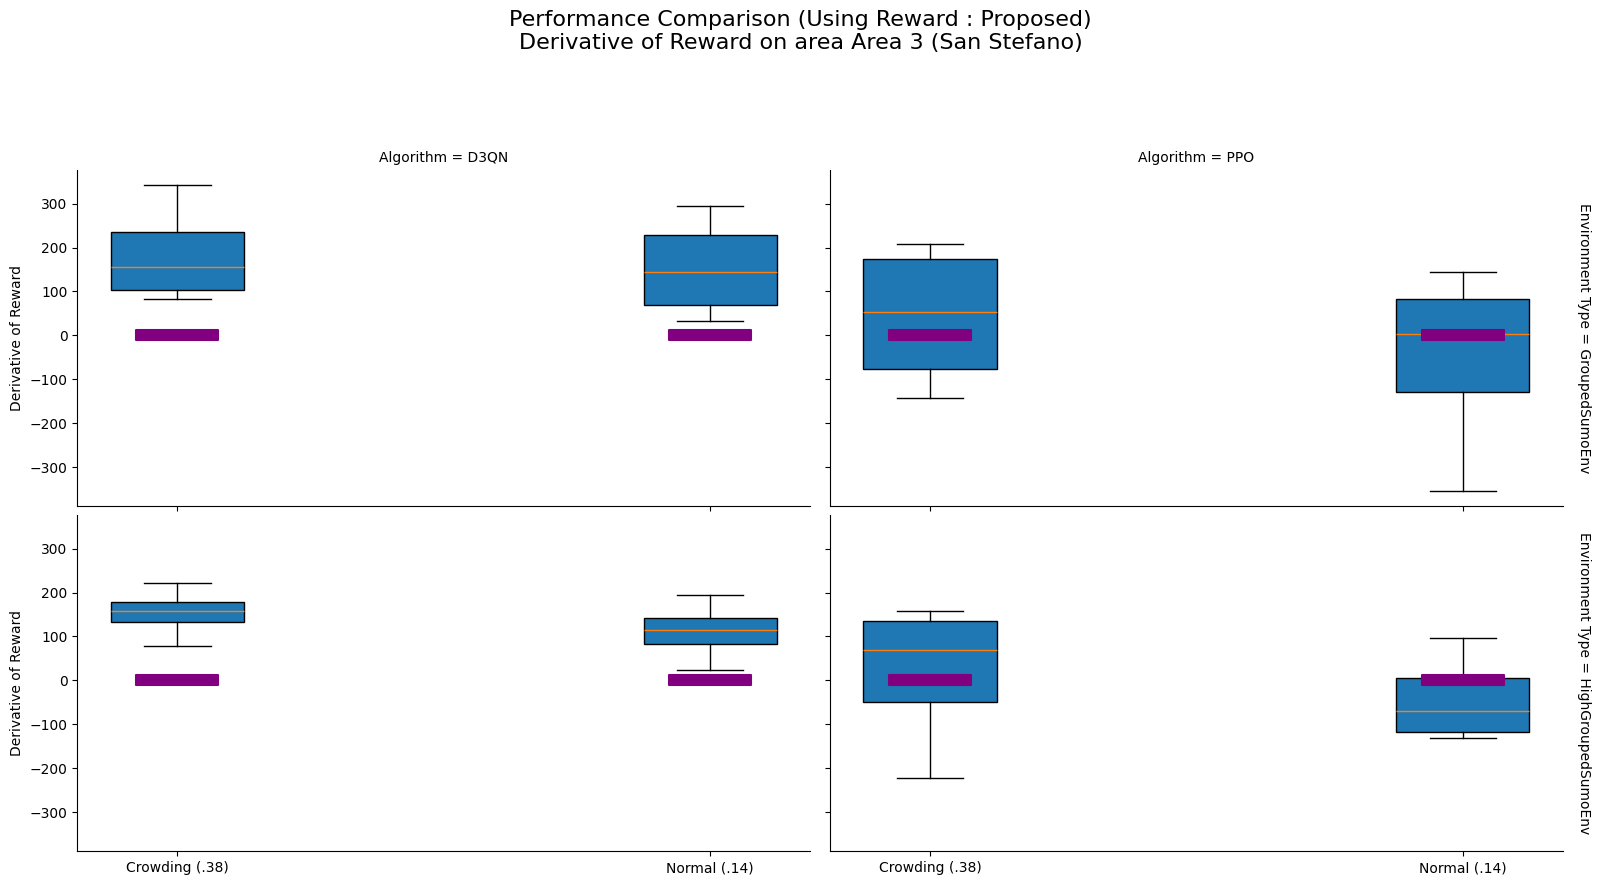

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


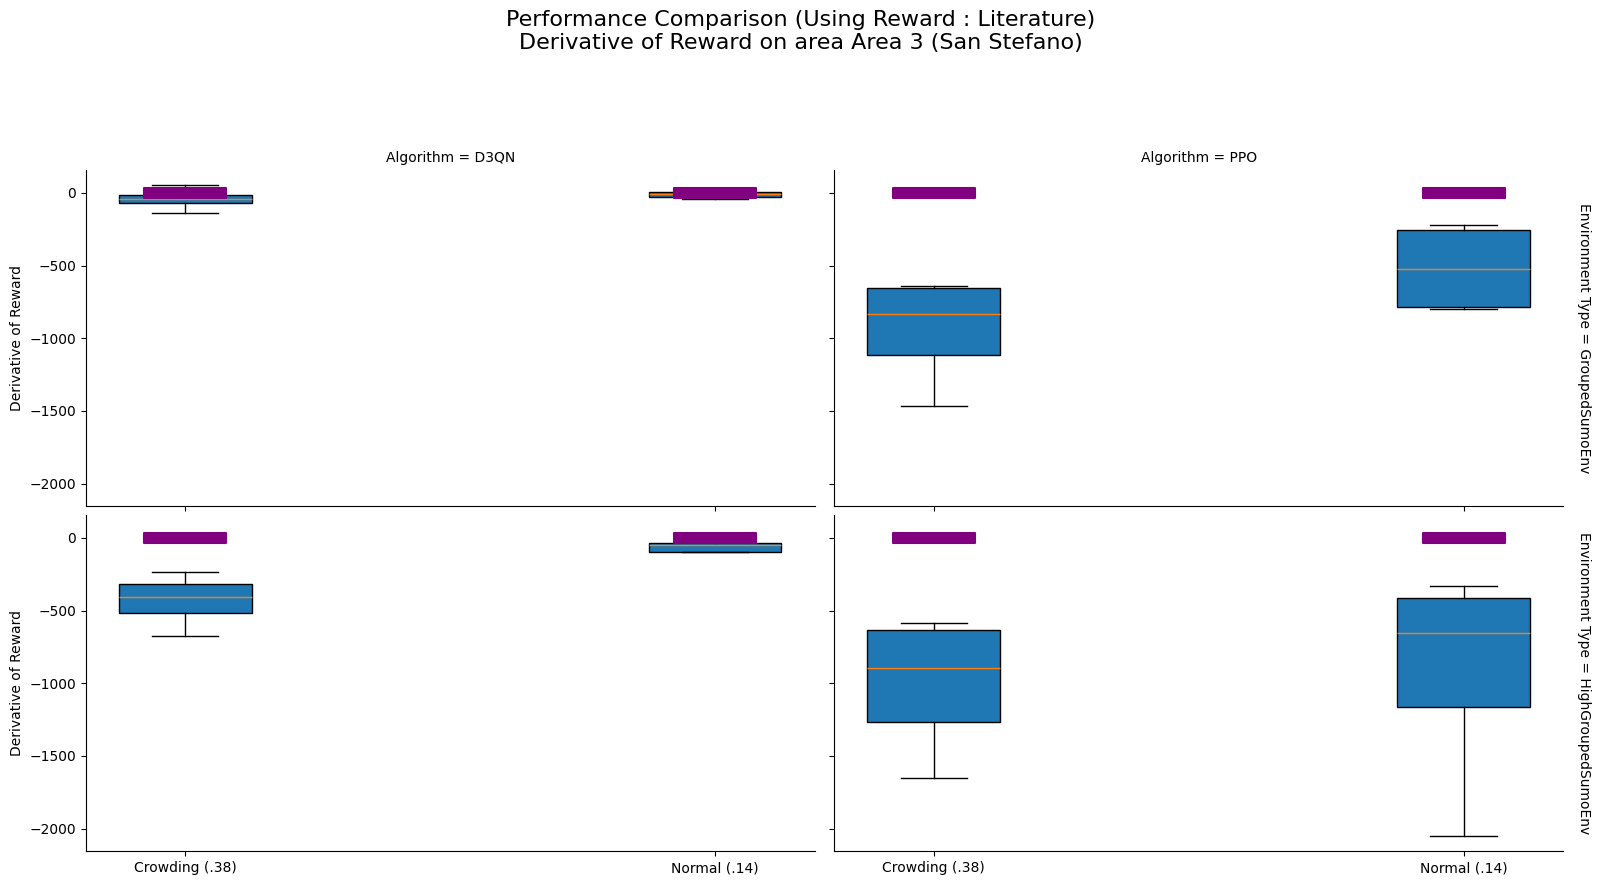

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


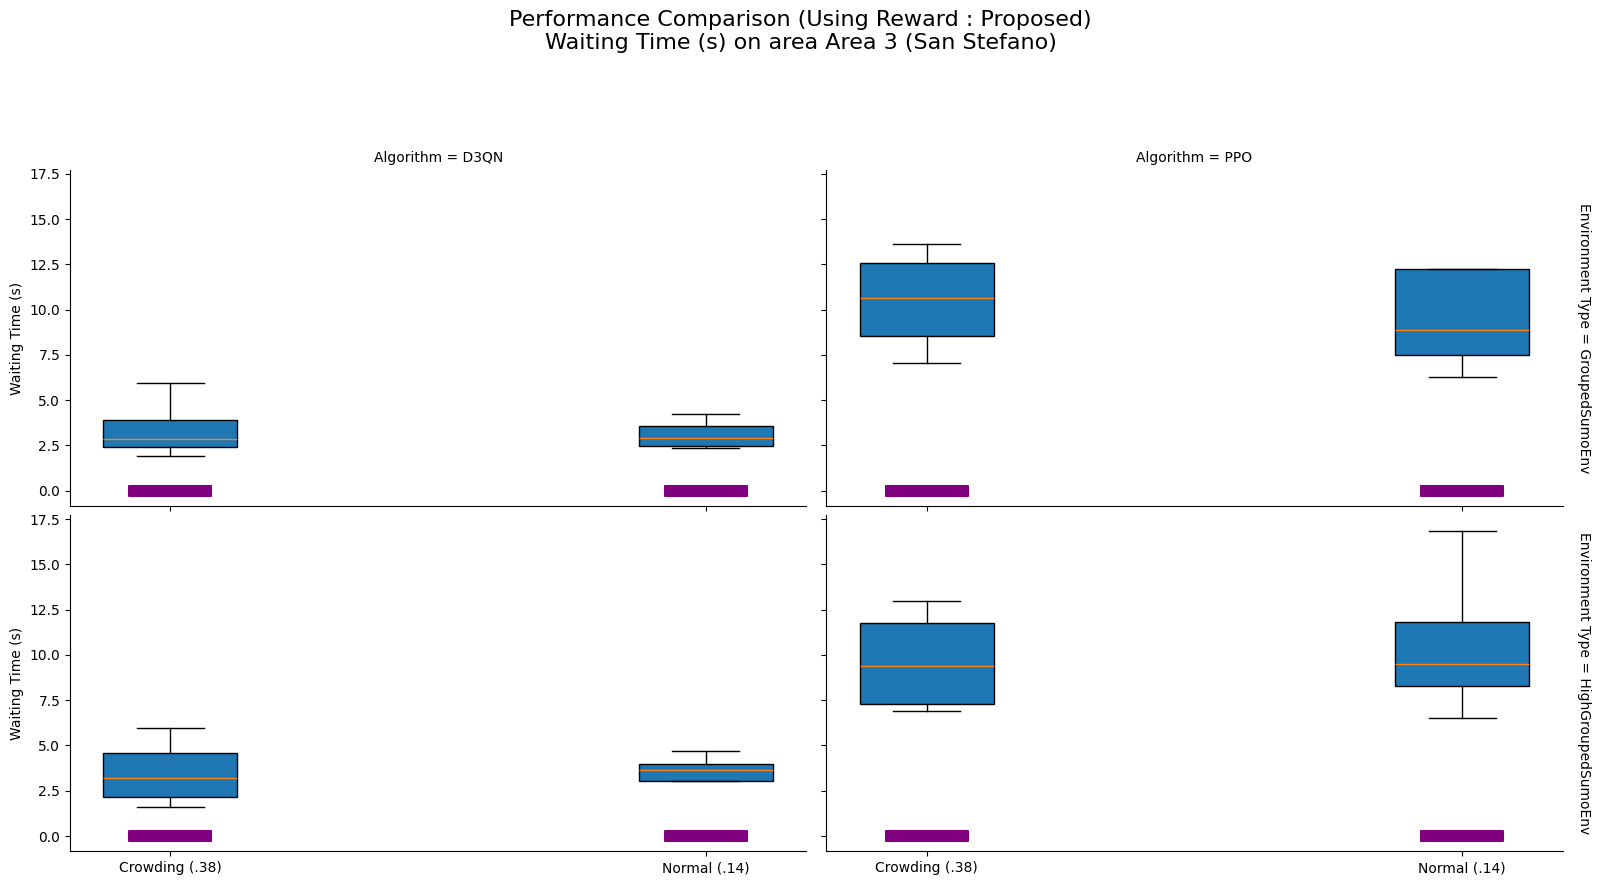

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


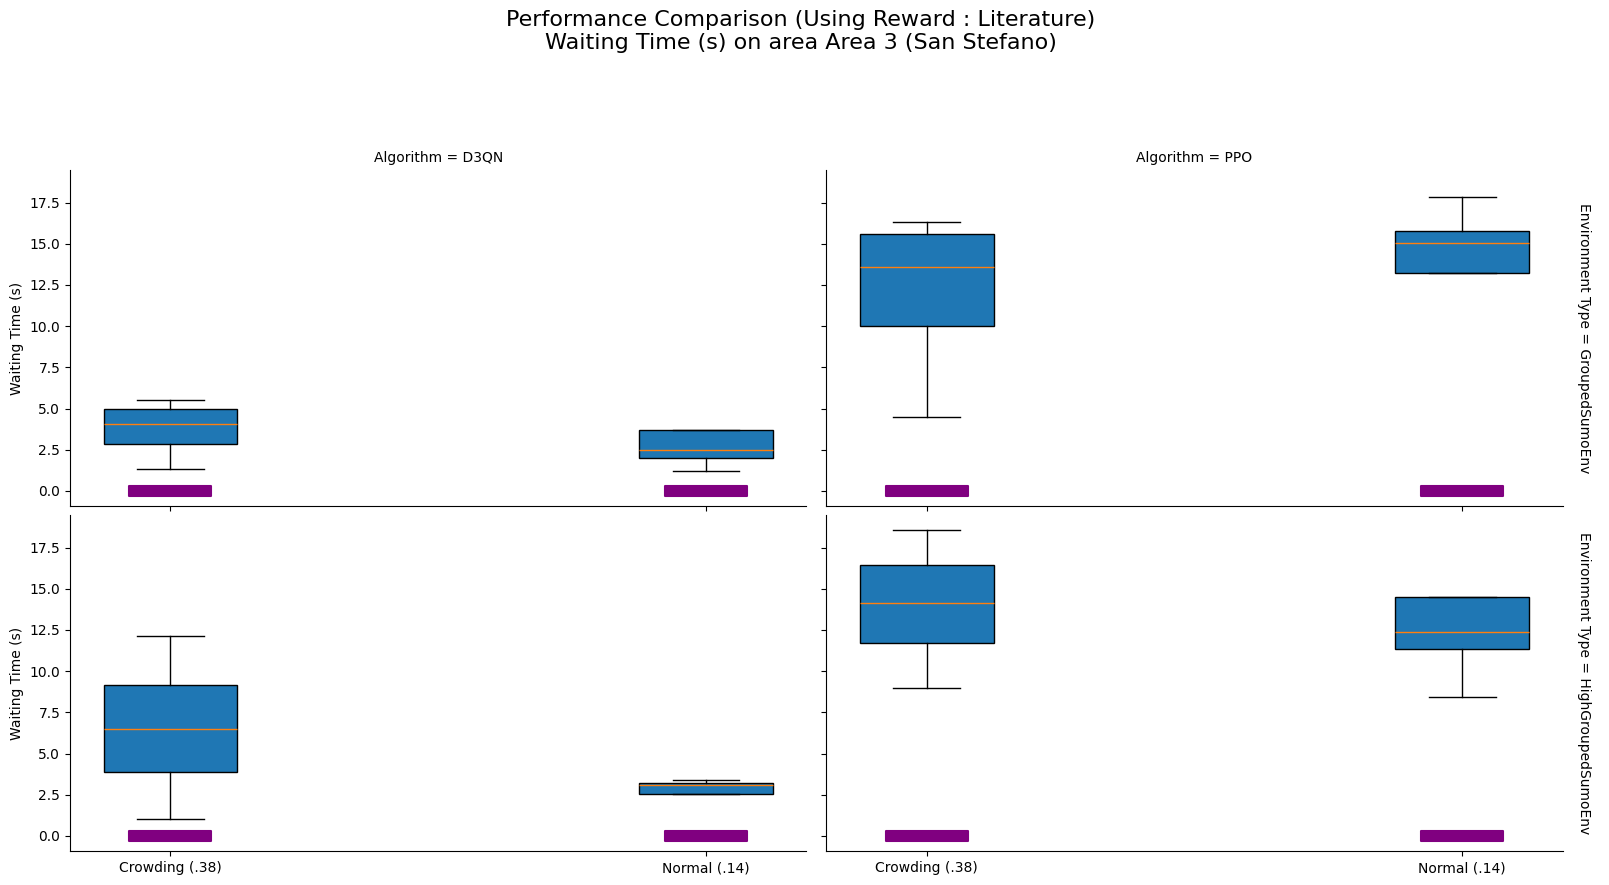

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


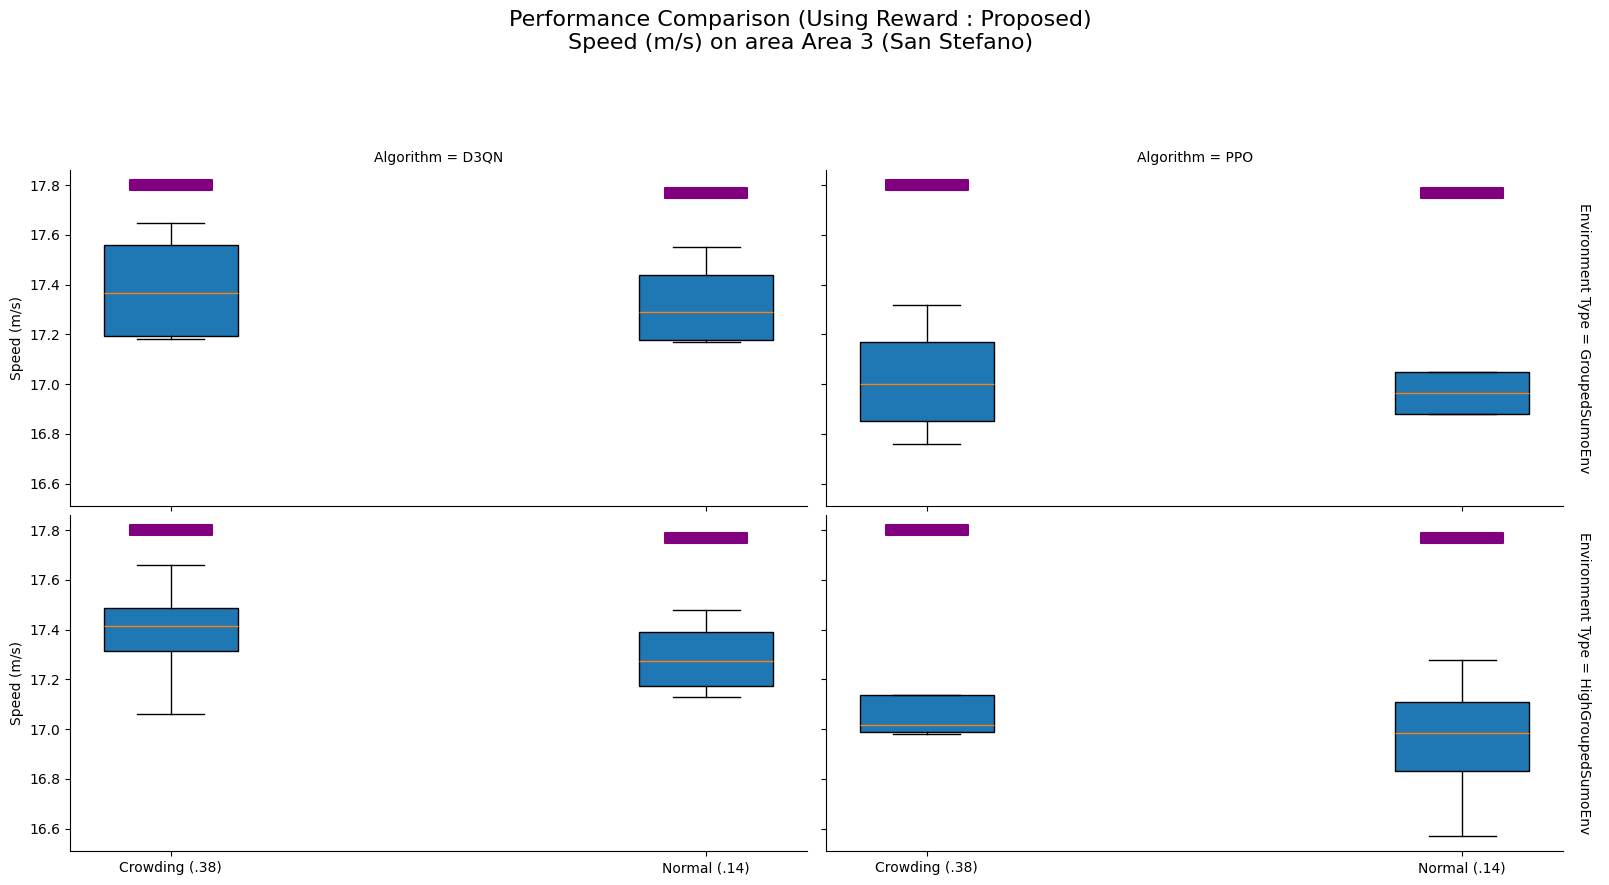

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


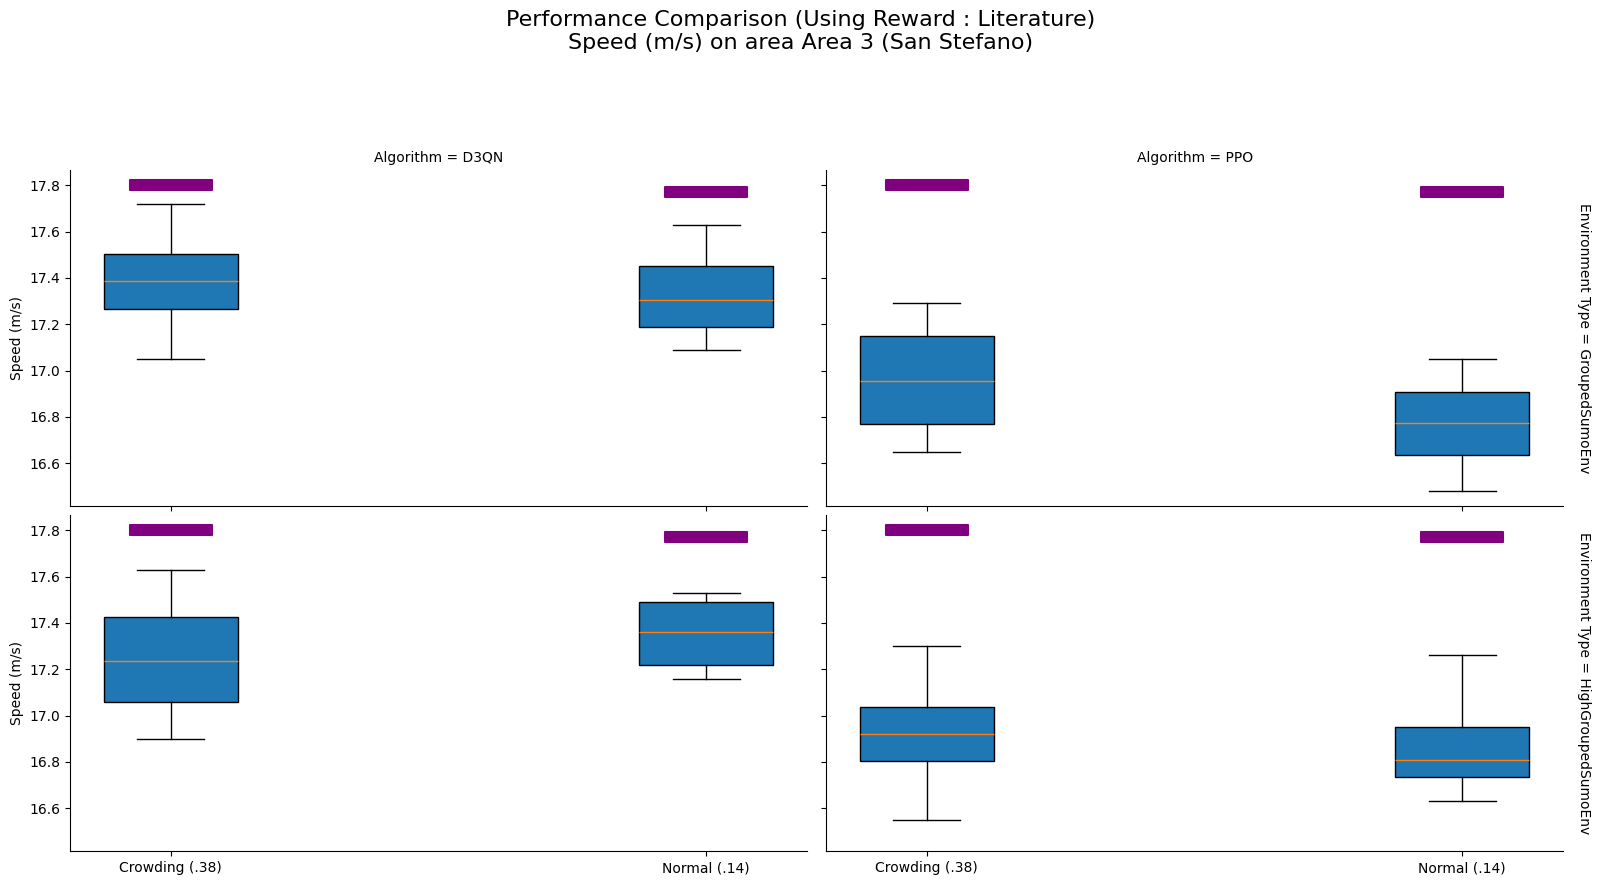

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


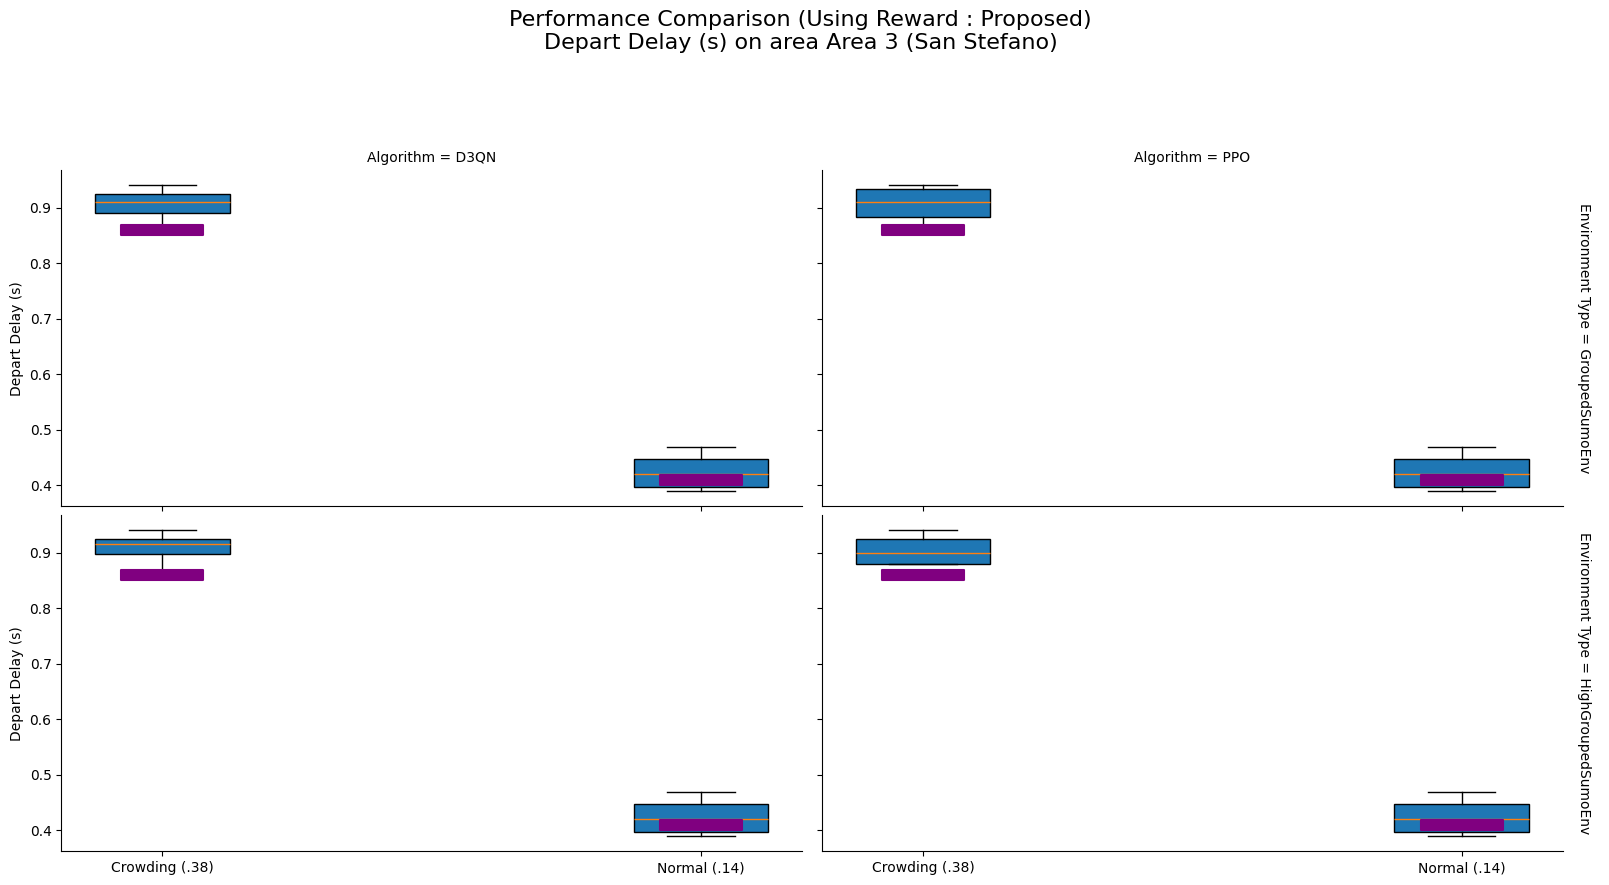

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


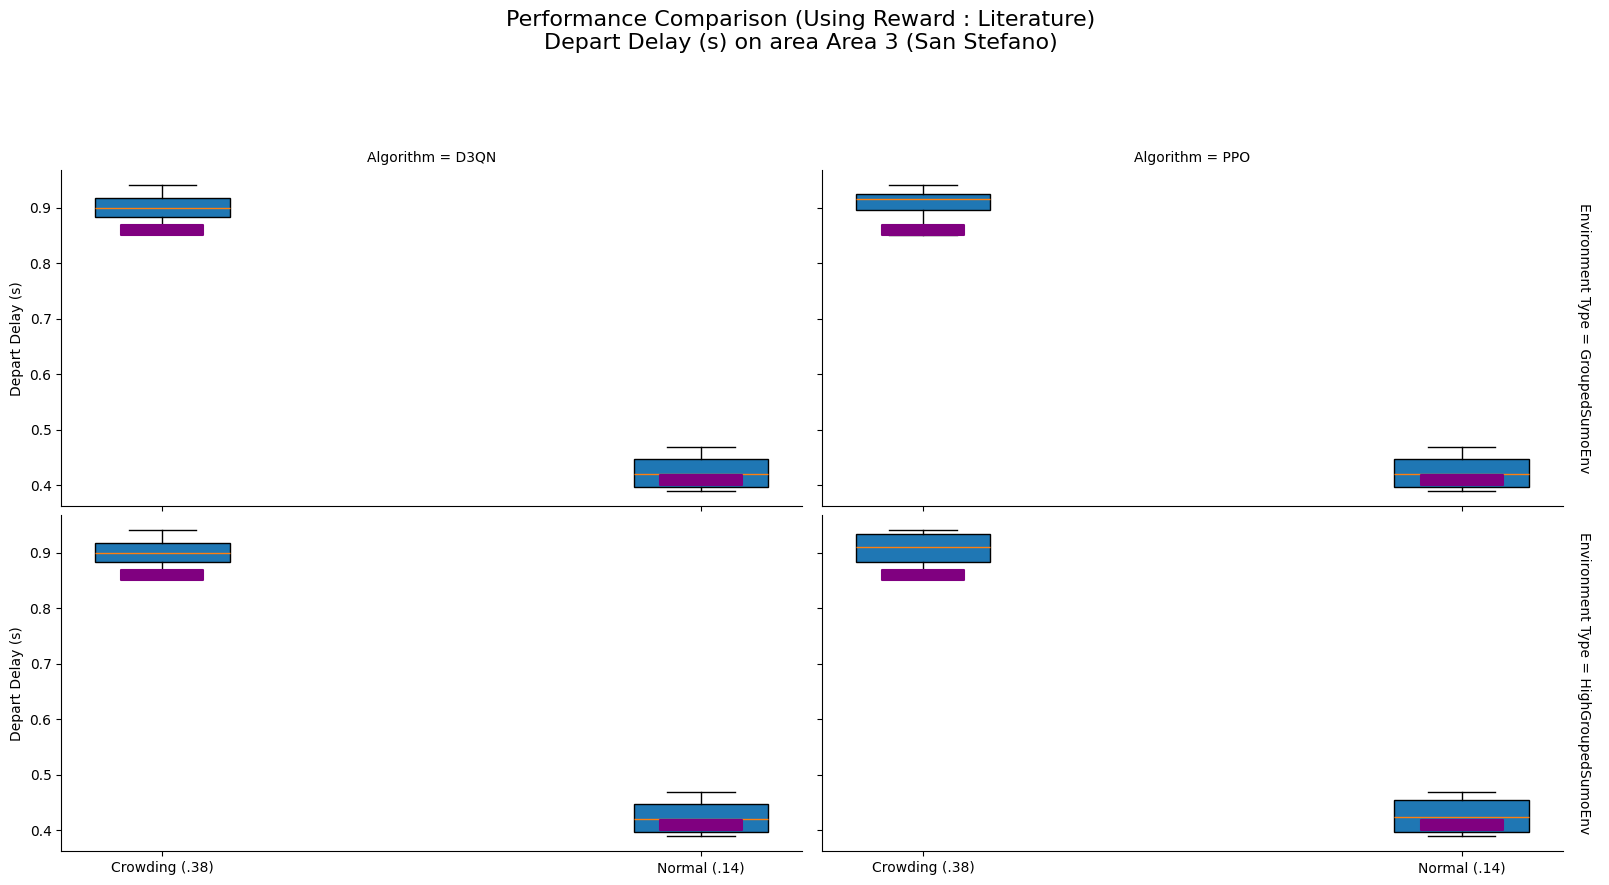

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


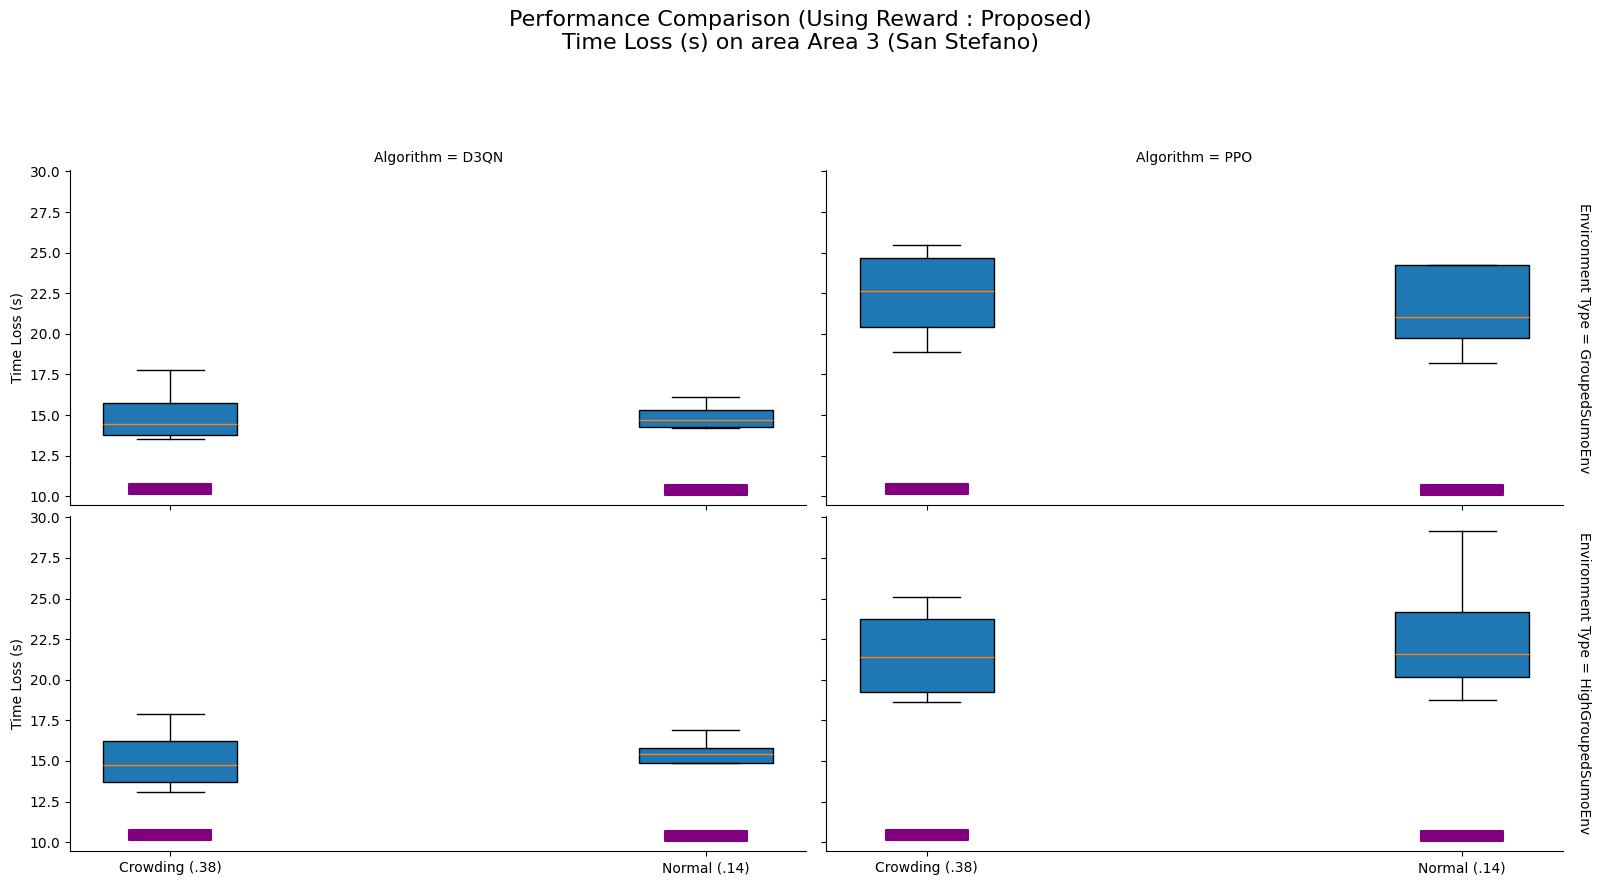

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


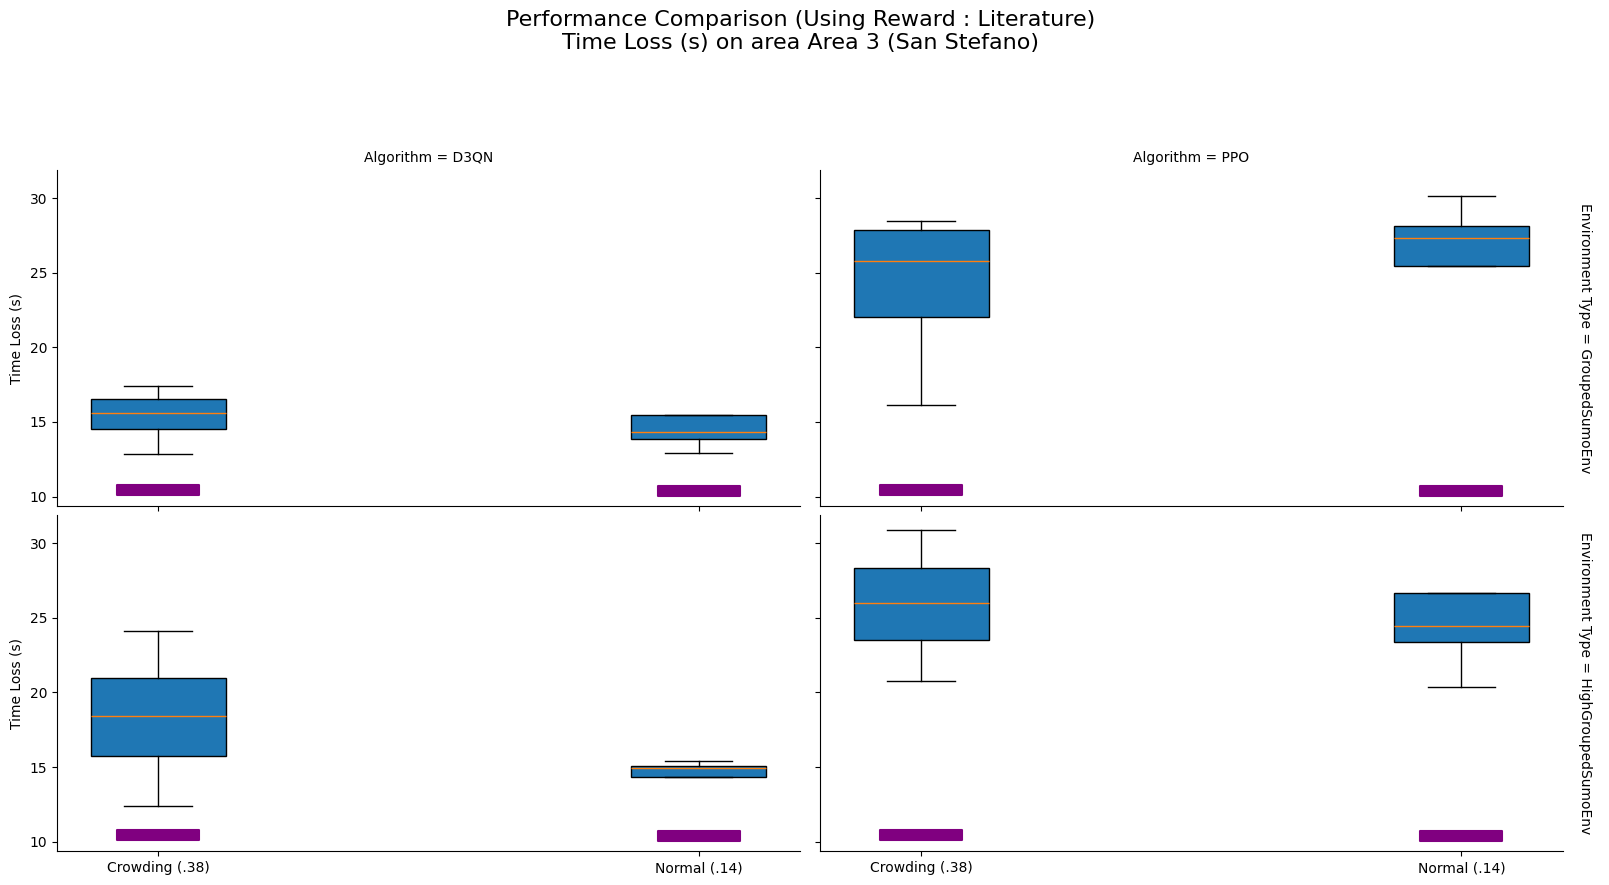

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


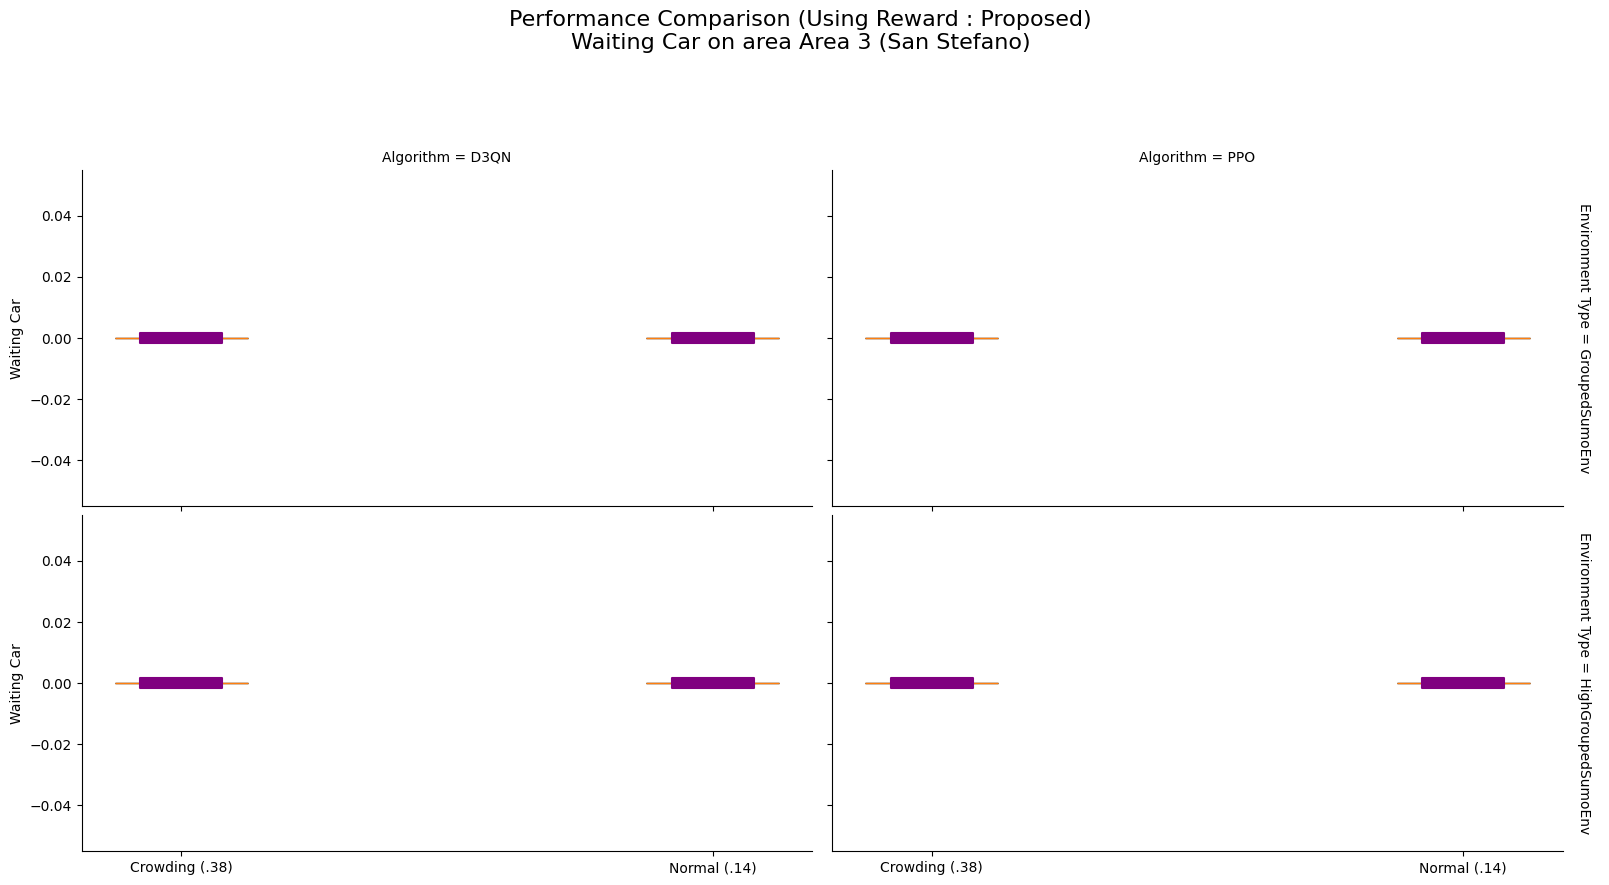

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


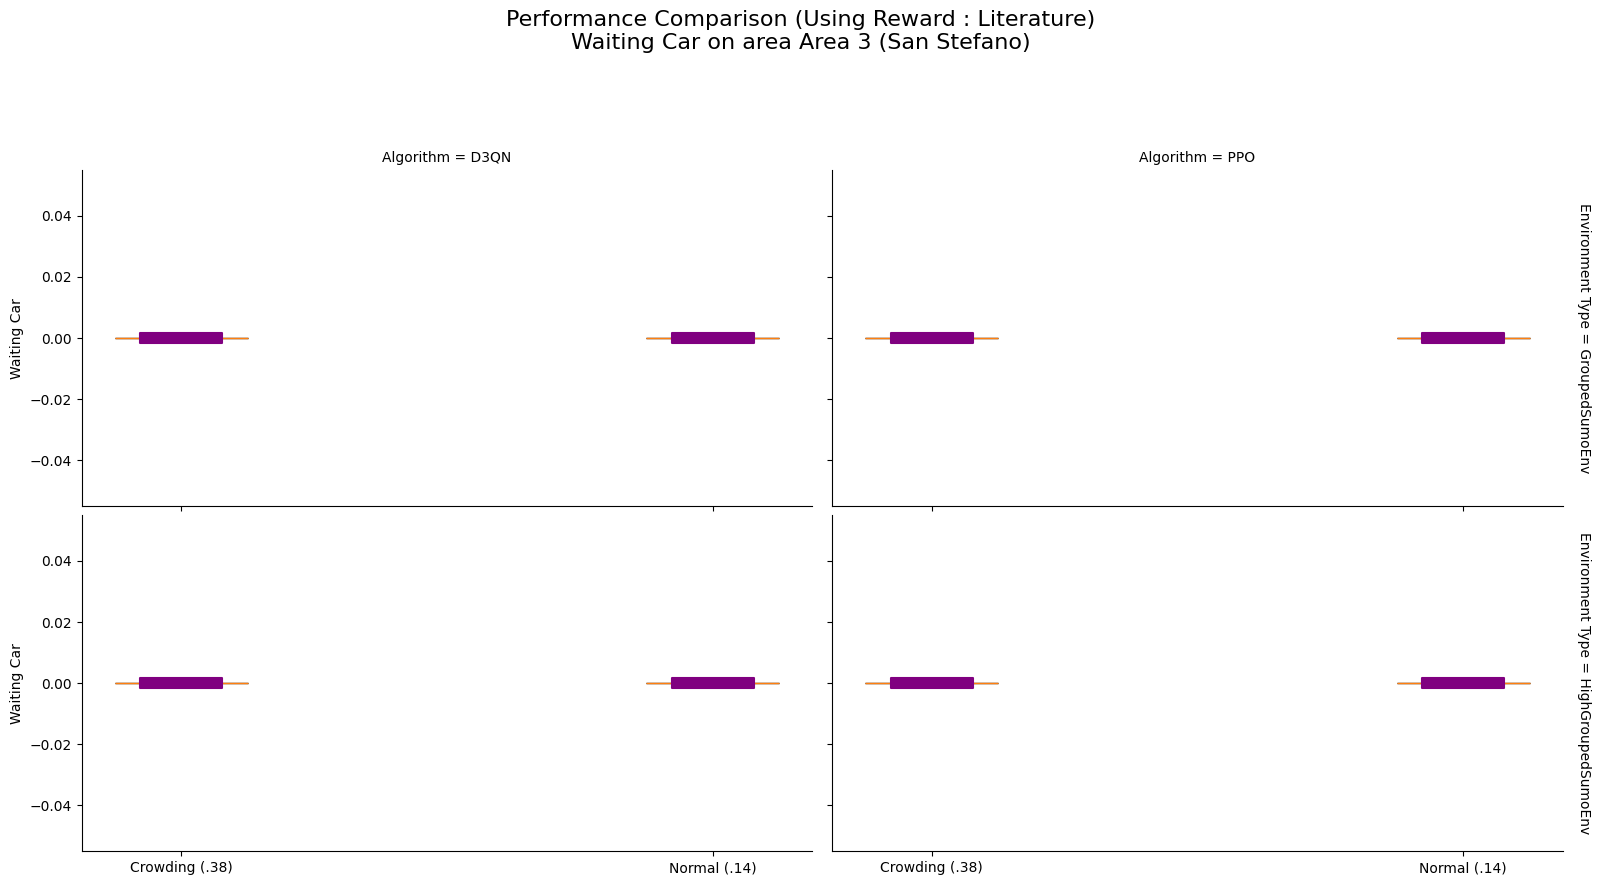

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


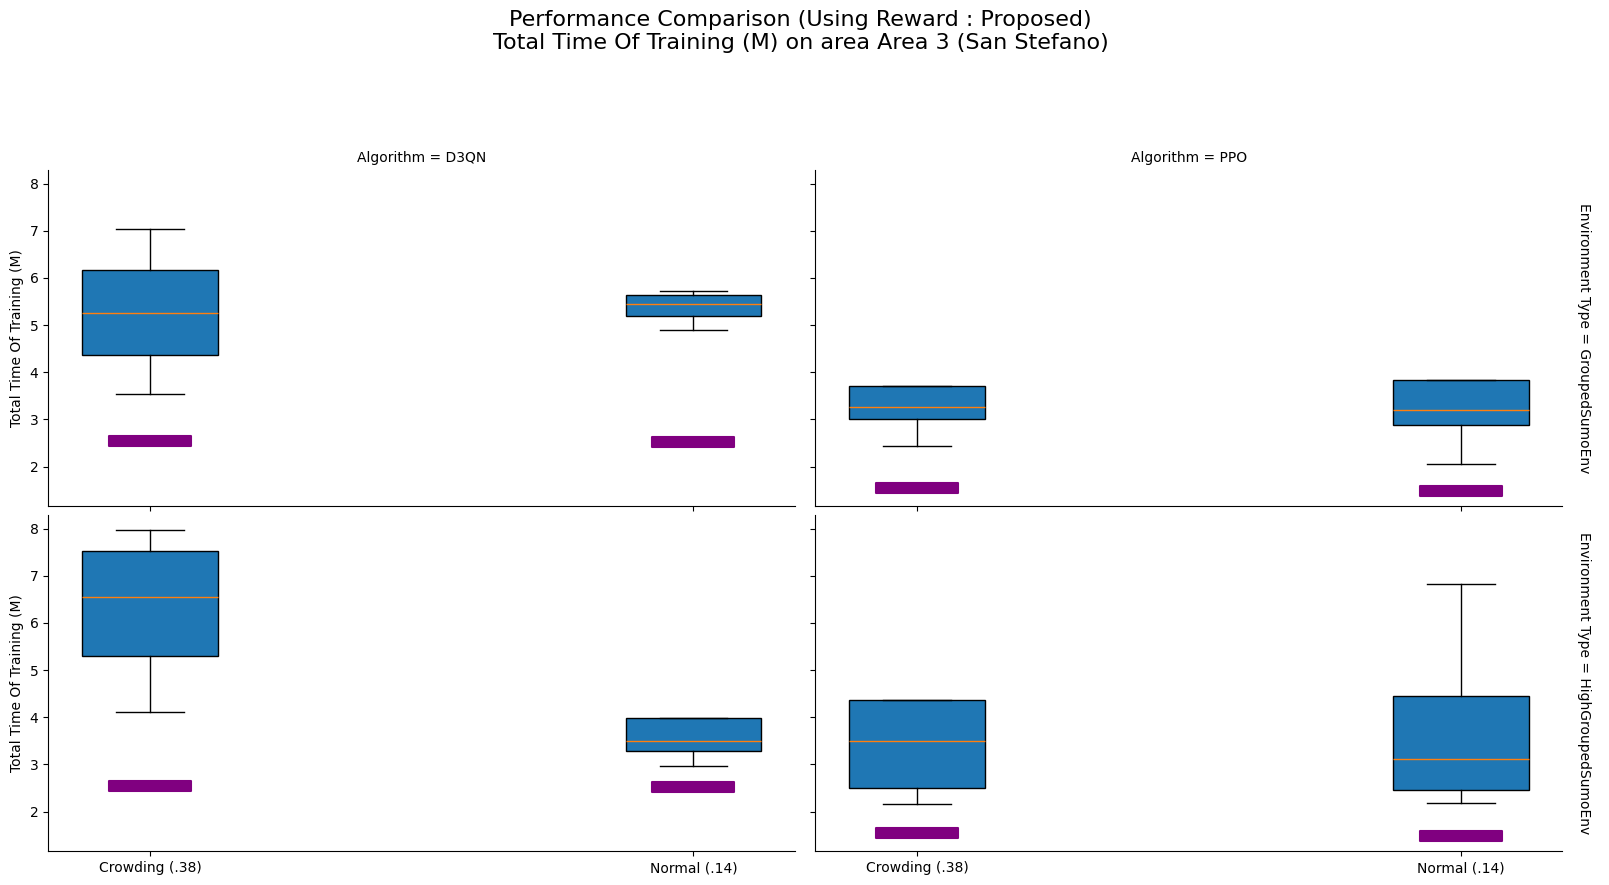

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


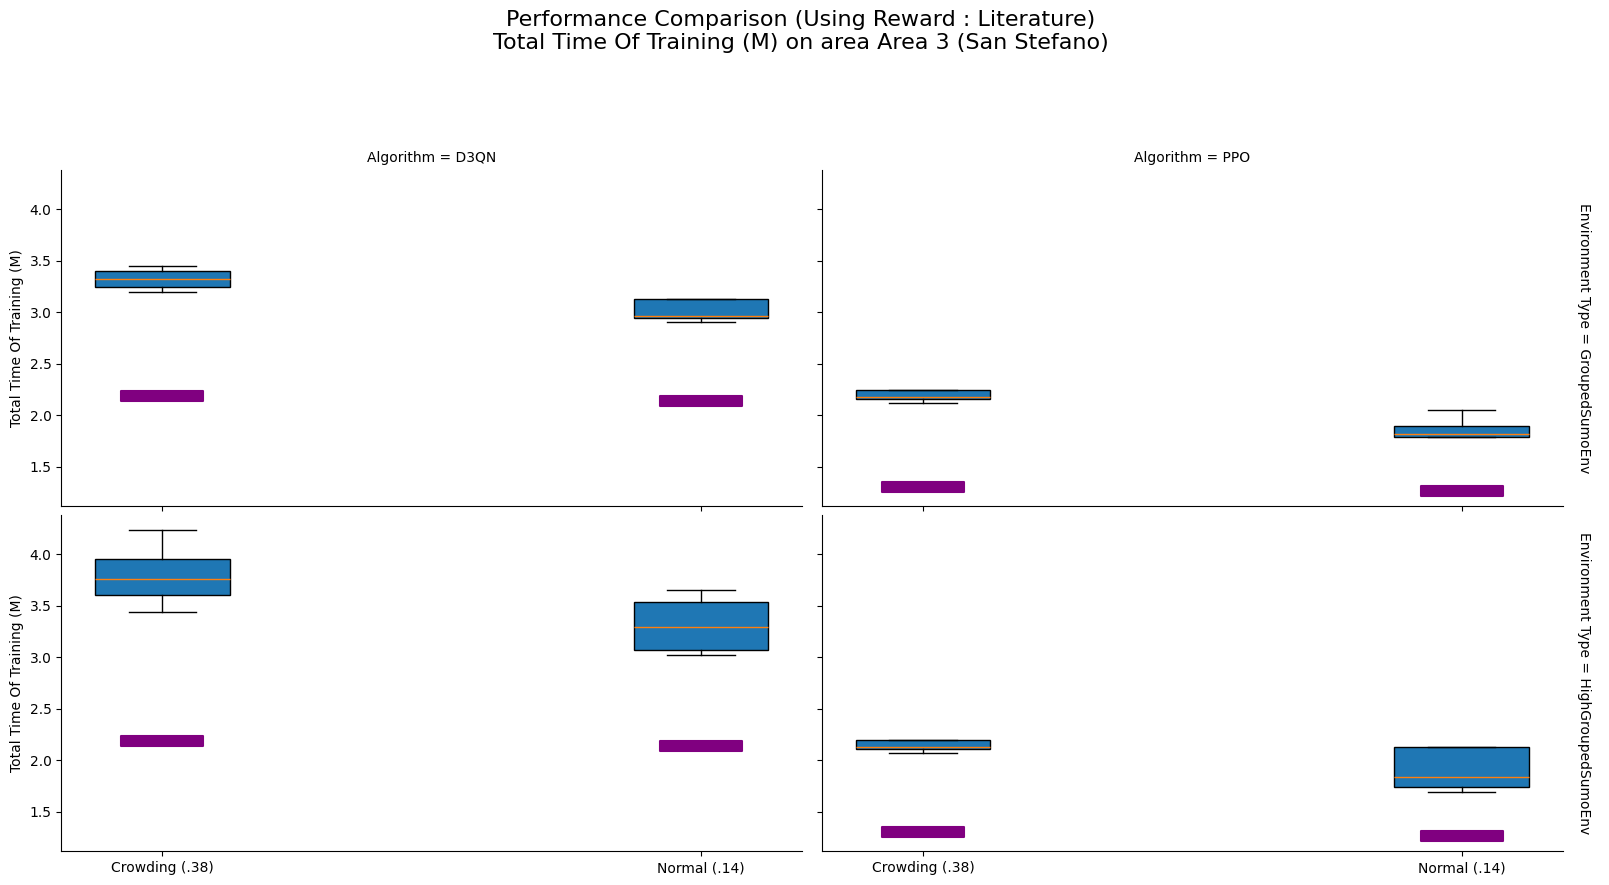

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


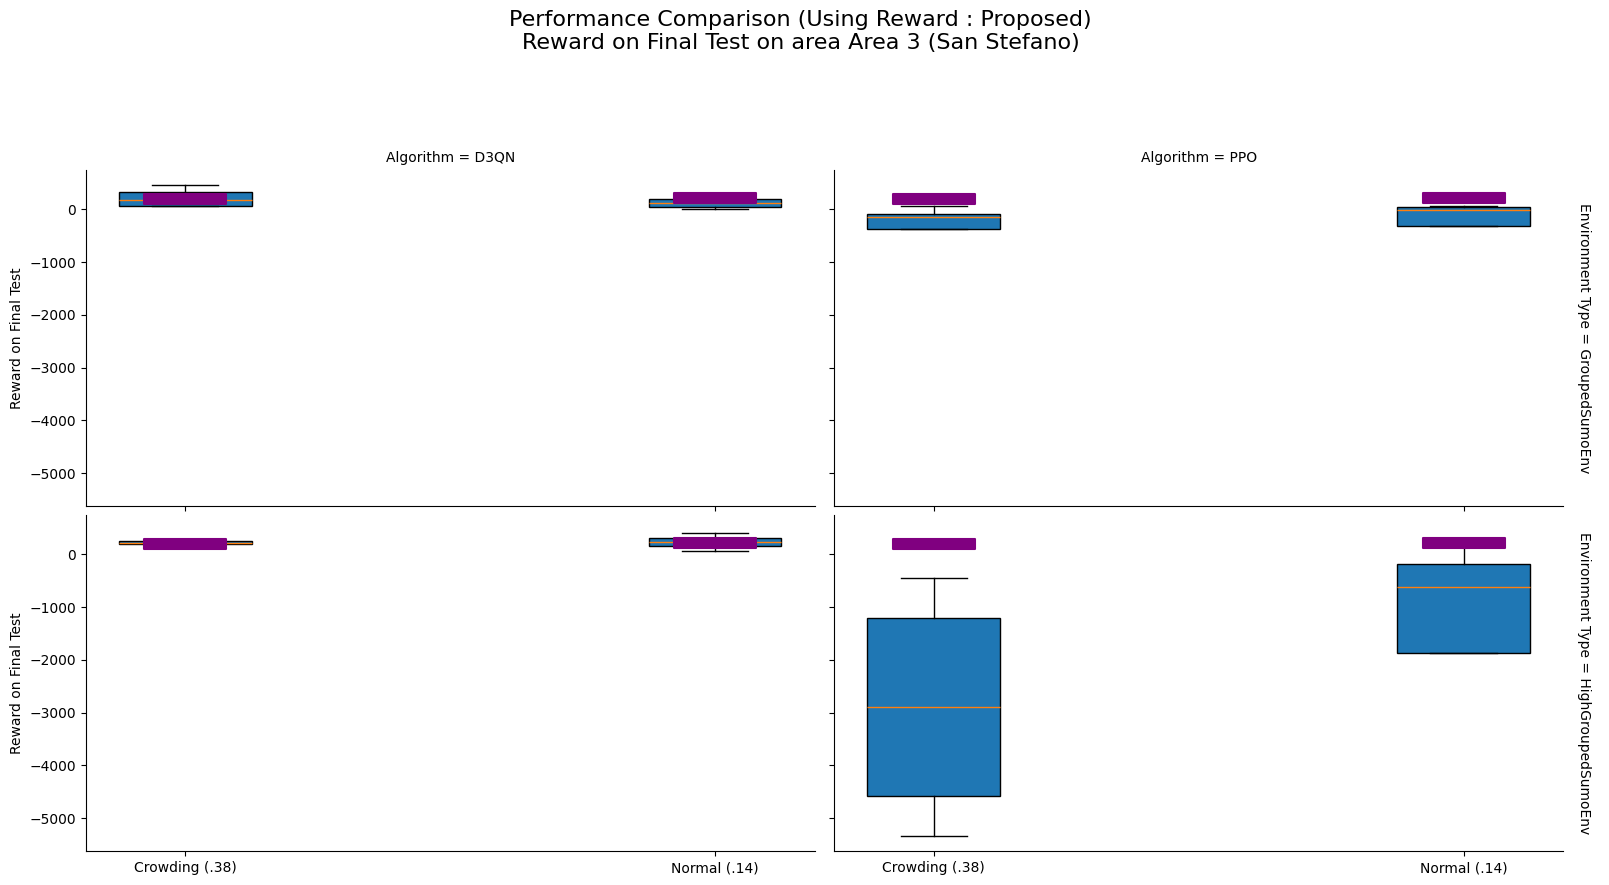

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


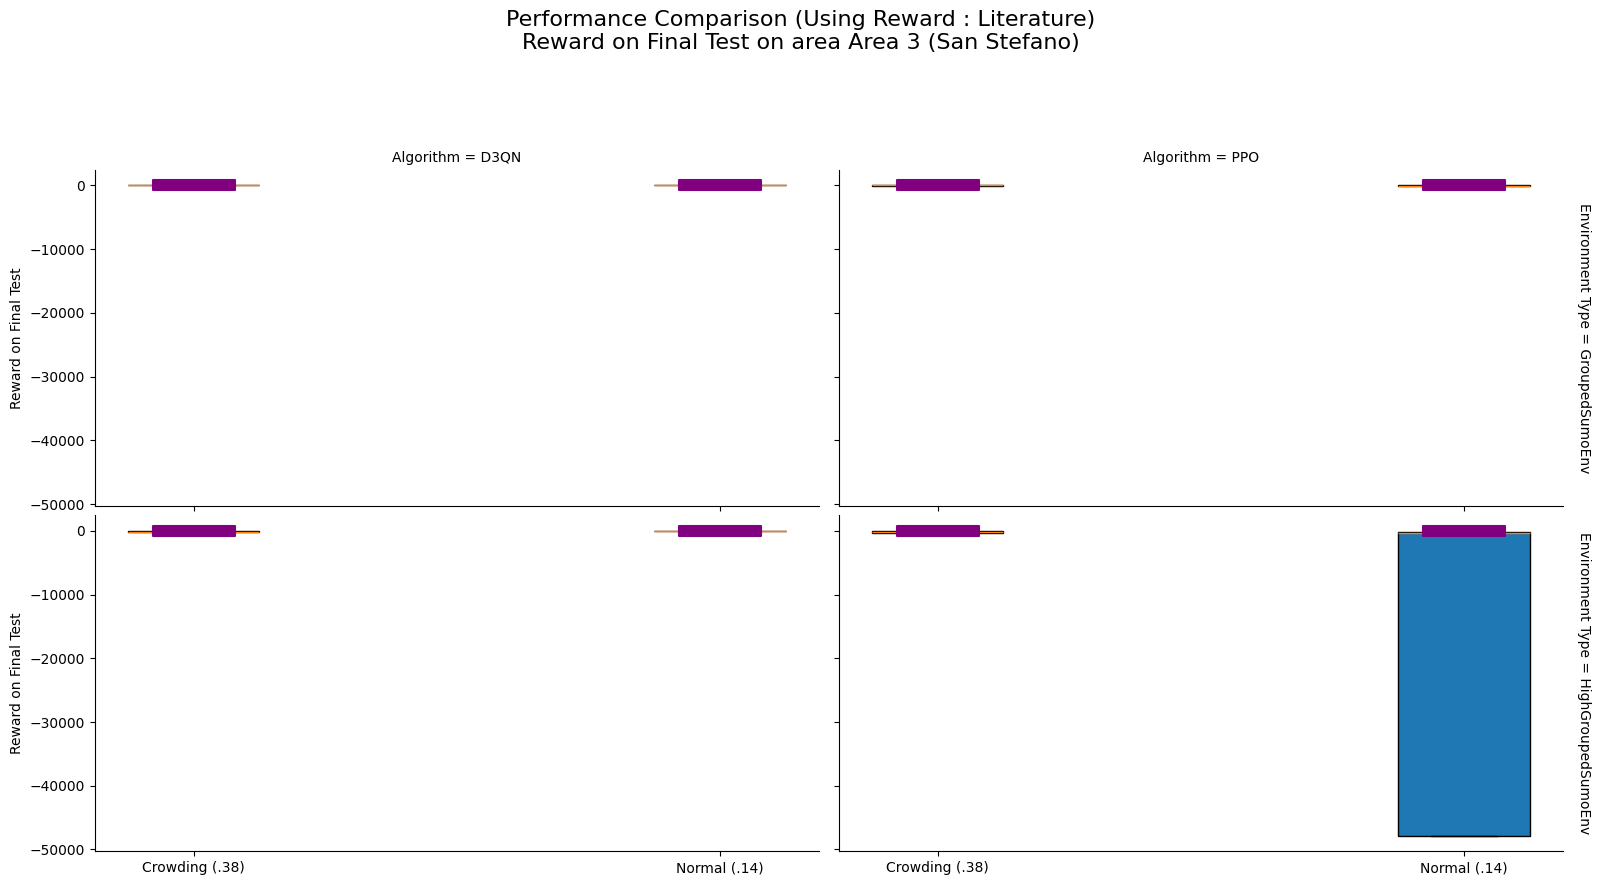

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


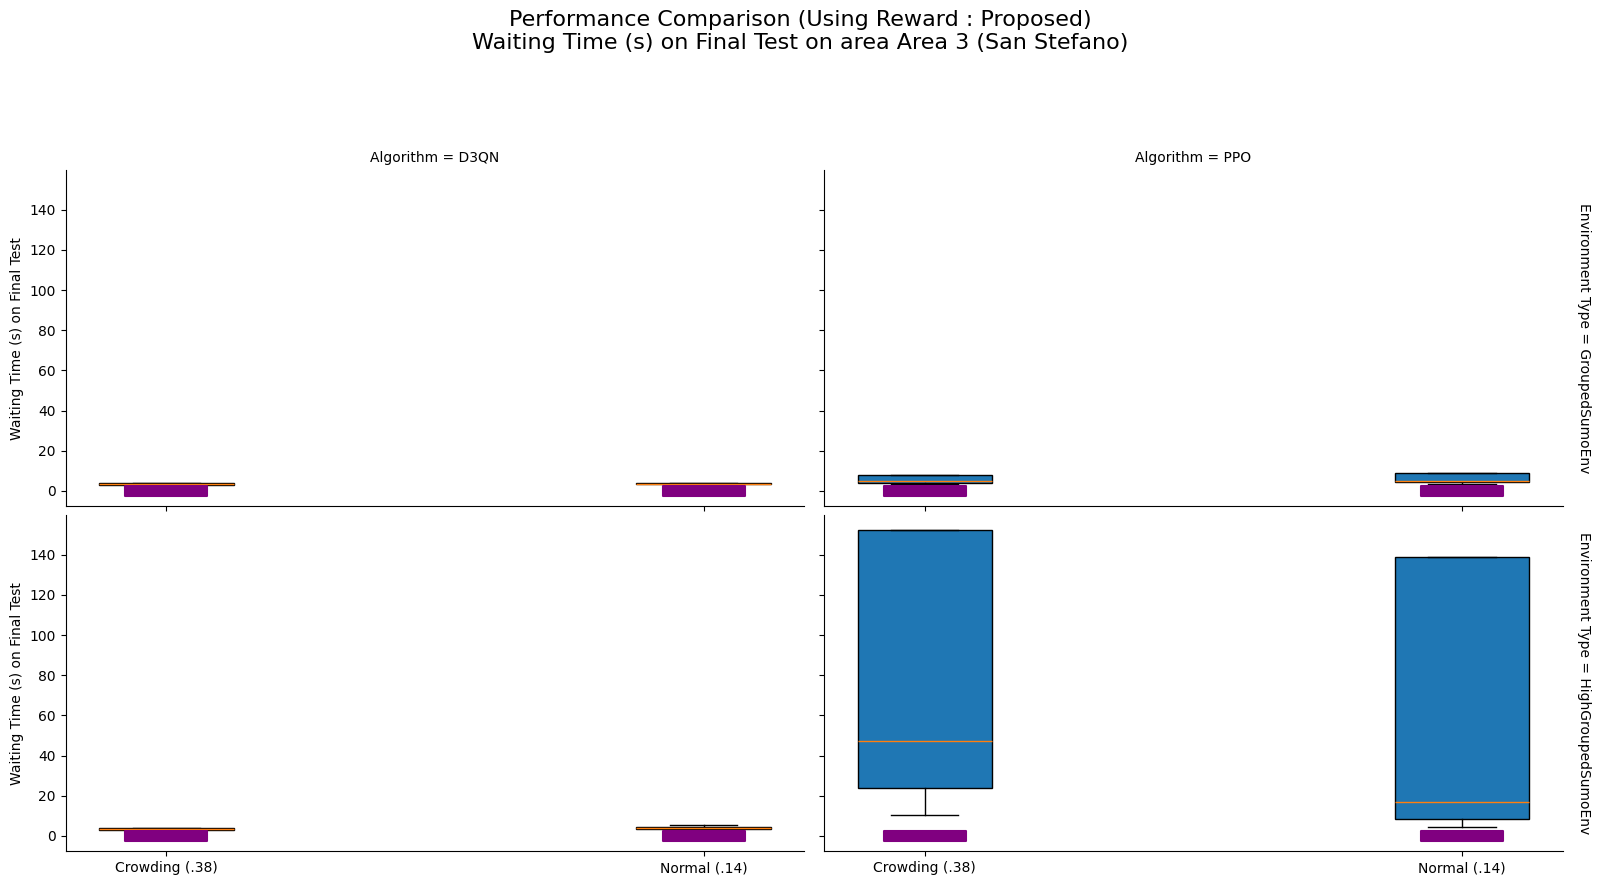

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


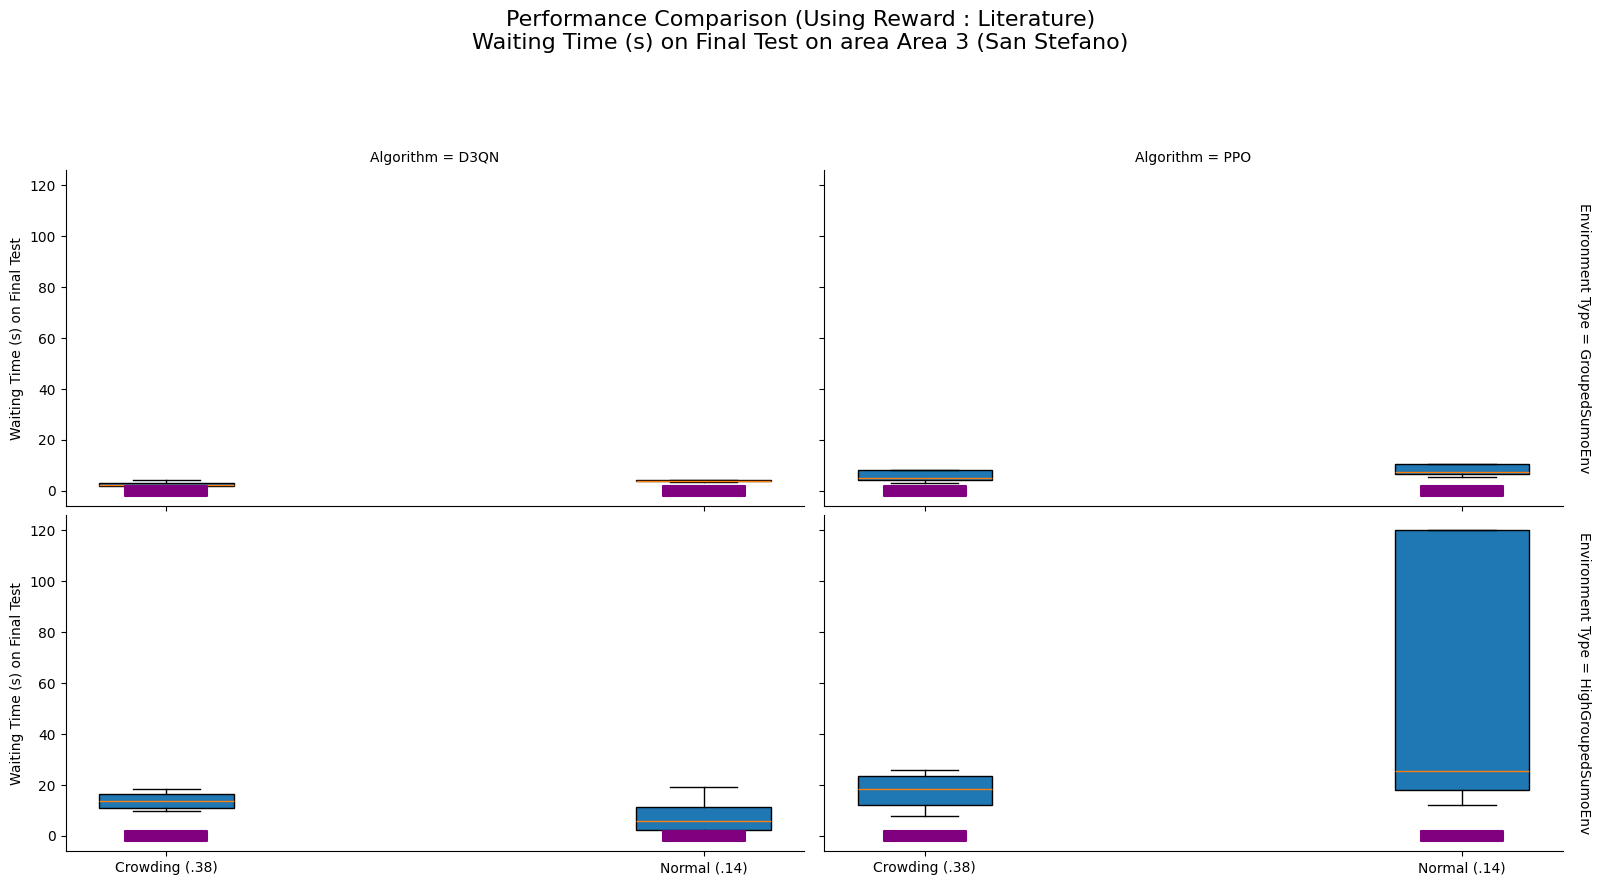

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


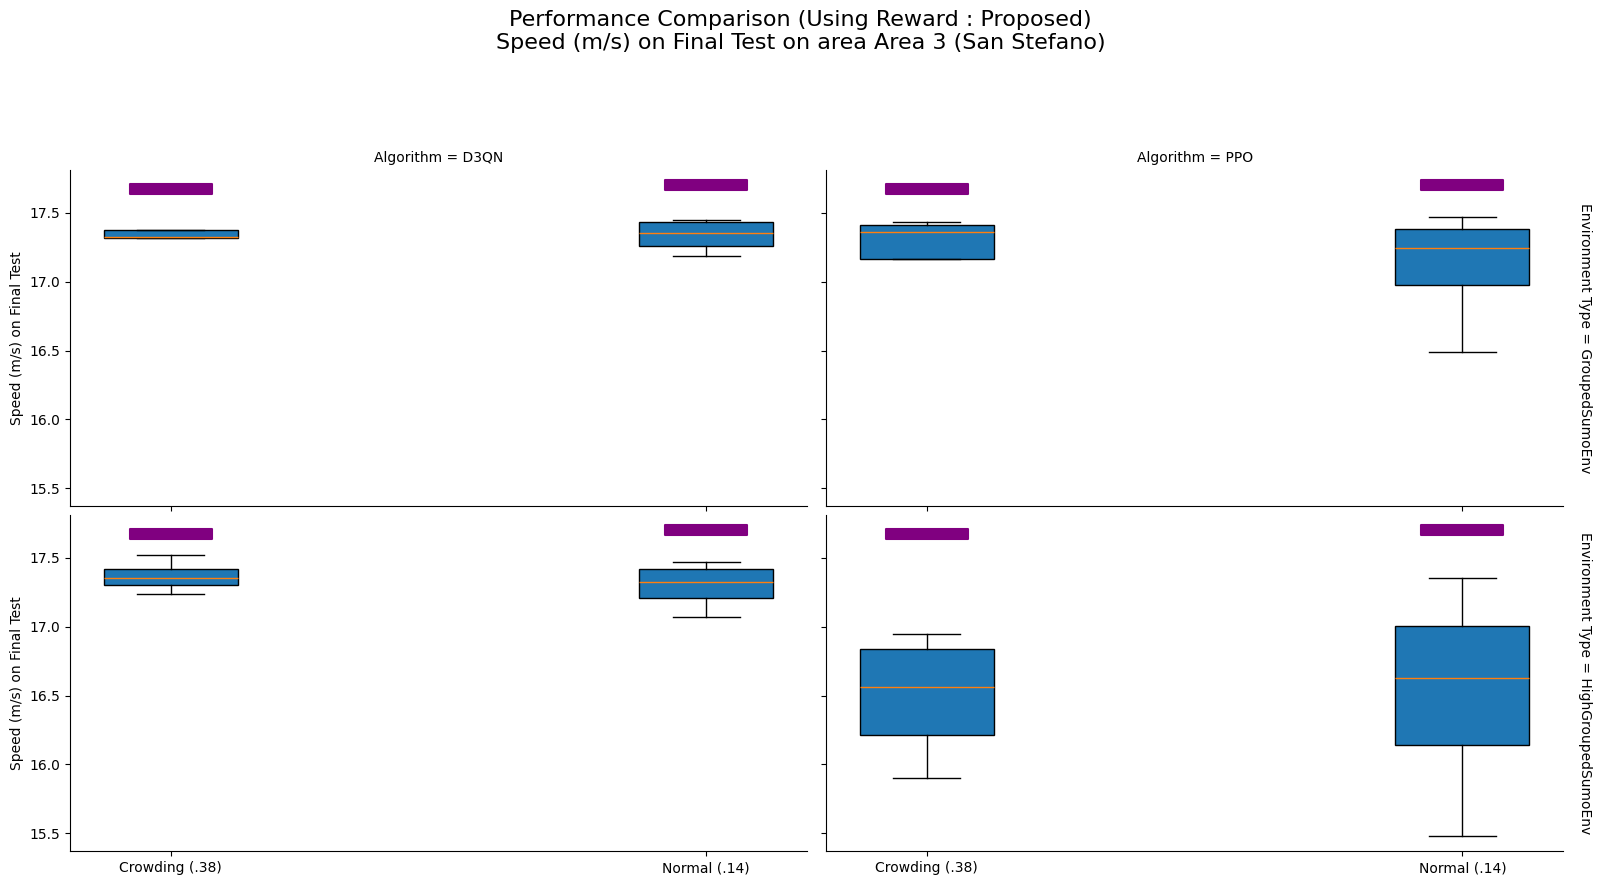

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


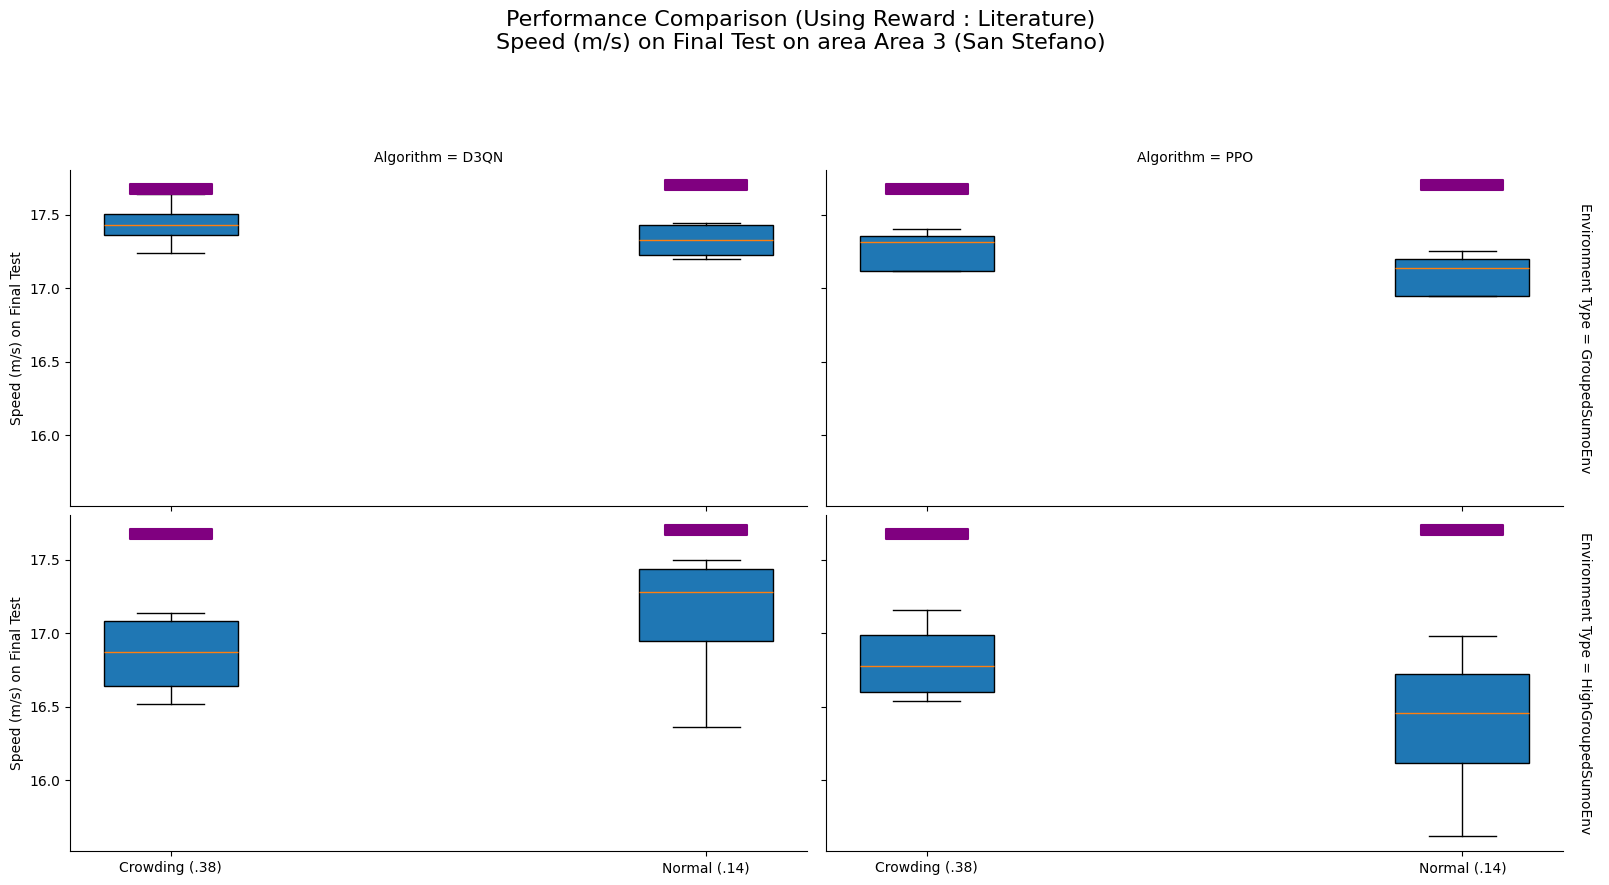

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


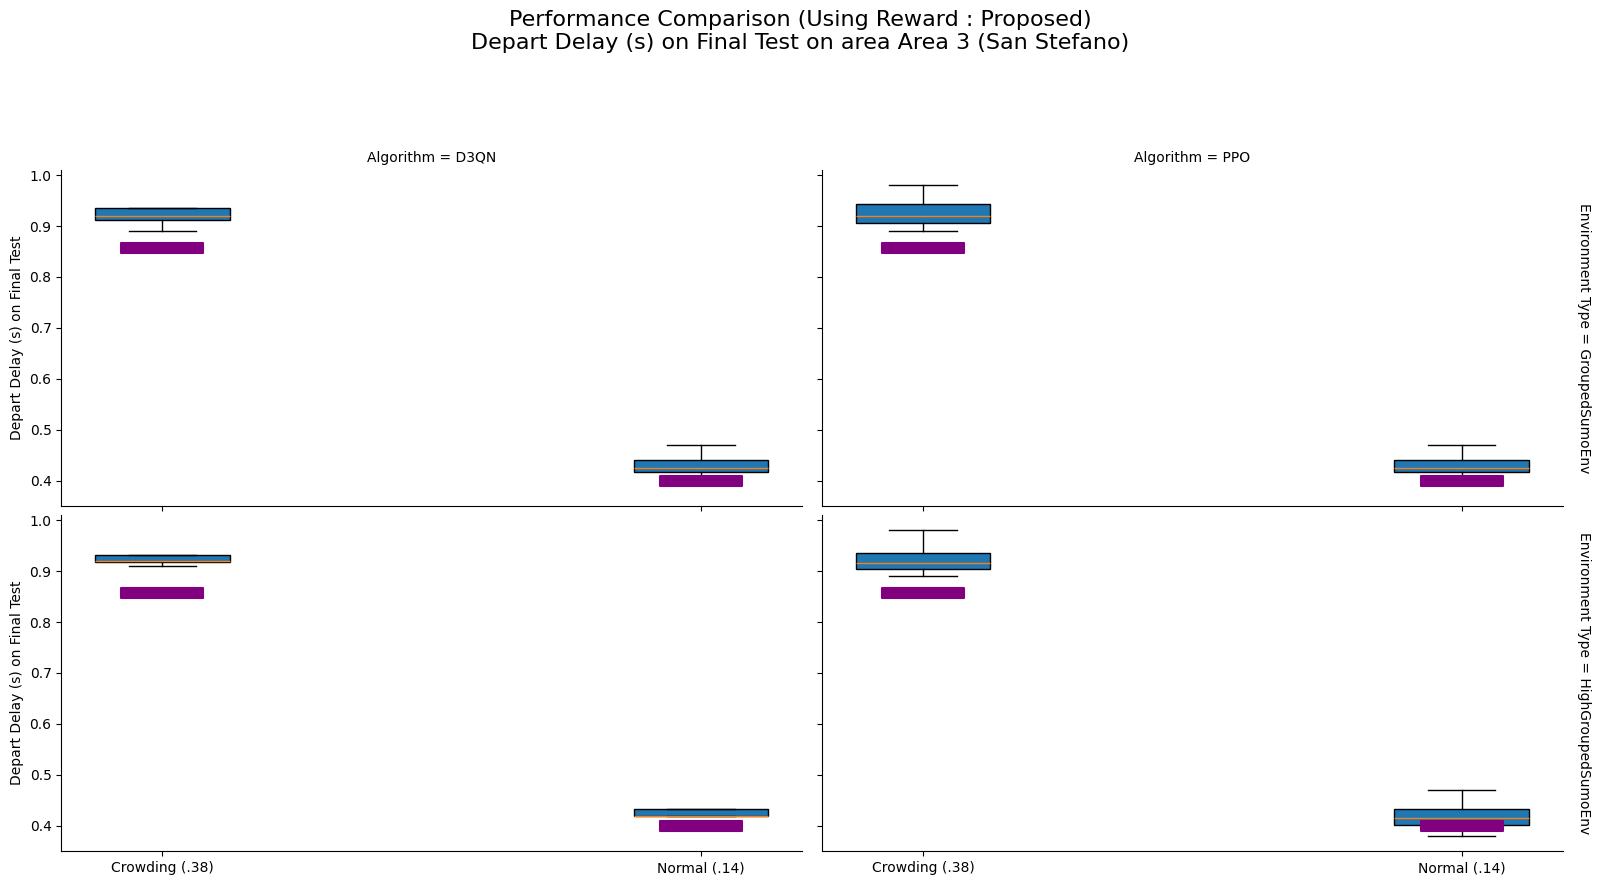

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


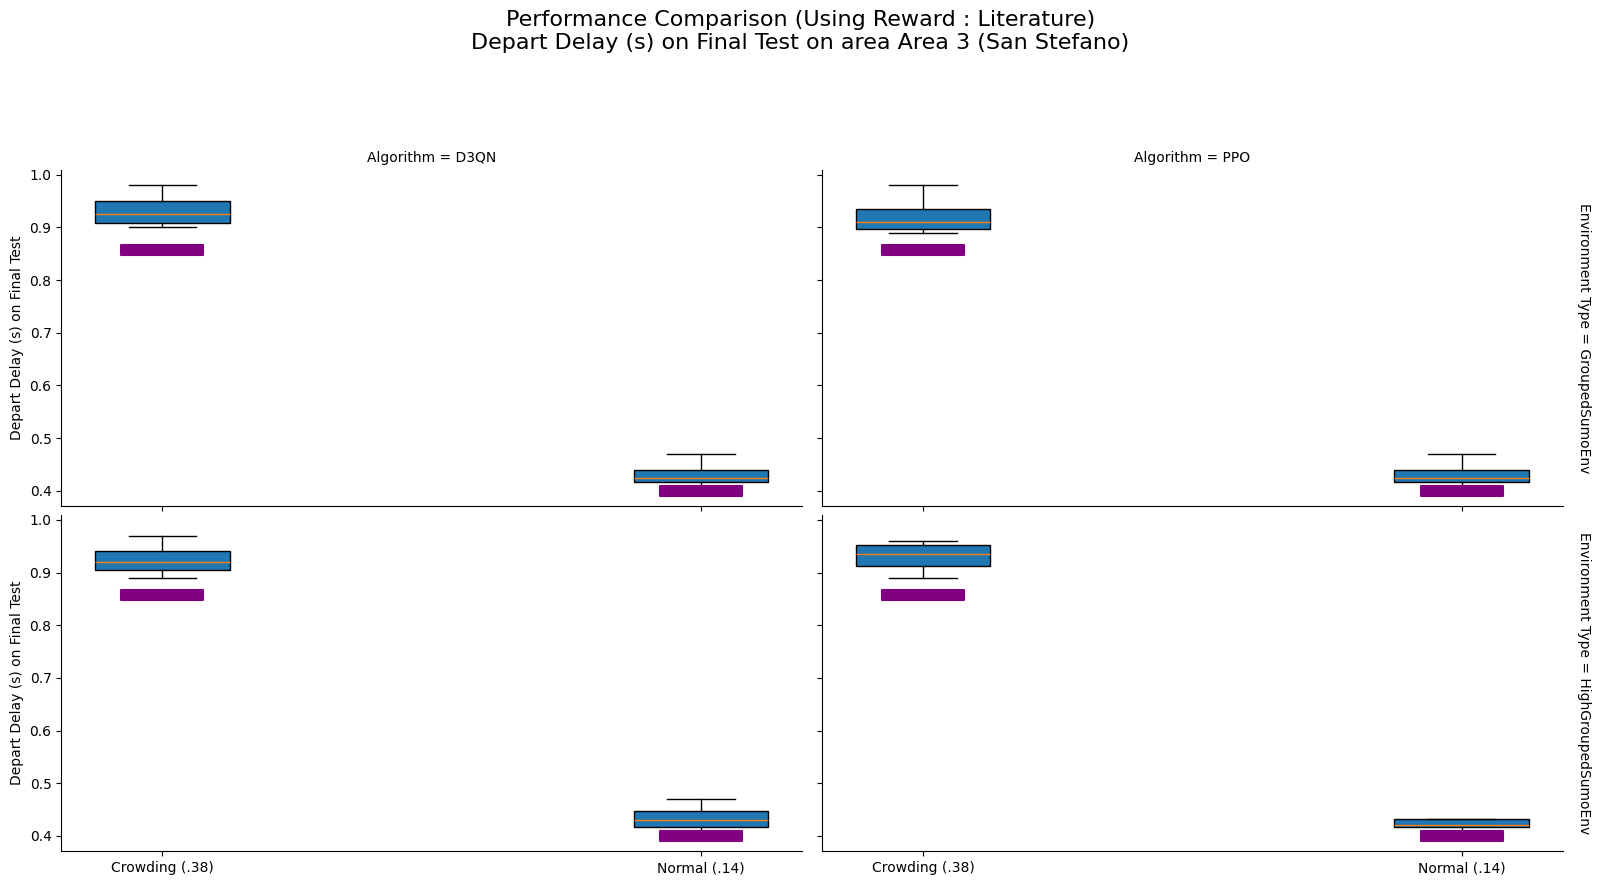

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


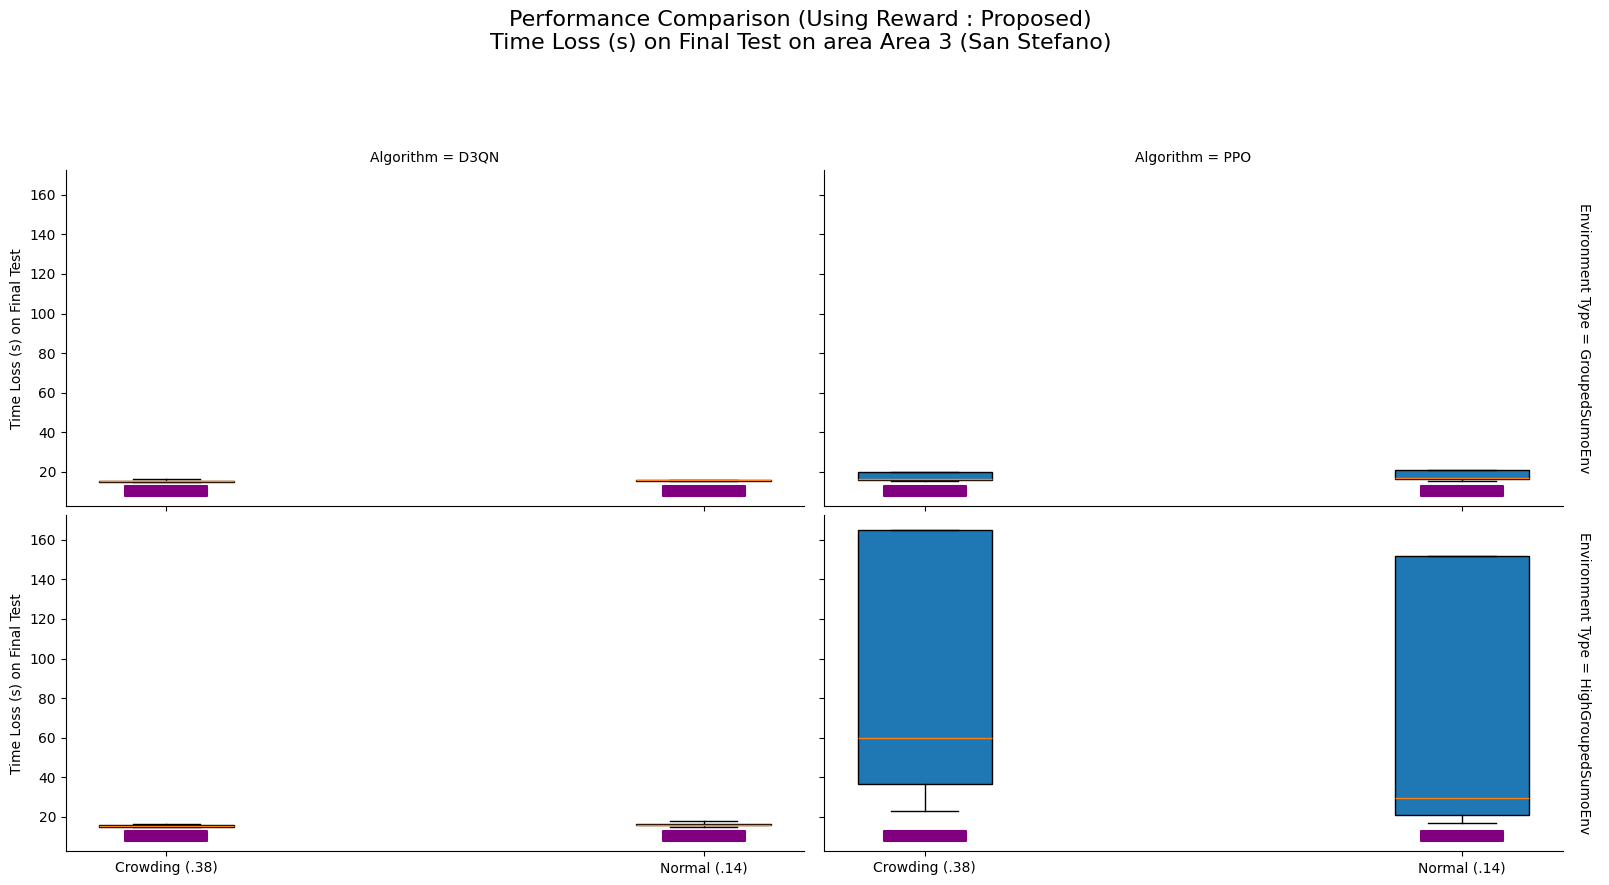

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


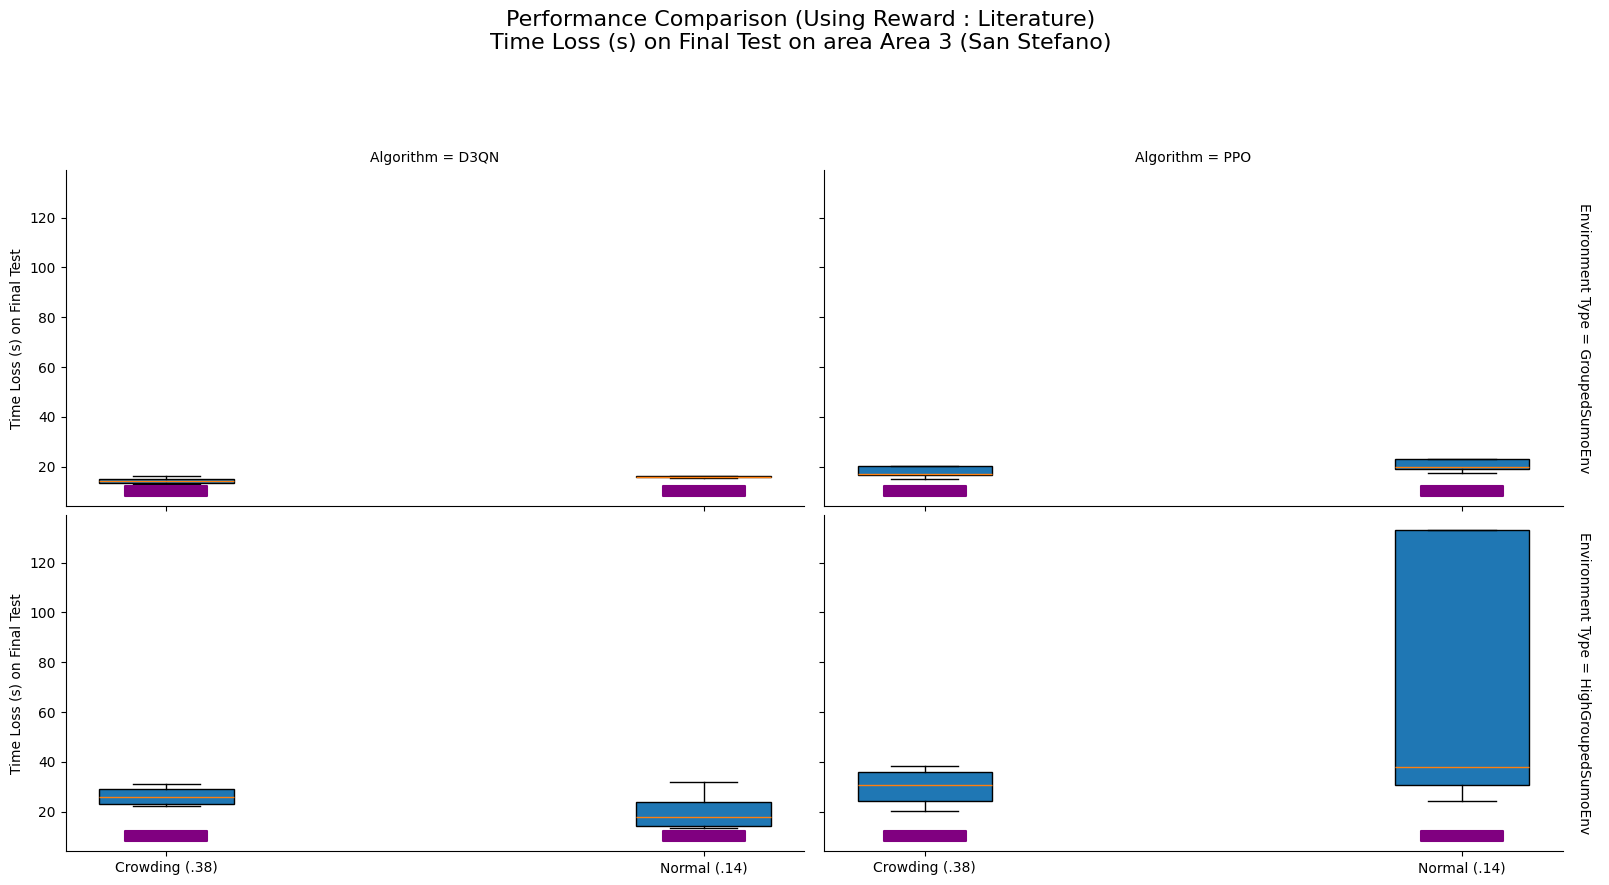

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


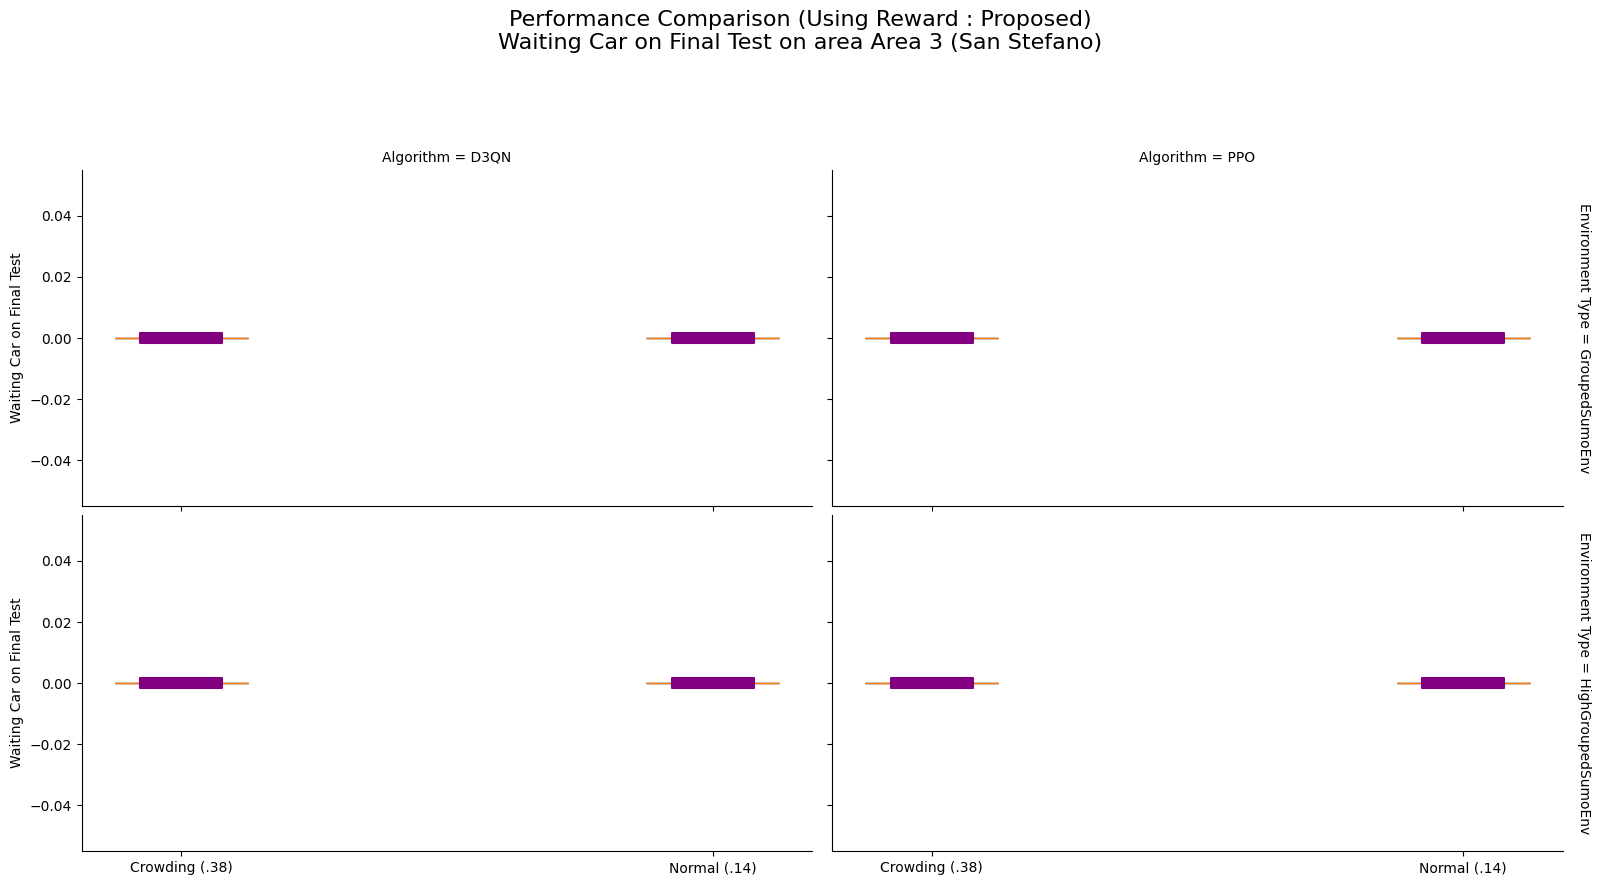

C:\Users\LapStore\AppData\Local\Temp\ipykernel_15724\730290653.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_exp_filtered = data_exp[data_exp['Reward'] == reward][data_exp['Area'] == area]


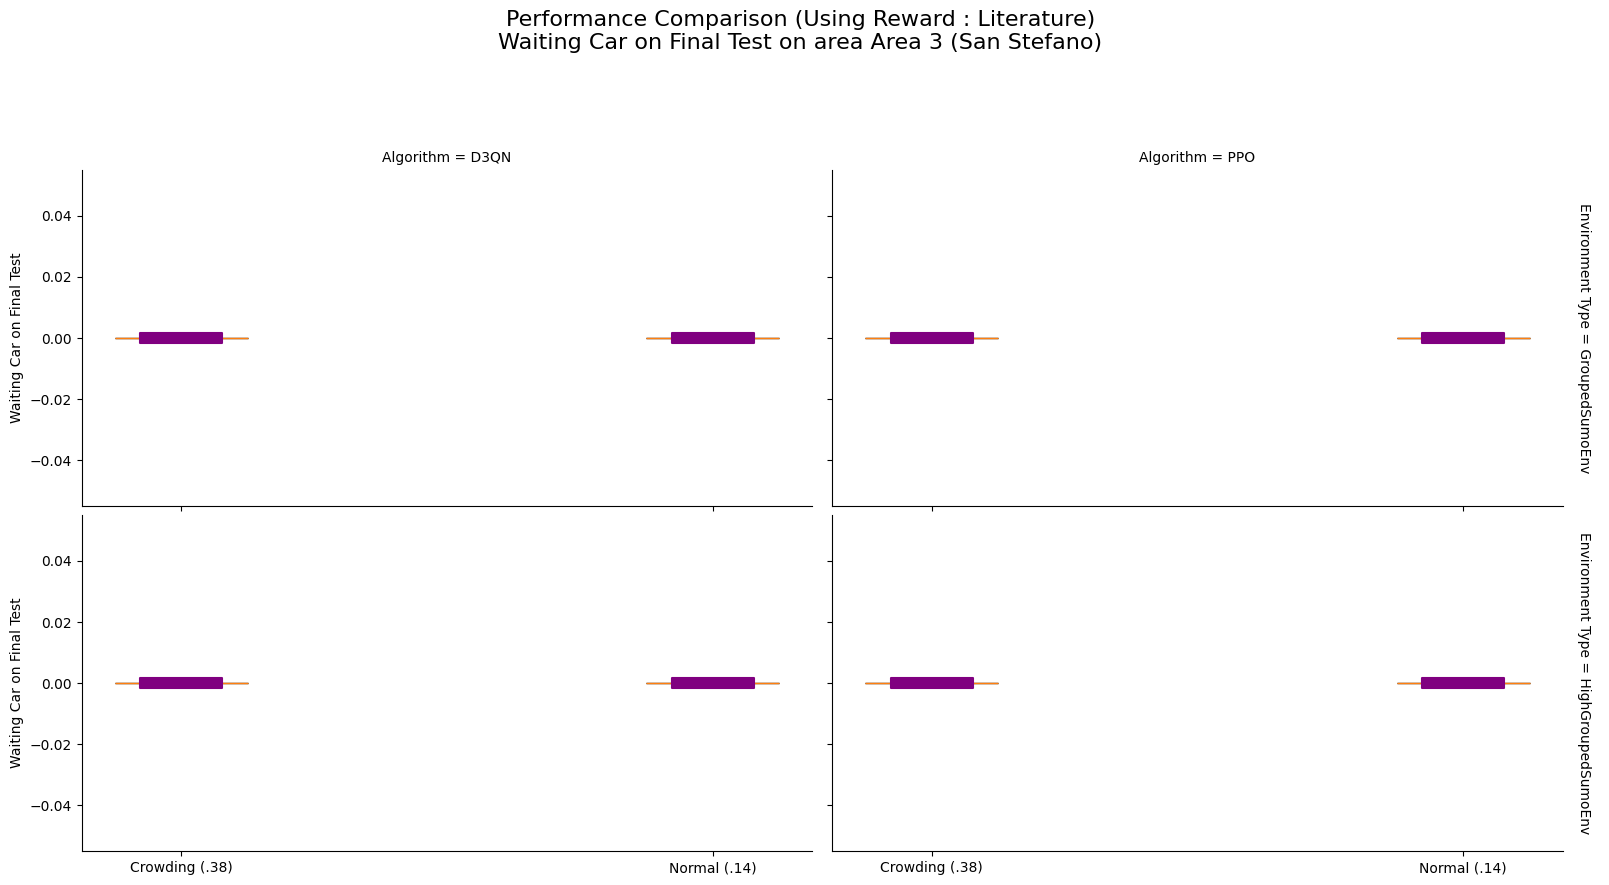

In [10]:
for metric in ['Reward of Last Episode',
       'Average Reward for Evaluated Episodes With Same Time',
       'Derivative of Reward', 'Waiting Time (s)', 'Speed (m/s)',
       'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car',
       'Total Time Of Training (M)', 'Reward on Final Test',
       'Waiting Time (s) on Final Test', 'Speed (m/s) on Final Test',
       'Depart Delay (s) on Final Test', 'Time Loss (s) on Final Test',
       'Waiting Car on Final Test']:
    for reward_ in ['Proposed','Literature']:
         plot_with_benchmark(data_exp,data_bench_grouped,"Area 3 (San Stefano)",metric,reward= reward_)

## Anova

In [11]:
import pandas as pd
from scipy.stats import ttest_ind, f_oneway

def simple_stat_test(df, metric, group_col):
    groups = df[group_col].unique() ##note should each group have data length > 1
    data = [df[df[group_col] == g][metric] for g in groups]
    
    if len(groups) == 2:
        stat, p = ttest_ind(*data)
        #print(f"T-test between {groups[0]} and {groups[1]}: p = {p:.4f}")
        return p 
    elif len(groups) > 2:
        stat, p = f_oneway(*data)
        #print(f"ANOVA across groups in '{group_col}': p = {p:.4f}")
        return p
    else:
        
        #print("Not enough groups to test.")
        return -1
    return -1
#tukey = pairwise_tukeyhsd(endog=df["Reward"], groups=df["Algorithm"], alpha=0.05)



In [12]:
alpha = .03

In [13]:
from tabulate import tabulate
from colorama import Fore, Style

headers = ["Area", "Reward", "Traffic Scale", "Algorithm", 'Reward of Last Episode','Waiting Time (s)','Speed (m/s)', 'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car']
table_data = []

data_exp= data_exp[data_exp["Area"]!="Bench(2waySingle)"]

for Algorithm in set(data_exp['Algorithm'].values):
    for scale in set(data_exp['Traffic Scale'].values):
        for Reward in set(data_exp['Reward'].values):
            for Area in set(data_exp['Area'].values):
                analysis_mask = (
                    (data_exp['Area'] == Area) &
                    (data_exp['Reward'] == Reward) &
                    (data_exp['Traffic Scale'] ==scale) &
                    (data_exp['Algorithm'] == Algorithm) 
                )

                data_i_exp = data_exp[analysis_mask]
            

                reward_test = simple_stat_test(data_i_exp, "Average Reward for Evaluated Episodes With Same Time","Environment Type") 
                reward_color = Fore.RED if reward_test < alpha else Fore.GREEN

                waiting_test = simple_stat_test(data_i_exp, "Waiting Time (s)","Environment Type") 
                waiting_color = Fore.RED if waiting_test<alpha else Fore.GREEN

                spd_test = simple_stat_test(data_i_exp, 'Speed (m/s)',"Environment Type") 
                spd_color = Fore.RED if spd_test<alpha else Fore.GREEN

                depart_test = simple_stat_test(data_i_exp,'Depart Delay (s)',"Environment Type") 
                depart_color = Fore.RED if depart_test < alpha else Fore.GREEN

                Tloss_test = simple_stat_test(data_i_exp,'Time Loss (s)',"Environment Type") 
                Tloss_color = Fore.RED if Tloss_test < alpha else Fore.GREEN

                carWait_test = simple_stat_test(data_i_exp, 'Waiting Car',"Environment Type") 
                carWait_color = Fore.RED if carWait_test < alpha else Fore.GREEN

                table_data.append([
                        f"{Fore.CYAN} {Area} {Style.RESET_ALL}",
                        f"{Fore.CYAN} {Reward} {Style.RESET_ALL}",
                        f"{Fore.CYAN} {scale} {Style.RESET_ALL}",
                        f"{Fore.CYAN} {Algorithm} {Style.RESET_ALL}",
                        f"{reward_color} {reward_test} {Style.RESET_ALL}",
                        f"{waiting_color}{waiting_test}{Style.RESET_ALL}",
                        f"{spd_color}{spd_test}{Style.RESET_ALL}",
                        f"{depart_color}{depart_test}{Style.RESET_ALL}",
                        f"{Tloss_color}{Tloss_test}{Style.RESET_ALL}",
                        f"{carWait_color}{carWait_test}{Style.RESET_ALL}"

                ])
            

table =tabulate(table_data, headers=headers, tablefmt="grid")

print(table)

+--------------------------+--------------+------------------+-------------+--------------------------+--------------------+---------------+--------------------+-----------------+---------------+
| Area                     | Reward       | Traffic Scale    | Algorithm   |   Reward of Last Episode |   Waiting Time (s) |   Speed (m/s) |   Depart Delay (s) |   Time Loss (s) |   Waiting Car |
+==========================+==============+==================+=============+==========================+====================+===============+====================+=================+===============+
|  Area2 (Mosheer Ismail)  |  Proposed    |  Crowding (.38)  |  PPO        |                0.218491  |          0.0386188 |     0.0244891 |          0.805826  |       0.0167791 |      0.411773 |
+--------------------------+--------------+------------------+-------------+--------------------------+--------------------+---------------+--------------------+-----------------+---------------+
|  Area 3 (San Stefa

In [37]:
# Same as above but save to XLSX without colors
import pandas as pd
from tabulate import tabulate
from colorama import Fore, Style

headers = [
    "Area", "Reward", "Traffic Scale", "Algorithm",
    'Reward of Last Episode','Waiting Time (s)','Speed (m/s)',
    'Depart Delay (s)', 'Time Loss (s)', 'Waiting Car'
]

table_data_print = []
table_data_xlsx = []

for Algorithm in set(data_exp['Algorithm'].values):
    for scale in set(data_exp['Traffic Scale'].values):
        for Reward in set(data_exp['Reward'].values):
            for Area in set(data_exp['Area'].values):

                mask = (
                    (data_exp['Area'] == Area) &
                    (data_exp['Reward'] == Reward) &
                    (data_exp['Traffic Scale'] == scale) &
                    (data_exp['Algorithm'] == Algorithm) 
                )
                data_i_exp = data_exp[mask]

                reward_test = simple_stat_test(data_i_exp,"Average Reward for Evaluated Episodes With Same Time","Environment Type")
                waiting_test = simple_stat_test(data_i_exp,"Waiting Time (s)","Environment Type")
                spd_test = simple_stat_test(data_i_exp,'Speed (m/s)',"Environment Type")
                depart_test = simple_stat_test(data_i_exp,'Depart Delay (s)',"Environment Type")
                Tloss_test = simple_stat_test(data_i_exp,'Time Loss (s)',"Environment Type")
                carWait_test = simple_stat_test(data_i_exp,'Waiting Car',"Environment Type")

                reward_color = Fore.RED if reward_test<alpha else Fore.GREEN
                waiting_color = Fore.RED if waiting_test<alpha else Fore.GREEN
                spd_color = Fore.RED if spd_test<alpha else Fore.GREEN
                depart_color = Fore.RED if depart_test<alpha else Fore.GREEN
                Tloss_color = Fore.RED if Tloss_test<alpha else Fore.GREEN
                carWait_color = Fore.RED if carWait_test<alpha else Fore.GREEN

                # Colorful row for terminal
                table_data_print.append([
                    f"{Fore.CYAN}{Area}{Style.RESET_ALL}",
                    f"{Fore.CYAN}{Reward}{Style.RESET_ALL}",
                    f"{Fore.CYAN}{scale}{Style.RESET_ALL}",
                    f"{Fore.CYAN}{Algorithm}{Style.RESET_ALL}",
                    f"{reward_color}{reward_test}{Style.RESET_ALL}",
                    f"{waiting_color}{waiting_test}{Style.RESET_ALL}",
                    f"{spd_color}{spd_test}{Style.RESET_ALL}",
                    f"{depart_color}{depart_test}{Style.RESET_ALL}",
                    f"{Tloss_color}{Tloss_test}{Style.RESET_ALL}",
                    f"{carWait_color}{carWait_test}{Style.RESET_ALL}"
                ])

                # Clean row for Excel
                table_data_xlsx.append([
                    Area, Reward, scale, Algorithm,
                    reward_test, waiting_test, spd_test,
                    depart_test, Tloss_test, carWait_test
                ])

# Print table
print(tabulate(table_data_print, headers=headers, tablefmt="grid"))

# Save XLSX
df = pd.DataFrame(table_data_xlsx, columns=headers)
df.to_excel("analysis_anova_env.xlsx", index=False)


+------------------------+------------+-----------------+-------------+--------------------------+--------------------+---------------+--------------------+-----------------+---------------+
| Area                   | Reward     | Traffic Scale   | Algorithm   |   Reward of Last Episode |   Waiting Time (s) |   Speed (m/s) |   Depart Delay (s) |   Time Loss (s) |   Waiting Car |
+========================+============+=================+=============+==========================+====================+===============+====================+=================+===============+
| Area2 (Mosheer Ismail) | Proposed   | Normal (.14)    | PPO         |                0.174093  |          0.0319679 |     0.330064  |          0.517569  |       0.800414  |      0.364311 |
+------------------------+------------+-----------------+-------------+--------------------------+--------------------+---------------+--------------------+-----------------+---------------+
| Area 3 (San Stefano)   | Proposed   | Norma

## Conclusion
as seen in plots (main clear results is from here)

- For the Mosher Ismail dataset, the proposed model outperformed the baseline approach across multiple performance metrics, including reward value, waiting time, departure delay, time loss, and the number of waiting vehicles. Conversely, for the San Stefano dataset, the SUMO-RL framework achieved slightly better overall performance, although the difference between the two environments was low.

##### Mosheer:
- At moderate congestion (scale 1.14), traffic conditions may fluctuate across approaches, leading to suboptimal phase switching. Under heavier congestion (scale 1.38), dominant traffic streams become more apparent, allowing the controller to allocate green time more efficiently and reduce overall delay metrics.

- Within the SUMO-RL framework, PPO achieved superior performance in terms of time loss, departure delay, and average speed. When applied to the proposed environment, PPO demonstrated greater stability, particularly with respect to reduced stochastic randomness. This can be attributed to the clipping mechanism in PPO, which enhances robustness in complex and highly dynamic environments.

- The proposed reward formulation yielded better results for departure delay and time loss compared to the literature baseline, although it resulted in slightly lower average speed. This outcome is expected, as the reward function was specifically tailored to the designed state space and traffic scale factors, prioritizing congestion-related metrics over speed maximization.

- Both environment levels produced comparable overall results, with only marginal differences across key performance metrics.

- The observed performance distribution remained consistent even under higher simulation durations and larger traffic demand, indicating robustness of the experimental findings.


Overall The Best here : Groubed (due to complex nature of env) - ppo - proposed

##### Stefano:
- The SUMO-RL algorithm demonstrated rapid convergence on the San Stefano dataset, attaining near-optimal performance without the need for additional gradient-based tuning, suggesting that the initial parameter initialization was sufficient for effective learning.

- Higher traffic demand led to increased departure delays, as expected under congested conditions. Conversely, low numbers of vehicles resulted in minimal waiting time, indicating that the model effectively optimizes traffic flow across both low- and high-demand scenarios.

- Reduced stochastic variability was observed when using the grouped SUMO environment combined with the D3QN algorithm. and also in some cases, performance metrics such as waiting time are better. The D3QN’s dueling architecture proved particularly effective for simpler datasets, contributing to more stable and reliable outcomes.

- The choice of reward function did not significantly affect overall performance, indicating that the model’s behavior is robust across different reward formulations.

so best here : groubed  - d3qn - proposed (as smoothly integrate)
-------------



#### Best Performance Metrics

**Mosher Ismail Dataset:**

* **3000 s simulation:**

  * Waiting time: 150 s (range 100–220)
  * Speed: 8.5 m/s(range 6–9)
  * Departure delay: 7 s (range 3–20 s)
  * Timeloss: 220 s = 3.6 M (range 170–260 s)
  * Waiting cars: 12 (range 5–25)

* **10800 s simulation:**

  * Waiting time: 960 s =16 M(range 4M- 29M) =
  * Speed: 5 m/s (range 4-8)
  * Departure delay: 22 s (range 20–50s)
  * Timeloss: 1600 s = 26 M (range 13M-41M)
  * Waiting cars: 10 (range 5–30)

**San Stefano Dataset:**

* **3000 s simulation:**

  * Waiting time: 3 s (range 2–6)
  * Speed: 17.4 m/s 
  * Departure delay: .9s 
  * Timeloss: 15 s = (range 13,17.5)
  * Waiting cars: 1 

* **10800 s simulation:**

  * Waiting time: 5 s 
  * Speed: 17.3 m/s 
  * Departure delay: 1s 
  * Timeloss:20s
  * Waiting cars: 2 


#### Comparison to Previous Version V2.0.1
* An improvement in time loss was observed for the San Stefano dataset, indicating enhanced traffic efficiency under the proposed approach.

* The results became more consistent and directly comparable to the SUMO-RL baseline, reflecting reduced stochastic variability and improved experimental stability.

* A decrease in average vehicle speed was recorded in highly congested areas.


### Final summary of our env from all experiments

- The proposed environment achieved strong performance on both the Mosher and San Stefano datasets, particularly in reducing the number of waiting vehicles, This happens for most metrices However, in highly congested scenarios, where increased time loss and reduced average speed were recorded.


- Significant variations in certain metrics (e.g., waiting time, time loss, and speed) can be attributed to differences in action space design and the interaction mechanism between the agent and the environment.

- Both the literature reward and the proposed reward achieved high results, indicating that the reward formulation is effective. The proposed reward structure is more suitable for real-world deployment as It can be integrated smoothly into operational systems.

- The grouped environment exhibited greater stability in the San Stefano dataset. This may be explained by its coordinated signal strategy, where phases serving the same traffic direction are activated together, resulting in smoother traffic flow.

- The effectiveness of the learning algorithm varied across datasets, highlighting the influence of traffic characteristics and network structure on model performance so using specific algorithm needs on the dataset (area).

- Some degree of stochastic variability was observed across experiments, which is typical in reinforcement learning. However, compared to earlier versions, the proposed model demonstrated improved stability and reduced randomness.

- Stochastic variability inherent to reinforcement learning models remained evident, particularly in later training stages. Nevertheless, the proposed model showed stronger generalization capability, maintaining stable performance over extended testing periods and exhibiting reduced signs of overfitting.